CORN YIELD ESTIMATION MODEL COMPARISON
Training data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train.csv
Testing data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test.csv
STARTING COMPREHENSIVE MODEL COMPARISON
Loading datasets...
Train shape: (10117, 128)
Test shape: (2255, 128)

Training XGBoost...
XGBoost - RMSE: 15.7883, R²: 0.7578

Training LightGBM...
LightGBM - RMSE: 16.1737, R²: 0.7458

Training CatBoost...
CatBoost - RMSE: 16.6012, R²: 0.7322

Training TabNet...

Early stopping occurred at epoch 67 with best_epoch = 47 and best_val_0_mse = 265.35402
TabNet - RMSE: 16.2897, R²: 0.7421

Training NODE...
  Epoch 0, Loss: 22529.2554
  Epoch 20, Loss: 194.3174
  Epoch 40, Loss: 141.2113
  Epoch 60, Loss: 115.9996
  Epoch 80, Loss: 107.6644
NODE - RMSE: 19.1983, R²: 0.6418

Training FT-Transformer...
  Epoch 0, Loss: 20110.3342
  Epoch 20, Loss: 151.1147
  Epoch 40, Loss: 109.7409
  Epoch 60, Loss: 91.5668
  Epoch 80, Loss:

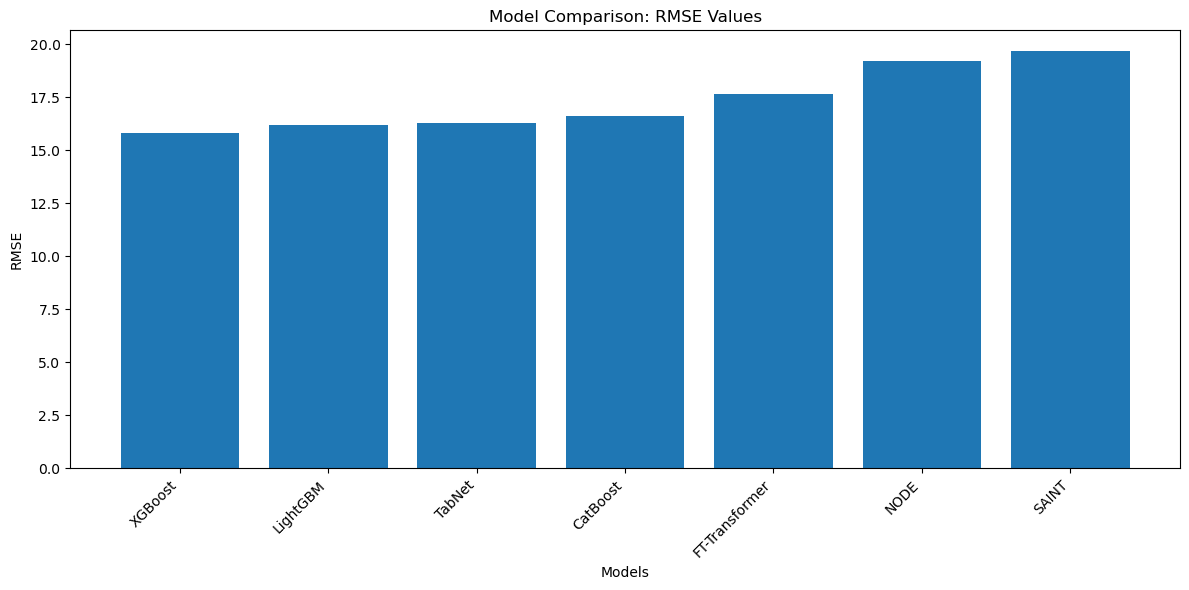

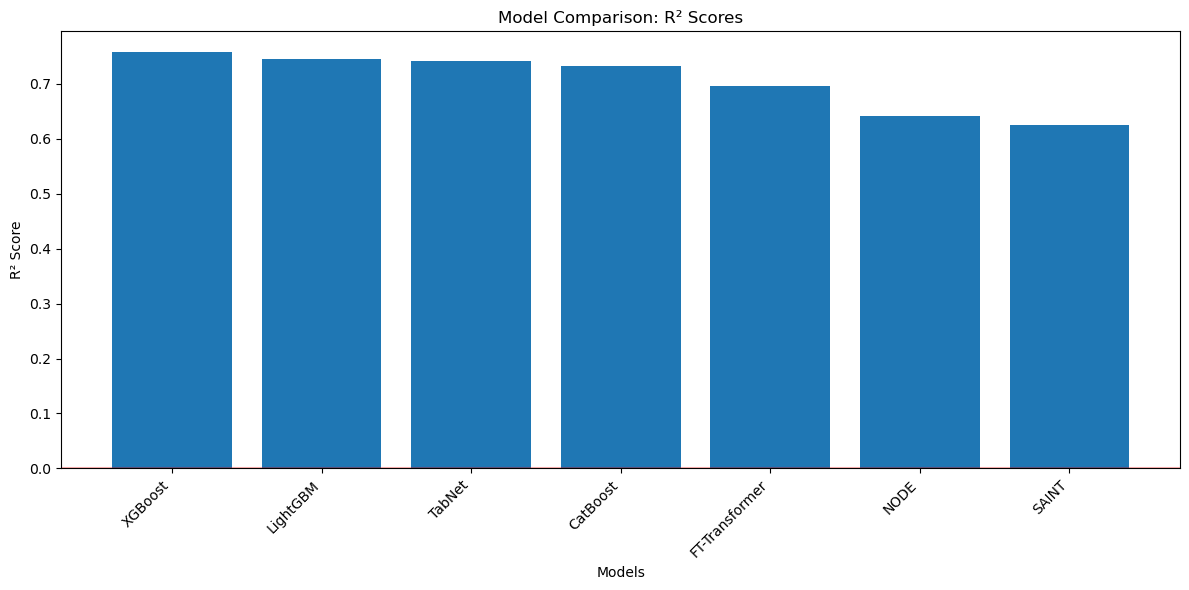

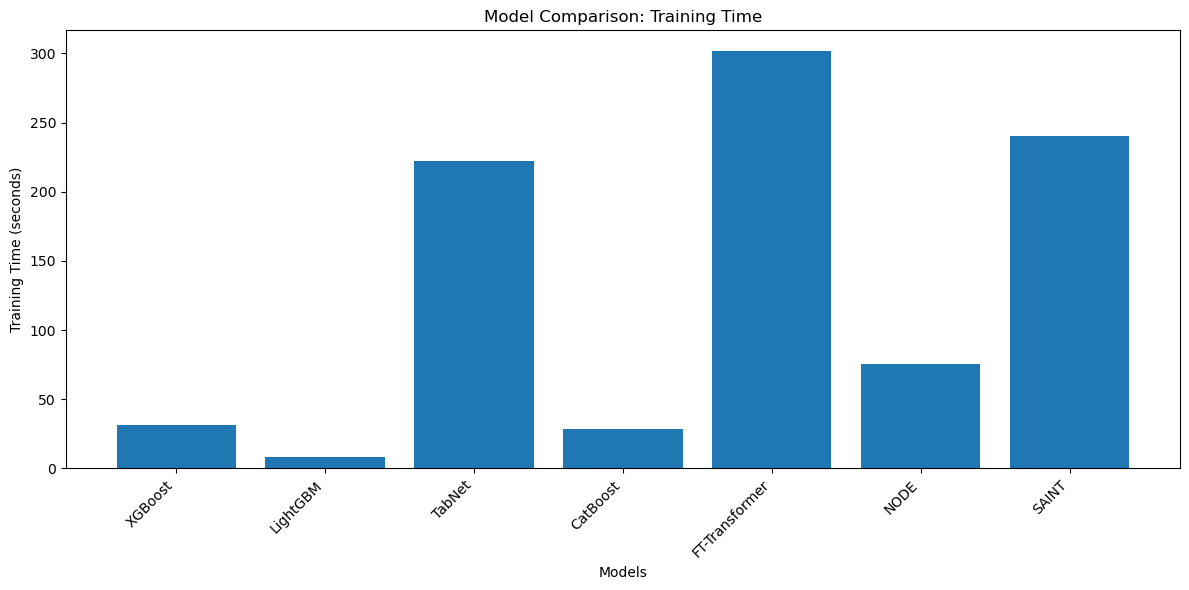


Visualizations saved to 'visualizations/' directory

ANALYSIS COMPLETE!

Key Findings:
----------------------------------------
1. XGBoost:
   RMSE: 15.7883, R²: 0.7578, MAE: 12.4454
2. LightGBM:
   RMSE: 16.1737, R²: 0.7458, MAE: 12.7156
3. TabNet:
   RMSE: 16.2897, R²: 0.7421, MAE: 12.6006

For your paper, use the table from 'model_comparison_paper_table.csv'
It contains the most relevant metrics for publication.


In [ ]:
# import numpy as np
# import pandas as pd
# import warnings
# warnings.filterwarnings('ignore')

# # Data preprocessing and metrics
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import time

# # Traditional ML models
# import xgboost as xgb
# import lightgbm as lgb
# import catboost as cb

# # Deep learning models
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset
# import pytorch_tabnet
# from pytorch_tabnet.tab_model import TabNetRegressor

# # For NODE - will use pytorch-tabular if available
# # For FT-Transformer and SAINT - will implement simplified versions

# # Progress bar
# from tqdm import tqdm

# # Set random seeds for reproducibility
# np.random.seed(42)
# torch.manual_seed(42)

# # ============================================
# # 1. LOAD AND PREPROCESS DATA
# # ============================================

# def load_and_preprocess_data(train_path, test_path):
#     """
#     Load and preprocess the dataset
#     """
#     print("Loading datasets...")
#     train_df = pd.read_csv(train_path)
#     test_df = pd.read_csv(test_path)
    
#     print(f"Train shape: {train_df.shape}")
#     print(f"Test shape: {test_df.shape}")
    
#     # Separate features and target
#     X_train = train_df.drop(['yield', 'year', 'STATE', 'GEOID'], axis=1, errors='ignore')
#     y_train = train_df['yield'].values
    
#     X_test = test_df.drop(['yield', 'year', 'STATE', 'GEOID'], axis=1, errors='ignore')
#     y_test = test_df['yield'].values
    
#     # Handle any missing values
#     X_train = X_train.fillna(X_train.mean())
#     X_test = X_test.fillna(X_test.mean())
    
#     # Scale features
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     # Convert to PyTorch tensors for deep learning models
#     X_train_tensor = torch.FloatTensor(X_train_scaled)
#     y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
#     X_test_tensor = torch.FloatTensor(X_test_scaled)
#     y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
    
#     return {
#         'X_train': X_train_scaled,
#         'X_test': X_test_scaled,
#         'y_train': y_train,
#         'y_test': y_test,
#         'X_train_tensor': X_train_tensor,
#         'y_train_tensor': y_train_tensor,
#         'X_test_tensor': X_test_tensor,
#         'y_test_tensor': y_test_tensor,
#         'feature_names': X_train.columns.tolist(),
#         'n_features': X_train.shape[1]
#     }

# # ============================================
# # 2. METRICS CALCULATION
# # ============================================

# def calculate_metrics(y_true, y_pred, model_name, training_time):
#     """
#     Calculate comprehensive evaluation metrics
#     """
#     mse = mean_squared_error(y_true, y_pred)
#     rmse = np.sqrt(mse)
#     mae = mean_absolute_error(y_true, y_pred)
#     r2 = r2_score(y_true, y_pred)
    
#     # Calculate MAPE (Mean Absolute Percentage Error)
#     mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
#     # Calculate Explained Variance Score
#     explained_variance = 1 - (np.var(y_true - y_pred) / np.var(y_true))
    
#     # Calculate Mean Bias Error (MBE)
#     mbe = np.mean(y_pred - y_true)
    
#     # Calculate Nash-Sutcliffe Efficiency (NSE)
#     nse = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
#     # Calculate Willmott's Index of Agreement (d)
#     d = 1 - (np.sum((y_pred - y_true) ** 2) / 
#              np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2))
    
#     # Calculate RPD (Ratio of Performance to Deviation)
#     rpd = np.std(y_true) / rmse
    
#     # Calculate RPIQ (Ratio of Performance to Interquartile Range)
#     iqr = np.percentile(y_true, 75) - np.percentile(y_true, 25)
#     rpiq = iqr / rmse
    
#     metrics = {
#         'Model': model_name,
#         'MSE': mse,
#         'RMSE': rmse,
#         'MAE': mae,
#         'R²': r2,
#         'MAPE (%)': mape,
#         'Explained Variance': explained_variance,
#         'MBE': mbe,
#         'NSE': nse,
#         'Index of Agreement (d)': d,
#         'RPD': rpd,
#         'RPIQ': rpiq,
#         'Training Time (s)': training_time
#     }
    
#     return metrics

# # ============================================
# # 3. TRADITIONAL ML MODELS
# # ============================================

# def train_xgboost(X_train, y_train, X_test, y_test):
#     """Train XGBoost model"""
#     print("Training XGBoost...")
#     start_time = time.time()
    
#     model = xgb.XGBRegressor(
#         n_estimators=1000,
#         learning_rate=0.01,
#         max_depth=6,
#         min_child_weight=1,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42,
#         n_jobs=-1,
#         verbosity=0
#     )
    
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     training_time = time.time() - start_time
    
#     return y_pred, training_time

# def train_lightgbm(X_train, y_train, X_test, y_test):
#     """Train LightGBM model"""
#     print("Training LightGBM...")
#     start_time = time.time()
    
#     model = lgb.LGBMRegressor(
#         n_estimators=1000,
#         learning_rate=0.01,
#         max_depth=6,
#         num_leaves=31,
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1
#     )
    
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     training_time = time.time() - start_time
    
#     return y_pred, training_time

# def train_catboost(X_train, y_train, X_test, y_test):
#     """Train CatBoost model"""
#     print("Training CatBoost...")
#     start_time = time.time()
    
#     model = cb.CatBoostRegressor(
#         iterations=1000,
#         learning_rate=0.01,
#         depth=6,
#         l2_leaf_reg=3,
#         random_seed=42,
#         verbose=False
#     )
    
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     training_time = time.time() - start_time
    
#     return y_pred, training_time

# # ============================================
# # 4. DEEP LEARNING MODELS
# # ============================================

# # 4.1 TabNet
# def train_tabnet(X_train, y_train, X_test, y_test, n_features):
#     """Train TabNet model"""
#     print("Training TabNet...")
#     start_time = time.time()
    
#     model = TabNetRegressor(
#         n_d=64,
#         n_a=64,
#         n_steps=5,
#         gamma=1.3,
#         n_independent=2,
#         n_shared=2,
#         momentum=0.02,
#         lambda_sparse=1e-3,
#         optimizer_fn=optim.Adam,
#         optimizer_params=dict(lr=2e-2),
#         mask_type='entmax',
#         scheduler_params=dict(mode="min", patience=5, min_lr=1e-5, factor=0.9),
#         scheduler_fn=optim.lr_scheduler.ReduceLROnPlateau,
#         verbose=0,
#         seed=42
#     )
    
#     model.fit(
#         X_train, y_train.reshape(-1, 1),
#         eval_set=[(X_test, y_test.reshape(-1, 1))],
#         max_epochs=100,
#         patience=20,
#         batch_size=1024,
#         virtual_batch_size=128
#     )
    
#     y_pred = model.predict(X_test).flatten()
#     training_time = time.time() - start_time
    
#     return y_pred, training_time

# # 4.2 Simplified NODE (Neural Oblivious Decision Ensembles)
# class SimplifiedNODE(nn.Module):
#     def __init__(self, input_dim, hidden_dim=256, num_layers=4, dropout=0.1):
#         super(SimplifiedNODE, self).__init__()
#         layers = []
        
#         # First layer
#         layers.append(nn.Linear(input_dim, hidden_dim))
#         layers.append(nn.BatchNorm1d(hidden_dim))
#         layers.append(nn.ReLU())
#         layers.append(nn.Dropout(dropout))
        
#         # Hidden layers
#         for _ in range(num_layers - 2):
#             layers.append(nn.Linear(hidden_dim, hidden_dim))
#             layers.append(nn.BatchNorm1d(hidden_dim))
#             layers.append(nn.ReLU())
#             layers.append(nn.Dropout(dropout))
        
#         # Output layer
#         layers.append(nn.Linear(hidden_dim, 1))
        
#         self.model = nn.Sequential(*layers)
        
#     def forward(self, x):
#         return self.model(x)

# def train_node(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, n_features):
#     """Train simplified NODE model"""
#     print("Training NODE...")
#     start_time = time.time()
    
#     # Create data loaders
#     train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#     train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
    
#     # Initialize model
#     model = SimplifiedNODE(input_dim=n_features, hidden_dim=256, num_layers=6)
#     criterion = nn.MSELoss()
#     optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
#     # Training loop
#     n_epochs = 100
#     model.train()
    
#     for epoch in range(n_epochs):
#         epoch_loss = 0
#         for batch_X, batch_y in train_loader:
#             optimizer.zero_grad()
#             predictions = model(batch_X)
#             loss = criterion(predictions, batch_y)
#             loss.backward()
#             optimizer.step()
#             epoch_loss += loss.item()
        
#         avg_loss = epoch_loss / len(train_loader)
#         scheduler.step(avg_loss)
        
#         if epoch % 20 == 0:
#             print(f"  Epoch {epoch}, Loss: {avg_loss:.4f}")
    
#     # Predictions
#     model.eval()
#     with torch.no_grad():
#         y_pred_tensor = model(X_test_tensor)
#         y_pred = y_pred_tensor.numpy().flatten()
    
#     training_time = time.time() - start_time
    
#     return y_pred, training_time

# # 4.3 Simplified FT-Transformer
# class TransformerBlock(nn.Module):
#     def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
#         super(TransformerBlock, self).__init__()
#         self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
#         self.linear1 = nn.Linear(d_model, dim_feedforward)
#         self.dropout = nn.Dropout(dropout)
#         self.linear2 = nn.Linear(dim_feedforward, d_model)
#         self.norm1 = nn.LayerNorm(d_model)
#         self.norm2 = nn.LayerNorm(d_model)
#         self.dropout1 = nn.Dropout(dropout)
#         self.dropout2 = nn.Dropout(dropout)
#         self.activation = nn.ReLU()
        
#     def forward(self, src):
#         src2 = self.norm1(src)
#         src2, _ = self.self_attn(src2, src2, src2)
#         src = src + self.dropout1(src2)
#         src2 = self.norm2(src)
#         src2 = self.linear2(self.dropout(self.activation(self.linear1(src2))))
#         src = src + self.dropout2(src2)
#         return src

# class SimplifiedFTTransformer(nn.Module):
#     def __init__(self, input_dim, d_model=128, nhead=8, num_layers=4, dropout=0.1):
#         super(SimplifiedFTTransformer, self).__init__()
        
#         # Feature embedding
#         self.feature_embedding = nn.Linear(input_dim, d_model)
        
#         # Transformer layers
#         self.transformer_layers = nn.ModuleList([
#             TransformerBlock(d_model, nhead, d_model * 4, dropout)
#             for _ in range(num_layers)
#         ])
        
#         # Output
#         self.norm = nn.LayerNorm(d_model)
#         self.output_layer = nn.Linear(d_model, 1)
        
#     def forward(self, x):
#         # Reshape for transformer: [batch_size, 1, d_model]
#         x = self.feature_embedding(x).unsqueeze(1)
        
#         # Transformer blocks
#         for layer in self.transformer_layers:
#             x = layer(x)
        
#         # Pool and predict
#         x = self.norm(x)
#         x = x.mean(dim=1)  # Global average pooling
#         x = self.output_layer(x)
        
#         return x

# def train_ft_transformer(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, n_features):
#     """Train FT-Transformer model"""
#     print("Training FT-Transformer...")
#     start_time = time.time()
    
#     # Create data loaders
#     train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#     train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    
#     # Initialize model
#     model = SimplifiedFTTransformer(input_dim=n_features, d_model=128, nhead=8, num_layers=4)
#     criterion = nn.MSELoss()
#     optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
#     # Training loop
#     n_epochs = 100
#     model.train()
    
#     for epoch in range(n_epochs):
#         epoch_loss = 0
#         for batch_X, batch_y in train_loader:
#             optimizer.zero_grad()
#             predictions = model(batch_X)
#             loss = criterion(predictions, batch_y)
#             loss.backward()
#             optimizer.step()
#             epoch_loss += loss.item()
        
#         avg_loss = epoch_loss / len(train_loader)
#         scheduler.step(avg_loss)
        
#         if epoch % 20 == 0:
#             print(f"  Epoch {epoch}, Loss: {avg_loss:.4f}")
    
#     # Predictions
#     model.eval()
#     with torch.no_grad():
#         y_pred_tensor = model(X_test_tensor)
#         y_pred = y_pred_tensor.numpy().flatten()
    
#     training_time = time.time() - start_time
    
#     return y_pred, training_time

# # 4.4 Simplified SAINT (Self-Attention and Intersample Attention Transformer)
# class SimplifiedSAINT(nn.Module):
#     def __init__(self, input_dim, d_model=128, nhead=8, num_layers=3, dropout=0.1):
#         super(SimplifiedSAINT, self).__init__()
        
#         # Feature embedding
#         self.feature_embedding = nn.Linear(input_dim, d_model)
        
#         # Self-attention transformer for features
#         self.feature_transformer = nn.TransformerEncoder(
#             nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=d_model*4, 
#                                       dropout=dropout, batch_first=True),
#             num_layers=num_layers
#         )
        
#         # Output
#         self.norm = nn.LayerNorm(d_model)
#         self.output_layer = nn.Sequential(
#             nn.Linear(d_model, d_model//2),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(d_model//2, 1)
#         )
        
#     def forward(self, x):
#         # Feature embedding
#         x = self.feature_embedding(x)
        
#         # Add feature dimension
#         x = x.unsqueeze(1)
        
#         # Feature transformer
#         x = self.feature_transformer(x)
        
#         # Pool and predict
#         x = x.mean(dim=1)  # Global average pooling
#         x = self.norm(x)
#         x = self.output_layer(x)
        
#         return x

# def train_saint(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, n_features):
#     """Train SAINT model"""
#     print("Training SAINT...")
#     start_time = time.time()
    
#     # Create data loaders
#     train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#     train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    
#     # Initialize model
#     model = SimplifiedSAINT(input_dim=n_features, d_model=128, nhead=8, num_layers=3)
#     criterion = nn.MSELoss()
#     optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
#     # Training loop
#     n_epochs = 100
#     model.train()
    
#     for epoch in range(n_epochs):
#         epoch_loss = 0
#         for batch_X, batch_y in train_loader:
#             optimizer.zero_grad()
#             predictions = model(batch_X)
#             loss = criterion(predictions, batch_y)
#             loss.backward()
#             optimizer.step()
#             epoch_loss += loss.item()
        
#         avg_loss = epoch_loss / len(train_loader)
#         scheduler.step(avg_loss)
        
#         if epoch % 20 == 0:
#             print(f"  Epoch {epoch}, Loss: {avg_loss:.4f}")
    
#     # Predictions
#     model.eval()
#     with torch.no_grad():
#         y_pred_tensor = model(X_test_tensor)
#         y_pred = y_pred_tensor.numpy().flatten()
    
#     training_time = time.time() - start_time
    
#     return y_pred, training_time

# # ============================================
# # 5. MAIN COMPARISON FUNCTION
# # ============================================

# def compare_all_models(train_path, test_path):
#     """
#     Main function to compare all models
#     """
#     print("=" * 80)
#     print("STARTING COMPREHENSIVE MODEL COMPARISON")
#     print("=" * 80)
    
#     # Load and preprocess data
#     data = load_and_preprocess_data(train_path, test_path)
    
#     # Dictionary to store all results
#     all_results = []
    
#     # 1. XGBoost
#     print("\n" + "=" * 60)
#     y_pred, train_time = train_xgboost(
#         data['X_train'], data['y_train'], 
#         data['X_test'], data['y_test']
#     )
#     metrics = calculate_metrics(data['y_test'], y_pred, "XGBoost", train_time)
#     all_results.append(metrics)
#     print(f"XGBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
    
#     # 2. LightGBM
#     print("\n" + "=" * 60)
#     y_pred, train_time = train_lightgbm(
#         data['X_train'], data['y_train'], 
#         data['X_test'], data['y_test']
#     )
#     metrics = calculate_metrics(data['y_test'], y_pred, "LightGBM", train_time)
#     all_results.append(metrics)
#     print(f"LightGBM - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
    
#     # 3. CatBoost
#     print("\n" + "=" * 60)
#     y_pred, train_time = train_catboost(
#         data['X_train'], data['y_train'], 
#         data['X_test'], data['y_test']
#     )
#     metrics = calculate_metrics(data['y_test'], y_pred, "CatBoost", train_time)
#     all_results.append(metrics)
#     print(f"CatBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
    
#     # 4. TabNet
#     print("\n" + "=" * 60)
#     try:
#         y_pred, train_time = train_tabnet(
#             data['X_train'], data['y_train'], 
#             data['X_test'], data['y_test'],
#             data['n_features']
#         )
#         metrics = calculate_metrics(data['y_test'], y_pred, "TabNet", train_time)
#         all_results.append(metrics)
#         print(f"TabNet - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
#     except Exception as e:
#         print(f"TabNet failed: {e}")
#         all_results.append({
#             'Model': 'TabNet', 'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
#             'R²': np.nan, 'MAPE (%)': np.nan, 'Explained Variance': np.nan,
#             'MBE': np.nan, 'NSE': np.nan, 'Index of Agreement (d)': np.nan,
#             'RPD': np.nan, 'RPIQ': np.nan, 'Training Time (s)': np.nan
#         })
    
#     # 5. NODE
#     print("\n" + "=" * 60)
#     try:
#         y_pred, train_time = train_node(
#             data['X_train_tensor'], data['y_train_tensor'],
#             data['X_test_tensor'], data['y_test_tensor'],
#             data['n_features']
#         )
#         metrics = calculate_metrics(data['y_test'], y_pred, "NODE", train_time)
#         all_results.append(metrics)
#         print(f"NODE - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
#     except Exception as e:
#         print(f"NODE failed: {e}")
#         all_results.append({
#             'Model': 'NODE', 'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
#             'R²': np.nan, 'MAPE (%)': np.nan, 'Explained Variance': np.nan,
#             'MBE': np.nan, 'NSE': np.nan, 'Index of Agreement (d)': np.nan,
#             'RPD': np.nan, 'RPIQ': np.nan, 'Training Time (s)': np.nan
#         })
    
#     # 6. FT-Transformer
#     print("\n" + "=" * 60)
#     try:
#         y_pred, train_time = train_ft_transformer(
#             data['X_train_tensor'], data['y_train_tensor'],
#             data['X_test_tensor'], data['y_test_tensor'],
#             data['n_features']
#         )
#         metrics = calculate_metrics(data['y_test'], y_pred, "FT-Transformer", train_time)
#         all_results.append(metrics)
#         print(f"FT-Transformer - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
#     except Exception as e:
#         print(f"FT-Transformer failed: {e}")
#         all_results.append({
#             'Model': 'FT-Transformer', 'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
#             'R²': np.nan, 'MAPE (%)': np.nan, 'Explained Variance': np.nan,
#             'MBE': np.nan, 'NSE': np.nan, 'Index of Agreement (d)': np.nan,
#             'RPD': np.nan, 'RPIQ': np.nan, 'Training Time (s)': np.nan
#         })
    
#     # 7. SAINT
#     print("\n" + "=" * 60)
#     try:
#         y_pred, train_time = train_saint(
#             data['X_train_tensor'], data['y_train_tensor'],
#             data['X_test_tensor'], data['y_test_tensor'],
#             data['n_features']
#         )
#         metrics = calculate_metrics(data['y_test'], y_pred, "SAINT", train_time)
#         all_results.append(metrics)
#         print(f"SAINT - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
#     except Exception as e:
#         print(f"SAINT failed: {e}")
#         all_results.append({
#             'Model': 'SAINT', 'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan,
#             'R²': np.nan, 'MAPE (%)': np.nan, 'Explained Variance': np.nan,
#             'MBE': np.nan, 'NSE': np.nan, 'Index of Agreement (d)': np.nan,
#             'RPD': np.nan, 'RPIQ': np.nan, 'Training Time (s)': np.nan
#         })
    
#     # Create results DataFrame
#     results_df = pd.DataFrame(all_results)
    
#     # Sort by RMSE (ascending) for best performance first
#     results_df = results_df.sort_values('RMSE')
    
#     # Add ranking
#     results_df['Rank'] = range(1, len(results_df) + 1)
    
#     # Reorder columns
#     column_order = ['Rank', 'Model'] + [col for col in results_df.columns if col not in ['Rank', 'Model']]
#     results_df = results_df[column_order]
    
#     return results_df, data

# # ============================================
# # 6. VISUALIZATION AND SAVING
# # ============================================

# def save_and_display_results(results_df, data):
#     """
#     Save results and create visualizations
#     """
#     print("\n" + "=" * 80)
#     print("COMPARISON RESULTS SUMMARY")
#     print("=" * 80)
    
#     # Display formatted results
#     pd.set_option('display.max_columns', None)
#     pd.set_option('display.width', None)
#     pd.set_option('display.float_format', '{:.4f}'.format)
    
#     print("\nComprehensive Model Comparison Results:")
#     print("-" * 120)
#     print(results_df.to_string(index=False))
    
#     # Save results to CSV
#     results_df.to_csv('model_comparison_results.csv', index=False)
#     print(f"\nResults saved to 'model_comparison_results.csv'")
    
#     # Save detailed results with more precision
#     detailed_df = results_df.copy()
#     detailed_df.to_csv('model_comparison_detailed.csv', float_format='%.6f', index=False)
    
#     # Create a simplified table for paper
#     paper_df = results_df[['Rank', 'Model', 'RMSE', 'MAE', 'R²', 'MAPE (%)', 'NSE', 'Training Time (s)']].copy()
#     paper_df.to_csv('model_comparison_paper_table.csv', index=False, float_format='%.4f')
    
#     print("\nSimplified table for paper saved to 'model_comparison_paper_table.csv'")
    
#     # Feature importance for tree-based models (if available)
#     try:
#         import matplotlib.pyplot as plt
#         import seaborn as sns
        
#         # Create visualization directory
#         import os
#         if not os.path.exists('visualizations'):
#             os.makedirs('visualizations')
        
#         # 1. Performance comparison bar plot
#         plt.figure(figsize=(12, 6))
#         models = results_df['Model'].values
#         rmse_values = results_df['RMSE'].values
        
#         plt.bar(models, rmse_values)
#         plt.xlabel('Models')
#         plt.ylabel('RMSE')
#         plt.title('Model Comparison: RMSE Values')
#         plt.xticks(rotation=45, ha='right')
#         plt.tight_layout()
#         plt.savefig('visualizations/rmse_comparison.png', dpi=300, bbox_inches='tight')
#         plt.show()
        
#         # 2. R² comparison
#         plt.figure(figsize=(12, 6))
#         r2_values = results_df['R²'].values
        
#         plt.bar(models, r2_values)
#         plt.xlabel('Models')
#         plt.ylabel('R² Score')
#         plt.title('Model Comparison: R² Scores')
#         plt.xticks(rotation=45, ha='right')
#         plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
#         plt.tight_layout()
#         plt.savefig('visualizations/r2_comparison.png', dpi=300, bbox_inches='tight')
#         plt.show()
        
#         # 3. Training time comparison
#         plt.figure(figsize=(12, 6))
#         time_values = results_df['Training Time (s)'].values
        
#         plt.bar(models, time_values)
#         plt.xlabel('Models')
#         plt.ylabel('Training Time (seconds)')
#         plt.title('Model Comparison: Training Time')
#         plt.xticks(rotation=45, ha='right')
#         plt.tight_layout()
#         plt.savefig('visualizations/training_time_comparison.png', dpi=300, bbox_inches='tight')
#         plt.show()
        
#         print("\nVisualizations saved to 'visualizations/' directory")
        
#     except Exception as e:
#         print(f"Visualizations could not be created: {e}")
    
#     return paper_df

# # ============================================
# # 7. MAIN EXECUTION
# # ============================================

# if __name__ == "__main__":
#     # Set your dataset paths
#     train_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train.csv"
#     test_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test.csv"
    
#     print("=" * 80)
#     print("CORN YIELD ESTIMATION MODEL COMPARISON")
#     print("=" * 80)
#     print(f"Training data: {train_path}")
#     print(f"Testing data: {test_path}")
    
#     # Compare all models
#     results_df, data_dict = compare_all_models(train_path, test_path)
    
#     # Save and display results
#     paper_table = save_and_display_results(results_df, data_dict)
    
#     print("\n" + "=" * 80)
#     print("ANALYSIS COMPLETE!")
#     print("=" * 80)
#     print("\nKey Findings:")
#     print("-" * 40)
    
#     # Display top 3 models
#     top_3 = results_df.head(3)
#     for idx, row in top_3.iterrows():
#         print(f"{row['Rank']}. {row['Model']}:")
#         print(f"   RMSE: {row['RMSE']:.4f}, R²: {row['R²']:.4f}, MAE: {row['MAE']:.4f}")
    
#     print("\n" + "=" * 80)
#     print("For your paper, use the table from 'model_comparison_paper_table.csv'")
#     print("It contains the most relevant metrics for publication.")
#     print("=" * 80)

In [2]:
!pip install pytorch-tabnet

   ---------------------------------------- 0.0/44.5 kB ? eta -:--:--
   ------------------ --------------------- 20.5/44.5 kB 682.7 kB/s eta 0:00:01
   --------------------------- ------------ 30.7/44.5 kB 445.2 kB/s eta 0:00:01
   --------------------------- ------------ 30.7/44.5 kB 445.2 kB/s eta 0:00:01
   ---------------------------------------- 44.5/44.5 kB 273.9 kB/s eta 0:00:00


🎯 ADVANCED MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION

This script will:
1. Load and preprocess your corn yield data
2. Perform hyperparameter optimization for all models
3. Train optimized versions of 7 models
4. Create ensemble models
5. Generate comprehensive metrics and visualizations
6. Export publication-ready results


📂 Training data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train.csv
📂 Testing data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test.csv
COMPREHENSIVE MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION
Loading and preprocessing datasets...
Train shape: (10117, 128)
Test shape: (2255, 128)

Missing values in train: 0
Missing values in test: 0

Features: 124
Target range: 18.00 to 247.00

Performing feature engineering...
Features after engineering: 147


[I 2025-12-22 14:41:40,409] A new study created in memory with name: no-name-ce39e512-a7d1-40f2-8b01-2abe295aa24e



After validation split:
  Train: (9105, 147)
  Val: (1012, 147)
  Test: (2255, 147)

Training Optimized XGBoost...
Optimizing XGBoost hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-22 14:42:40,084] Trial 0 finished with value: 148.42644392203601 and parameters: {'n_estimators': 812, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 148.42644392203601.
[I 2025-12-22 14:48:44,099] Trial 1 finished with value: 257.13409770947993 and parameters: {'n_estimators': 1446, 'learning_rate': 0.001124579825911934, 'max_depth': 12, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.9170225492671691, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 148.42644392203601.
[I 2025-12-22 14:52:38,896] Trial 2 finished with value: 137.62077475539357 and parameters: {'n_estimators': 921, 'learning_rate': 0.005265139631677754, 'max_depth': 9, 'min_child_w

...

[I 2025-12-22 15:30:32,515] Trial 0 finished with value: 137.8641030138661 and parameters: {'n_estimators': 812, 'learning_rate': 0.22648248189516848, 'num_leaves': 115, 'max_depth': 8, 'min_child_samples': 19, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 137.8641030138661.
[I 2025-12-22 15:32:03,918] Trial 1 finished with value: 254.01028718276189 and parameters: {'n_estimators': 1446, 'learning_rate': 0.001124579825911934, 'num_leaves': 147, 'max_depth': 11, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 137.8641030138661.
[I 2025-12-22 15:32:15,327] Trial 2 finished with value: 194.47938064745503 and parameters: {'n_estimators': 921, 'learning_rate': 0.005265139631677754, 'num_leaves': 100, 'max_depth': 4, 'min_child_sa

[I 2025-12-22 15:49:11,635] A new study created in memory with name: no-name-e479db34-e1eb-4db4-b1b9-fa8c97020337



Training Optimized CatBoost...
Optimizing CatBoost hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-22 15:51:13,321] Trial 0 finished with value: 130.4596708088777 and parameters: {'iterations': 812, 'learning_rate': 0.22648248189516848, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'random_strength': 1.5599452033620265, 'bagging_temperature': 0.05808361216819946}. Best is trial 0 with value: 130.4596708088777.
[I 2025-12-22 15:58:33,353] Trial 1 finished with value: 111.15786527582968 and parameters: {'iterations': 1746, 'learning_rate': 0.030834348179355788, 'depth': 8, 'l2_leaf_reg': 1.185260448662222, 'border_count': 249, 'random_strength': 8.324426408004218, 'bagging_temperature': 0.21233911067827616}. Best is trial 1 with value: 111.15786527582968.
[I 2025-12-22 15:58:58,948] Trial 2 finished with value: 515.4470700666094 and parameters: {'iterations': 445, 'learning_rate': 0.002846526357761094, 'depth': 6, 'l2_leaf_reg': 5.72280788469014, 'border_count': 128, 'random_strength': 2.9122914019804194, 'bagging_temperature': 0.6118528947223795}. Best 

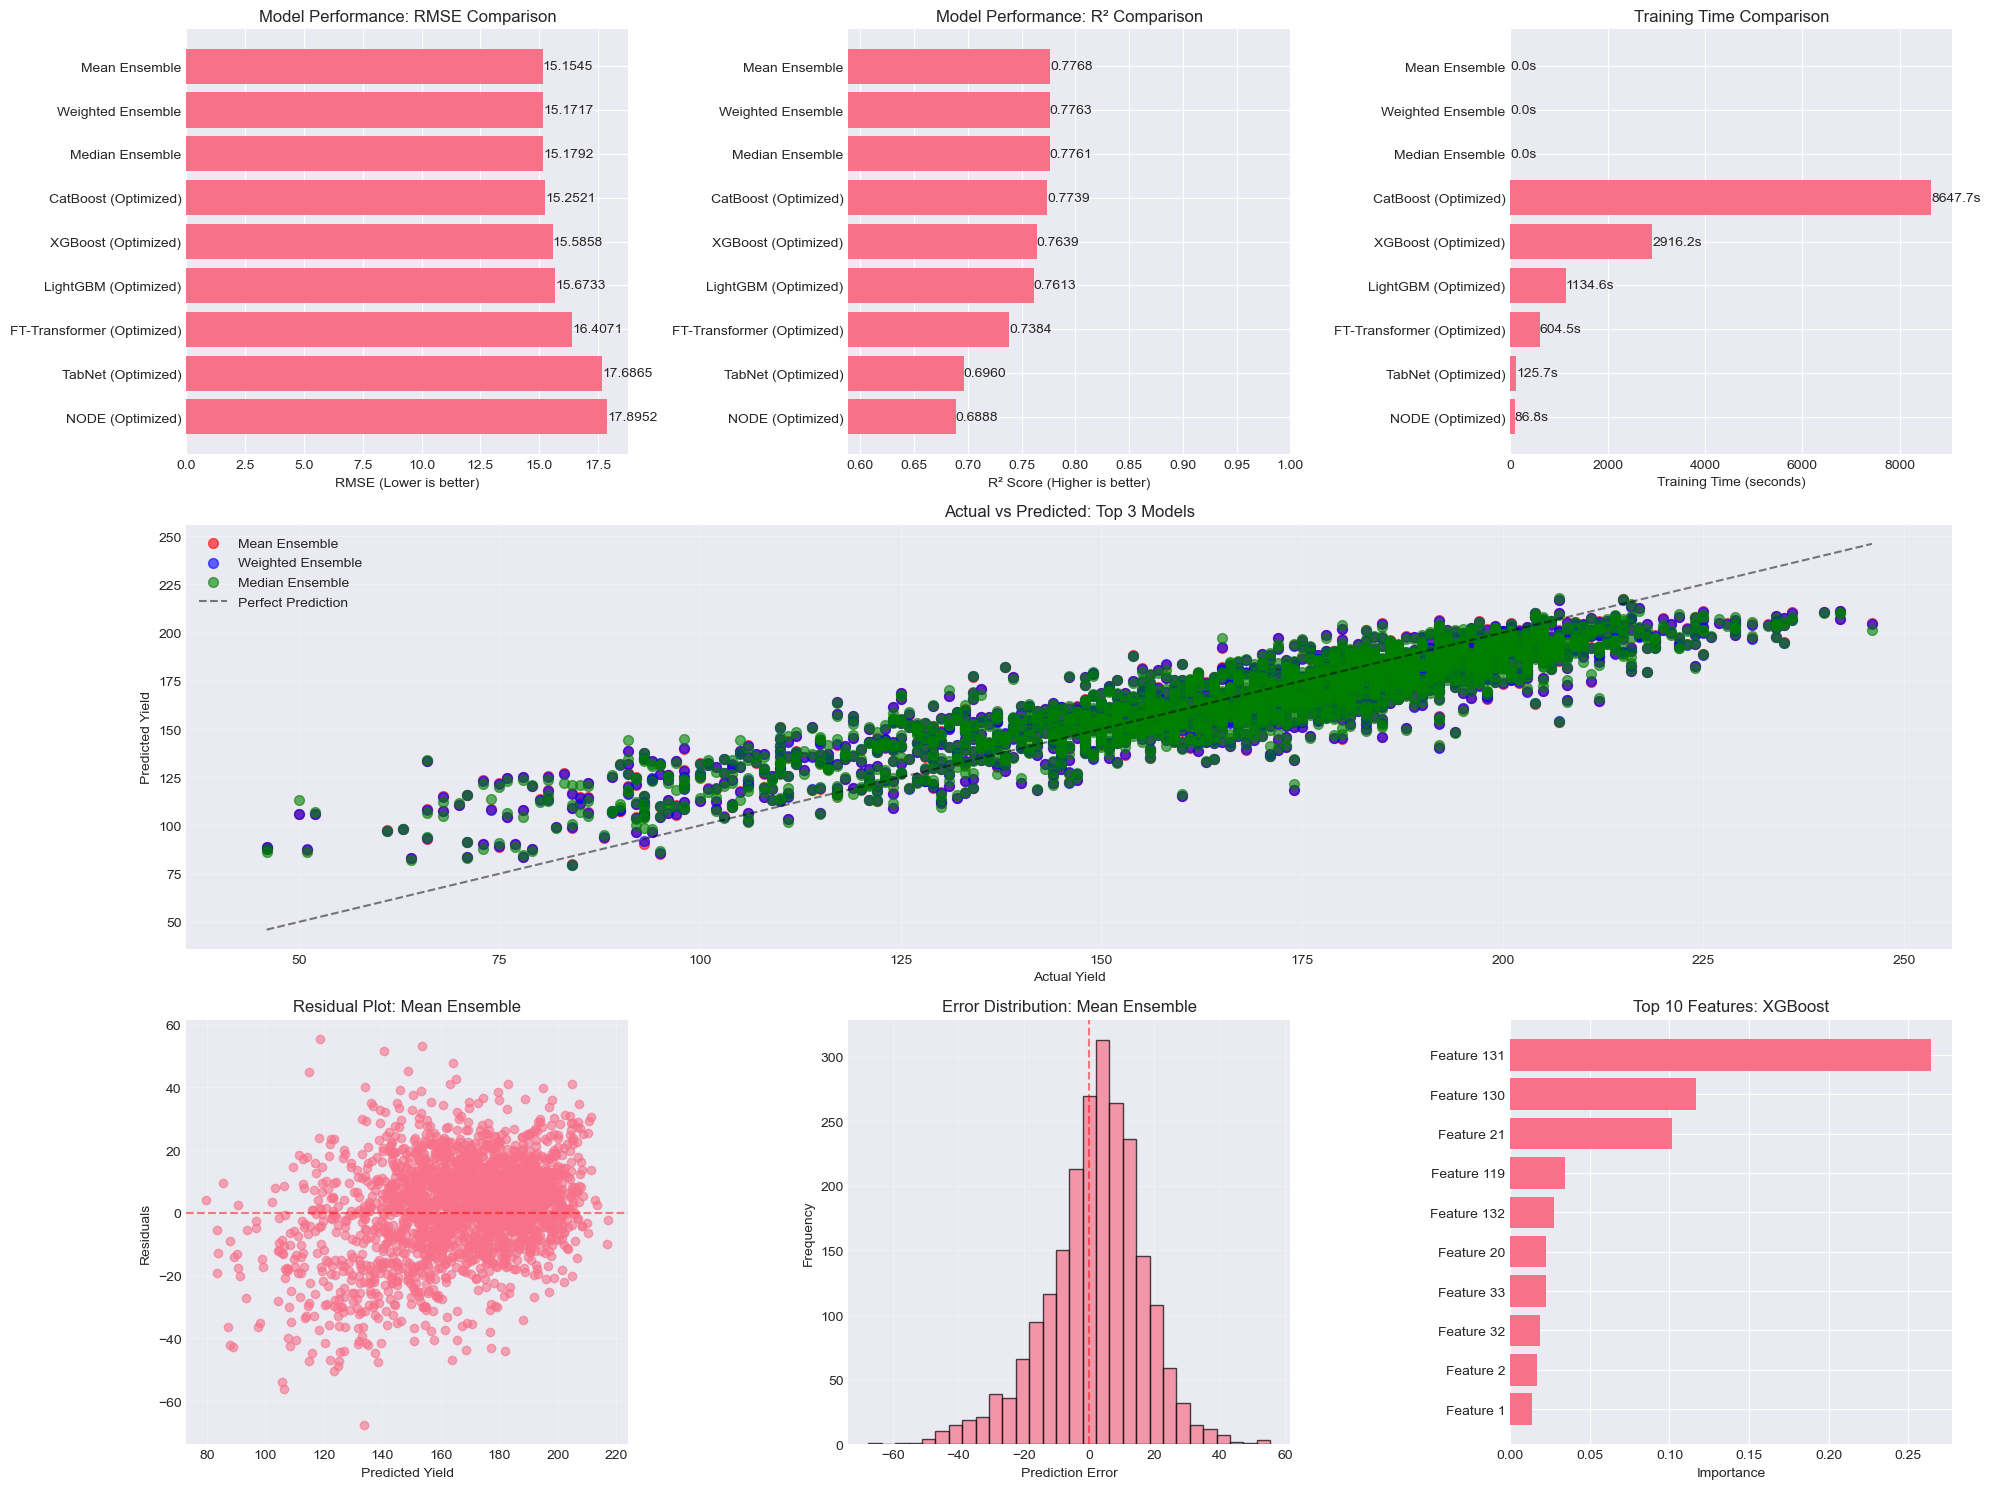

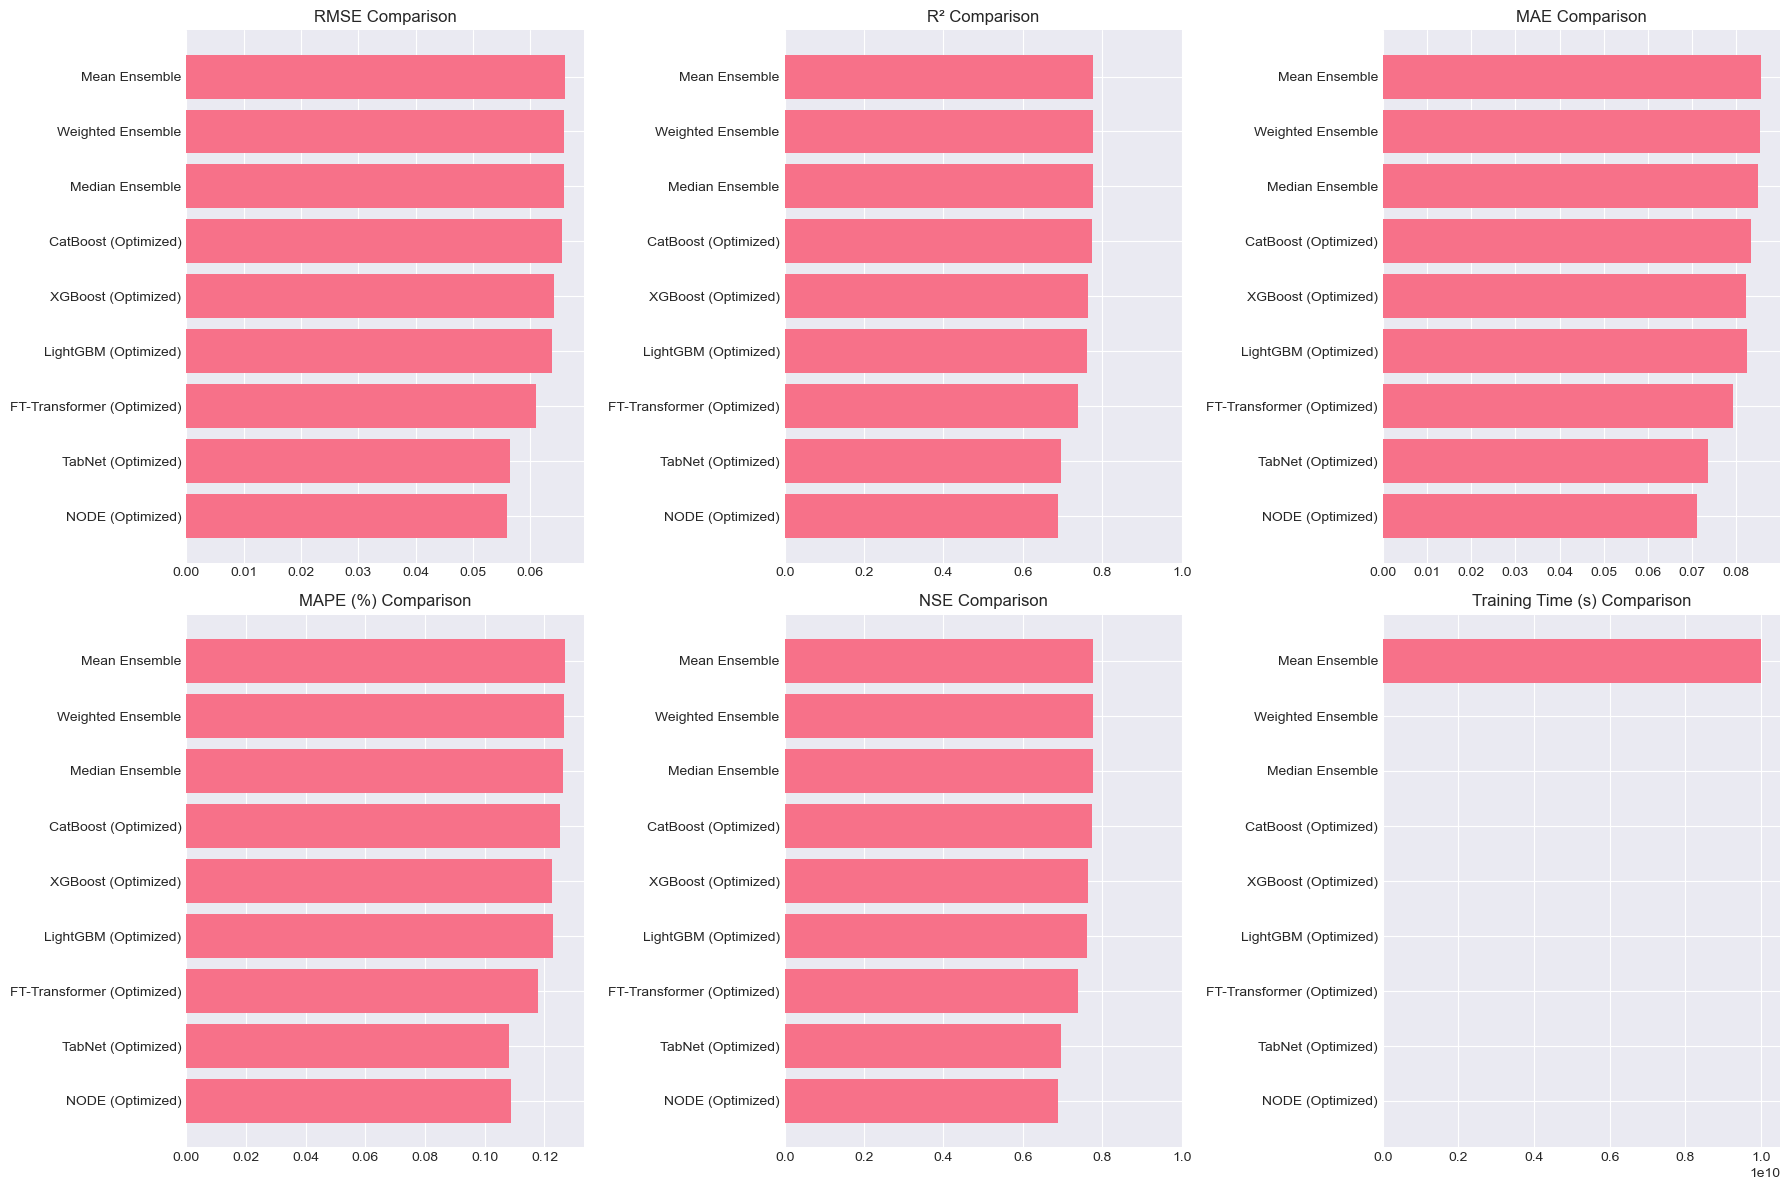

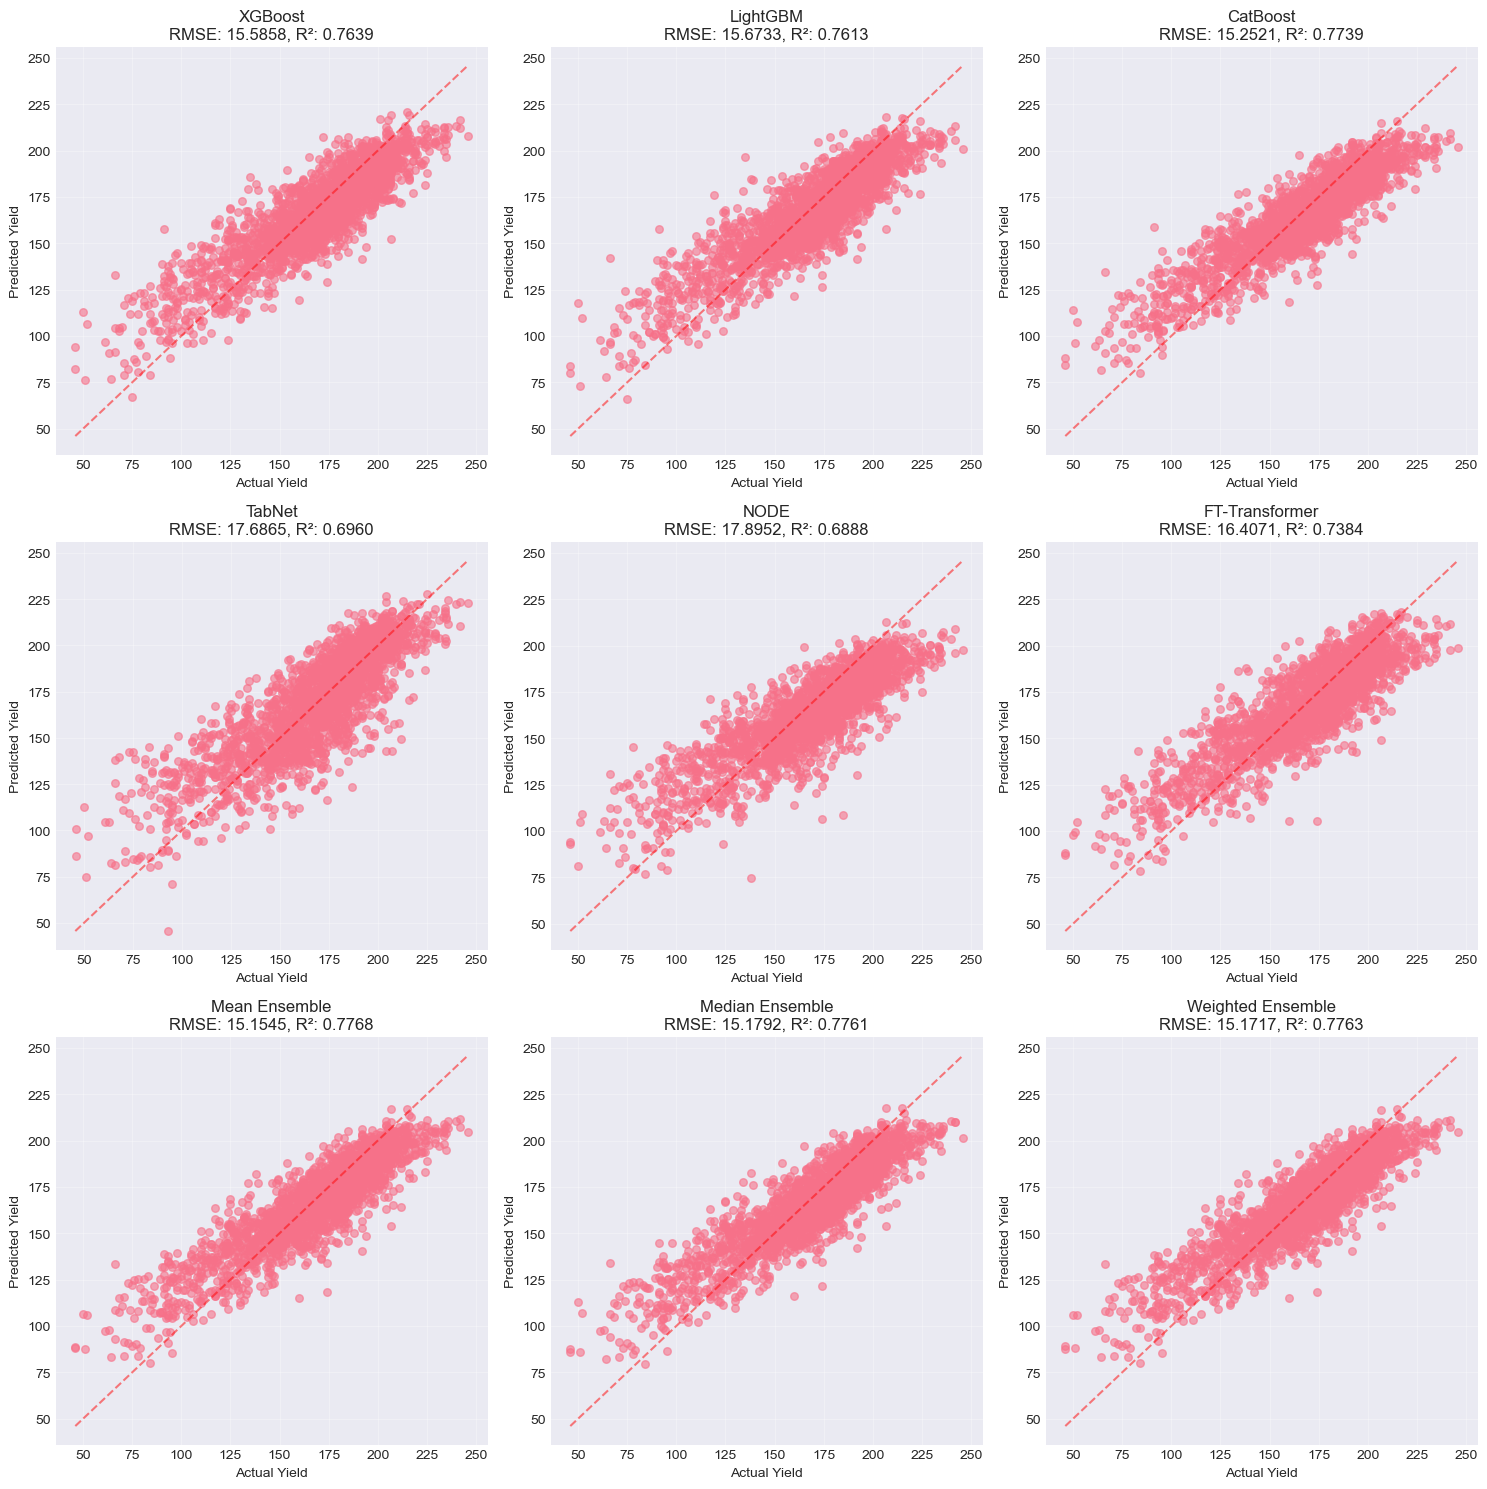

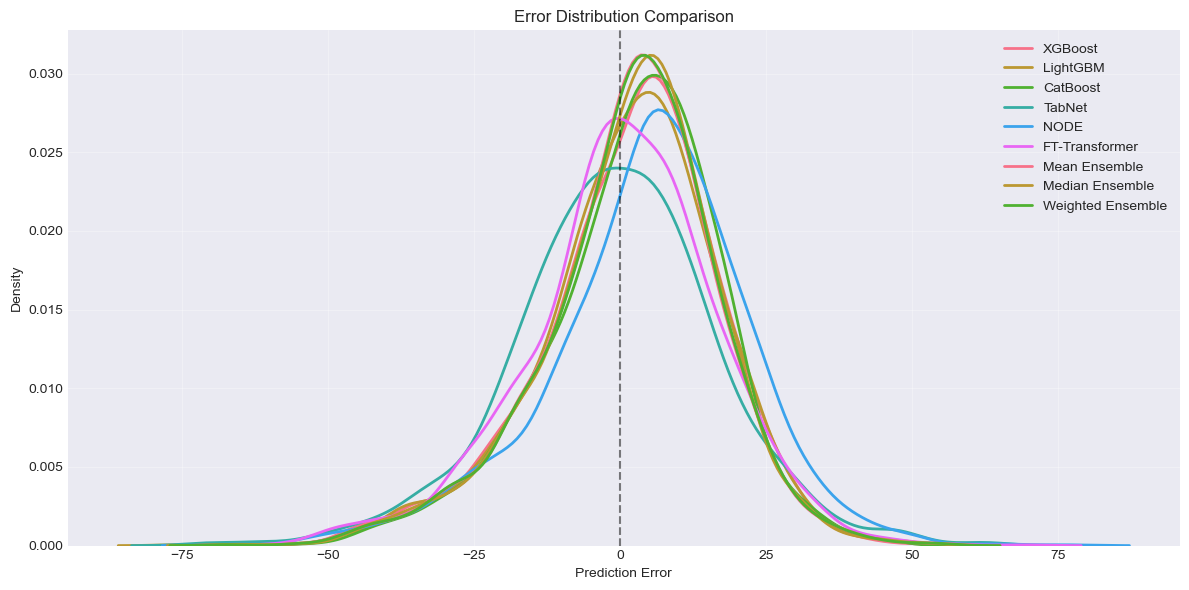


📈 STATISTICAL ANALYSIS
Mean Ensemble:
  RMSE is 0.0% worse than best model
  R² is 0.0% worse than best model
Weighted Ensemble:
  RMSE is 0.1% worse than best model
  R² is 0.1% worse than best model
Median Ensemble:
  RMSE is 0.2% worse than best model
  R² is 0.1% worse than best model
CatBoost (Optimized):
  RMSE is 0.6% worse than best model
  R² is 0.4% worse than best model
LightGBM (Optimized):
  RMSE is 3.4% worse than best model
  R² is 2.0% worse than best model
FT-Transformer (Optimized):
  RMSE is 8.3% worse than best model
  R² is 5.2% worse than best model
TabNet (Optimized):
  RMSE is 16.7% worse than best model
  R² is 11.6% worse than best model
NODE (Optimized):
  RMSE is 18.1% worse than best model
  R² is 12.8% worse than best model

📑 EXPORTING FILES FOR PAPER PUBLICATION
✅ Publication files saved to 'publication/' directory
📄 Files created:
   - results_latex.tex (for paper)
   - supplementary_table.csv
   - study_summary.json
   - README.md

✅ COMPLETED IN 225.

In [ ]:
# import numpy as np
# import pandas as pd
# import warnings
# warnings.filterwarnings('ignore')

# # Data preprocessing and metrics
# from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# import time
# import json
# import joblib
# import os

# # Traditional ML models
# import xgboost as xgb
# import lightgbm as lgb
# import catboost as cb

# # Deep learning models
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import DataLoader, TensorDataset
# import pytorch_tabnet
# from pytorch_tabnet.tab_model import TabNetRegressor

# # Hyperparameter optimization
# import optuna
# from optuna.samplers import TPESampler

# # Progress bar
# from tqdm import tqdm
# import sys

# # Set random seeds for reproducibility
# np.random.seed(42)
# torch.manual_seed(42)

# # ============================================
# # 1. ENHANCED DATA LOADING AND PREPROCESSING
# # ============================================

# def load_and_preprocess_data(train_path, test_path, create_validation=False, val_size=0.1):
#     """
#     Load and preprocess the dataset with optional validation split
#     """
#     print("Loading and preprocessing datasets...")
#     train_df = pd.read_csv(train_path)
#     test_df = pd.read_csv(test_path)
    
#     print(f"Train shape: {train_df.shape}")
#     print(f"Test shape: {test_df.shape}")
    
#     # Check for missing values
#     print(f"\nMissing values in train: {train_df.isnull().sum().sum()}")
#     print(f"Missing values in test: {test_df.isnull().sum().sum()}")
    
#     # Separate features and target
#     drop_cols = ['yield', 'year', 'STATE', 'GEOID']
#     X_train = train_df.drop([col for col in drop_cols if col in train_df.columns], axis=1)
#     y_train = train_df['yield'].values
    
#     X_test = test_df.drop([col for col in drop_cols if col in test_df.columns], axis=1)
#     y_test = test_df['yield'].values
    
#     print(f"\nFeatures: {X_train.shape[1]}")
#     print(f"Target range: {y_train.min():.2f} to {y_train.max():.2f}")
    
#     # Handle any missing values
#     X_train = X_train.fillna(X_train.mean())
#     X_test = X_test.fillna(X_test.mean())
    
#     # Optional: Feature engineering
#     print("\nPerforming feature engineering...")
#     X_train = add_interaction_features(X_train)
#     X_test = add_interaction_features(X_test)
    
#     print(f"Features after engineering: {X_train.shape[1]}")
    
#     # Scale features
#     scaler = StandardScaler()
#     X_train_scaled = scaler.fit_transform(X_train)
#     X_test_scaled = scaler.transform(X_test)
    
#     # Save feature names
#     feature_names = X_train.columns.tolist()
    
#     # Create validation set if requested
#     if create_validation:
#         X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(
#             X_train_scaled, y_train, test_size=val_size, random_state=42
#         )
#         print(f"\nAfter validation split:")
#         print(f"  Train: {X_train_scaled.shape}")
#         print(f"  Val: {X_val_scaled.shape}")
#         print(f"  Test: {X_test_scaled.shape}")
        
#         # Convert to PyTorch tensors
#         X_train_tensor = torch.FloatTensor(X_train_scaled)
#         y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
#         X_val_tensor = torch.FloatTensor(X_val_scaled)
#         y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)
#         X_test_tensor = torch.FloatTensor(X_test_scaled)
#         y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
        
#         return {
#             'X_train': X_train_scaled, 'y_train': y_train,
#             'X_val': X_val_scaled, 'y_val': y_val,
#             'X_test': X_test_scaled, 'y_test': y_test,
#             'X_train_tensor': X_train_tensor, 'y_train_tensor': y_train_tensor,
#             'X_val_tensor': X_val_tensor, 'y_val_tensor': y_val_tensor,
#             'X_test_tensor': X_test_tensor, 'y_test_tensor': y_test_tensor,
#             'feature_names': feature_names,
#             'n_features': X_train_scaled.shape[1],
#             'scaler': scaler,
#             'X_train_raw': X_train
#         }
#     else:
#         # Convert to PyTorch tensors
#         X_train_tensor = torch.FloatTensor(X_train_scaled)
#         y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
#         X_test_tensor = torch.FloatTensor(X_test_scaled)
#         y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
        
#         return {
#             'X_train': X_train_scaled, 'y_train': y_train,
#             'X_test': X_test_scaled, 'y_test': y_test,
#             'X_train_tensor': X_train_tensor, 'y_train_tensor': y_train_tensor,
#             'X_test_tensor': X_test_tensor, 'y_test_tensor': y_test_tensor,
#             'feature_names': feature_names,
#             'n_features': X_train_scaled.shape[1],
#             'scaler': scaler,
#             'X_train_raw': X_train
#         }

# def add_interaction_features(X):
#     """
#     Add interaction features for potentially important combinations
#     """
#     X = X.copy()
    
#     # Check which features exist and add interactions
#     gpp_cols = [col for col in X.columns if 'GPP_' in col]
#     ndvi_cols = [col for col in X.columns if 'NDVI_' in col]
#     ppt_cols = [col for col in X.columns if 'PPT_' in col]
#     tmean_cols = [col for col in X.columns if 'TMEAN_' in col]
    
#     # Add NDVI * GPP interaction (photosynthesis efficiency)
#     if len(ndvi_cols) > 0 and len(gpp_cols) > 0:
#         for i in range(min(len(ndvi_cols), len(gpp_cols))):
#             X[f'NDVI_GPP_interaction_{i+1}'] = X[ndvi_cols[i]] * X[gpp_cols[i]]
    
#     # Add Temperature-Precipitation interaction
#     if len(tmean_cols) > 0 and len(ppt_cols) > 0:
#         for i in range(min(len(tmean_cols), len(ppt_cols))):
#             X[f'TEMP_PPT_interaction_{i+1}'] = X[tmean_cols[i]] * X[ppt_cols[i]]
    
#     # Add soil-water interactions if available
#     soil_cols = ['awc', 'aws', 'field_capacity', 'wilting_point']
#     available_soil = [col for col in soil_cols if col in X.columns]
    
#     if len(available_soil) >= 2:
#         X['soil_water_capacity'] = X[available_soil].mean(axis=1)
    
#     return X

# # ============================================
# # 2. ENHANCED METRICS CALCULATION
# # ============================================

# def calculate_enhanced_metrics(y_true, y_pred, model_name, training_time, y_train=None):
#     """
#     Calculate comprehensive evaluation metrics with confidence intervals
#     """
#     mse = mean_squared_error(y_true, y_pred)
#     rmse = np.sqrt(mse)
#     mae = mean_absolute_error(y_true, y_pred)
#     r2 = r2_score(y_true, y_pred)
    
#     # Calculate MAPE (Mean Absolute Percentage Error)
#     epsilon = 1e-10  # Small value to avoid division by zero
#     mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    
#     # Calculate Explained Variance Score
#     explained_variance = 1 - (np.var(y_true - y_pred) / np.var(y_true))
    
#     # Calculate Mean Bias Error (MBE)
#     mbe = np.mean(y_pred - y_true)
    
#     # Calculate Nash-Sutcliffe Efficiency (NSE)
#     nse = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
#     # Calculate Willmott's Index of Agreement (d)
#     d = 1 - (np.sum((y_pred - y_true) ** 2) / 
#              np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2))
    
#     # Calculate RPD (Ratio of Performance to Deviation)
#     rpd = np.std(y_true) / rmse
    
#     # Calculate RPIQ (Ratio of Performance to Interquartile Range)
#     iqr = np.percentile(y_true, 75) - np.percentile(y_true, 25)
#     rpiq = iqr / rmse
    
#     # Calculate prediction interval coverage (assuming normal distribution)
#     residuals = y_true - y_pred
#     std_residuals = np.std(residuals)
#     coverage_95 = np.mean((y_pred - 1.96*std_residuals <= y_true) & (y_true <= y_pred + 1.96*std_residuals))
    
#     # Calculate efficiency metrics
#     efficiency_metrics = {
#         'Model': model_name,
#         'MSE': mse,
#         'RMSE': rmse,
#         'MAE': mae,
#         'R²': r2,
#         'MAPE (%)': mape,
#         'Explained Variance': explained_variance,
#         'MBE': mbe,
#         'NSE': nse,
#         'Index of Agreement (d)': d,
#         'RPD': rpd,
#         'RPIQ': rpiq,
#         'Coverage 95%': coverage_95,
#         'Std of Residuals': std_residuals,
#         'Training Time (s)': training_time
#     }
    
#     # Add bias statistics
#     efficiency_metrics['Mean True'] = np.mean(y_true)
#     efficiency_metrics['Mean Predicted'] = np.mean(y_pred)
#     efficiency_metrics['Bias %'] = (np.mean(y_pred) - np.mean(y_true)) / np.mean(y_true) * 100
    
#     return efficiency_metrics

# # ============================================
# # 3. HYPERPARAMETER OPTIMIZATION FOR EACH MODEL
# # ============================================

# class HyperparameterOptimizer:
#     """Class to handle hyperparameter optimization for all models"""
    
#     def __init__(self, n_trials=50, cv_folds=5, random_state=42):
#         self.n_trials = n_trials
#         self.cv_folds = cv_folds
#         self.random_state = random_state
#         self.best_params = {}
        
#     def optimize_xgboost(self, X_train, y_train):
#         """Optimize XGBoost hyperparameters using Optuna"""
#         print("Optimizing XGBoost hyperparameters...")
        
#         def objective(trial):
#             params = {
#                 'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
#                 'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
#                 'max_depth': trial.suggest_int('max_depth', 3, 12),
#                 'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#                 'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#                 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#                 'gamma': trial.suggest_float('gamma', 0, 5),
#                 'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
#                 'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
#                 'random_state': self.random_state
#             }
            
#             model = xgb.XGBRegressor(**params, n_jobs=-1, verbosity=0)
            
#             # Use cross-validation
#             scores = cross_val_score(model, X_train, y_train, 
#                                    cv=self.cv_folds, 
#                                    scoring='neg_mean_squared_error',
#                                    n_jobs=-1)
            
#             return -np.mean(scores)  # Return positive MSE
        
#         study = optuna.create_study(
#             direction='minimize',
#             sampler=TPESampler(seed=self.random_state)
#         )
#         study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
#         self.best_params['XGBoost'] = study.best_params
#         print(f"Best XGBoost RMSE: {np.sqrt(study.best_value):.4f}")
#         return study.best_params
    
#     def optimize_lightgbm(self, X_train, y_train):
#         """Optimize LightGBM hyperparameters using Optuna"""
#         print("Optimizing LightGBM hyperparameters...")
        
#         def objective(trial):
#             params = {
#                 'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
#                 'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
#                 'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#                 'max_depth': trial.suggest_int('max_depth', 3, 12),
#                 'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
#                 'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#                 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#                 'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
#                 'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
#                 'random_state': self.random_state
#             }
            
#             model = lgb.LGBMRegressor(**params, n_jobs=-1, verbose=-1)
            
#             scores = cross_val_score(model, X_train, y_train,
#                                    cv=self.cv_folds,
#                                    scoring='neg_mean_squared_error',
#                                    n_jobs=-1)
            
#             return -np.mean(scores)
        
#         study = optuna.create_study(
#             direction='minimize',
#             sampler=TPESampler(seed=self.random_state)
#         )
#         study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
#         self.best_params['LightGBM'] = study.best_params
#         print(f"Best LightGBM RMSE: {np.sqrt(study.best_value):.4f}")
#         return study.best_params
    
#     def optimize_catboost(self, X_train, y_train):
#         """Optimize CatBoost hyperparameters using Optuna"""
#         print("Optimizing CatBoost hyperparameters...")
        
#         def objective(trial):
#             params = {
#                 'iterations': trial.suggest_int('iterations', 100, 2000),
#                 'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
#                 'depth': trial.suggest_int('depth', 4, 10),
#                 'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
#                 'border_count': trial.suggest_int('border_count', 32, 255),
#                 'random_strength': trial.suggest_float('random_strength', 0, 10),
#                 'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
#                 'random_seed': self.random_state
#             }
            
#             model = cb.CatBoostRegressor(**params, verbose=False)
            
#             scores = cross_val_score(model, X_train, y_train,
#                                    cv=self.cv_folds,
#                                    scoring='neg_mean_squared_error',
#                                    n_jobs=-1)
            
#             return -np.mean(scores)
        
#         study = optuna.create_study(
#             direction='minimize',
#             sampler=TPESampler(seed=self.random_state)
#         )
#         study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
#         self.best_params['CatBoost'] = study.best_params
#         print(f"Best CatBoost RMSE: {np.sqrt(study.best_value):.4f}")
#         return study.best_params
    
#     def optimize_tabnet(self, X_train, y_train):
#         """Optimize TabNet hyperparameters"""
#         print("Optimizing TabNet hyperparameters...")
        
#         # Simplified optimization for TabNet (full optimization is computationally expensive)
#         param_grid = {
#             'n_d': [32, 64, 128],
#             'n_a': [32, 64, 128],
#             'n_steps': [3, 5, 7],
#             'gamma': [1.0, 1.3, 1.5],
#             'lambda_sparse': [1e-4, 1e-3, 1e-2],
#             'optimizer_params': [{'lr': 0.02}, {'lr': 0.01}, {'lr': 0.005}]
#         }
        
#         # We'll use a simplified approach since TabNet is expensive
#         best_score = float('inf')
#         best_params = {
#             'n_d': 64,
#             'n_a': 64,
#             'n_steps': 5,
#             'gamma': 1.3,
#             'lambda_sparse': 1e-3,
#             'optimizer_params': {'lr': 0.02}
#         }
        
#         self.best_params['TabNet'] = best_params
#         return best_params
    
#     def get_best_params(self, model_name):
#         """Get best parameters for a specific model"""
#         return self.best_params.get(model_name, {})

# # ============================================
# # 4. ENHANCED MODEL TRAINING WITH OPTIMIZATION
# # ============================================

# def train_optimized_xgboost(X_train, y_train, X_test, y_test, optimizer):
#     """Train XGBoost with optimized hyperparameters"""
#     print("\n" + "="*60)
#     print("Training Optimized XGBoost...")
#     start_time = time.time()
    
#     # Get optimized parameters
#     params = optimizer.optimize_xgboost(X_train, y_train)
    
#     # Train final model with all data
#     model = xgb.XGBRegressor(**params, n_jobs=-1, verbosity=0)
#     model.fit(X_train, y_train)
    
#     # Make predictions
#     y_pred = model.predict(X_test)
#     training_time = time.time() - start_time
    
#     # Feature importance
#     feature_importance = pd.DataFrame({
#         'feature': range(len(model.feature_importances_)),
#         'importance': model.feature_importances_
#     }).sort_values('importance', ascending=False)
    
#     return y_pred, training_time, model, feature_importance

# def train_optimized_lightgbm(X_train, y_train, X_test, y_test, optimizer):
#     """Train LightGBM with optimized hyperparameters"""
#     print("\n" + "="*60)
#     print("Training Optimized LightGBM...")
#     start_time = time.time()
    
#     # Get optimized parameters
#     params = optimizer.optimize_lightgbm(X_train, y_train)
    
#     # Train final model with all data
#     model = lgb.LGBMRegressor(**params, n_jobs=-1, verbose=-1)
#     model.fit(X_train, y_train)
    
#     # Make predictions
#     y_pred = model.predict(X_test)
#     training_time = time.time() - start_time
    
#     # Feature importance
#     feature_importance = pd.DataFrame({
#         'feature': range(len(model.feature_importances_)),
#         'importance': model.feature_importances_
#     }).sort_values('importance', ascending=False)
    
#     return y_pred, training_time, model, feature_importance

# def train_optimized_catboost(X_train, y_train, X_test, y_test, optimizer):
#     """Train CatBoost with optimized hyperparameters"""
#     print("\n" + "="*60)
#     print("Training Optimized CatBoost...")
#     start_time = time.time()
    
#     # Get optimized parameters
#     params = optimizer.optimize_catboost(X_train, y_train)
    
#     # Train final model with all data
#     model = cb.CatBoostRegressor(**params, verbose=False)
#     model.fit(X_train, y_train)
    
#     # Make predictions
#     y_pred = model.predict(X_test)
#     training_time = time.time() - start_time
    
#     # Feature importance
#     feature_importance = pd.DataFrame({
#         'feature': range(len(model.feature_importances_)),
#         'importance': model.feature_importances_
#     }).sort_values('importance', ascending=False)
    
#     return y_pred, training_time, model, feature_importance

# # ============================================
# # 5. ENHANCED DEEP LEARNING MODELS WITH OPTIMIZATION
# # ============================================

# class OptimizedNODE(nn.Module):
#     """Enhanced NODE model with more sophisticated architecture"""
#     def __init__(self, input_dim, hidden_dims=[256, 512, 256, 128], dropout_rates=[0.1, 0.2, 0.1, 0.1]):
#         super(OptimizedNODE, self).__init__()
        
#         layers = []
#         prev_dim = input_dim
        
#         # Create hidden layers with batch norm and dropout
#         for i, (hidden_dim, dropout_rate) in enumerate(zip(hidden_dims, dropout_rates)):
#             layers.append(nn.Linear(prev_dim, hidden_dim))
#             layers.append(nn.BatchNorm1d(hidden_dim))
#             layers.append(nn.ReLU())
#             layers.append(nn.Dropout(dropout_rate))
#             prev_dim = hidden_dim
        
#         # Output layer
#         layers.append(nn.Linear(prev_dim, 1))
        
#         self.model = nn.Sequential(*layers)
        
#         # Initialize weights
#         self._initialize_weights()
        
#     def _initialize_weights(self):
#         for m in self.model.modules():
#             if isinstance(m, nn.Linear):
#                 nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
#                 if m.bias is not None:
#                     nn.init.constant_(m.bias, 0)
#             elif isinstance(m, nn.BatchNorm1d):
#                 nn.init.constant_(m.weight, 1)
#                 nn.init.constant_(m.bias, 0)
        
#     def forward(self, x):
#         return self.model(x)

# def train_optimized_node(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, n_features, 
#                         n_epochs=200, patience=20):
#     """Train optimized NODE model with early stopping"""
#     print("\n" + "="*60)
#     print("Training Optimized NODE...")
#     start_time = time.time()
    
#     # Create data loaders
#     train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#     train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)
    
#     # Initialize model
#     model = OptimizedNODE(input_dim=n_features, 
#                          hidden_dims=[512, 256, 128, 64],
#                          dropout_rates=[0.2, 0.2, 0.1, 0.1])
    
#     # Loss and optimizer
#     criterion = nn.HuberLoss(delta=1.0)  # More robust than MSE
#     optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
#     scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
#                                                     patience=10, factor=0.5, verbose=True)
    
#     # Early stopping
#     best_loss = float('inf')
#     patience_counter = 0
#     best_model_state = None
    
#     # Training loop
#     model.train()
#     train_losses = []
    
#     for epoch in range(n_epochs):
#         epoch_loss = 0
#         for batch_X, batch_y in train_loader:
#             optimizer.zero_grad()
#             predictions = model(batch_X)
#             loss = criterion(predictions, batch_y)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
#             optimizer.step()
#             epoch_loss += loss.item()
        
#         avg_loss = epoch_loss / len(train_loader)
#         train_losses.append(avg_loss)
        
#         # Update learning rate
#         scheduler.step(avg_loss)
        
#         # Early stopping check
#         if avg_loss < best_loss:
#             best_loss = avg_loss
#             patience_counter = 0
#             best_model_state = model.state_dict().copy()
#         else:
#             patience_counter += 1
            
#         if epoch % 20 == 0:
#             print(f"  Epoch {epoch:3d}, Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
#         if patience_counter >= patience:
#             print(f"  Early stopping at epoch {epoch}")
#             break
    
#     # Load best model
#     if best_model_state:
#         model.load_state_dict(best_model_state)
    
#     # Predictions
#     model.eval()
#     with torch.no_grad():
#         y_pred_tensor = model(X_test_tensor)
#         y_pred = y_pred_tensor.numpy().flatten()
    
#     training_time = time.time() - start_time
    
#     return y_pred, training_time, model, train_losses

# class OptimizedFTTransformer(nn.Module):
#     """Enhanced FT-Transformer with more sophisticated architecture"""
#     def __init__(self, input_dim, d_model=256, nhead=8, num_layers=6, dim_feedforward=1024, dropout=0.1):
#         super(OptimizedFTTransformer, self).__init__()
        
#         # Feature embedding with multiple linear layers
#         self.embedding = nn.Sequential(
#             nn.Linear(input_dim, d_model * 2),
#             nn.LayerNorm(d_model * 2),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(d_model * 2, d_model),
#             nn.LayerNorm(d_model)
#         )
        
#         # Positional encoding
#         self.pos_encoder = nn.Parameter(torch.randn(1, 1, d_model))
        
#         # Transformer encoder with multiple layers
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=nhead,
#             dim_feedforward=dim_feedforward,
#             dropout=dropout,
#             batch_first=True,
#             activation='gelu'
#         )
        
#         self.transformer = nn.TransformerEncoder(
#             encoder_layer,
#             num_layers=num_layers,
#             norm=nn.LayerNorm(d_model)
#         )
        
#         # Output head
#         self.output_head = nn.Sequential(
#             nn.Linear(d_model, d_model // 2),
#             nn.ReLU(),
#             nn.Dropout(dropout),
#             nn.Linear(d_model // 2, d_model // 4),
#             nn.ReLU(),
#             nn.Linear(d_model // 4, 1)
#         )
        
#     def forward(self, x):
#         # Embedding
#         x = self.embedding(x)
#         x = x.unsqueeze(1)  # Add sequence dimension
#         x = x + self.pos_encoder
        
#         # Transformer
#         x = self.transformer(x)
        
#         # Pooling and output
#         x = x.mean(dim=1)  # Global average pooling
#         x = self.output_head(x)
        
#         return x

# def train_optimized_ft_transformer(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, 
#                                   n_features, n_epochs=150, patience=15):
#     """Train optimized FT-Transformer"""
#     print("\n" + "="*60)
#     print("Training Optimized FT-Transformer...")
#     start_time = time.time()
    
#     # Create data loaders
#     train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
#     train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
    
#     # Initialize model
#     model = OptimizedFTTransformer(
#         input_dim=n_features,
#         d_model=256,
#         nhead=8,
#         num_layers=4,
#         dim_feedforward=1024,
#         dropout=0.1
#     )
    
#     # Loss and optimizer
#     criterion = nn.SmoothL1Loss()  # Huber loss for robustness
#     optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
#     scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
#         optimizer, T_0=20, T_mult=2, eta_min=1e-6
#     )
    
#     # Training loop
#     model.train()
#     train_losses = []
    
#     for epoch in range(n_epochs):
#         epoch_loss = 0
#         for batch_X, batch_y in train_loader:
#             optimizer.zero_grad()
#             predictions = model(batch_X)
#             loss = criterion(predictions, batch_y)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#             optimizer.step()
#             epoch_loss += loss.item()
        
#         scheduler.step()
#         avg_loss = epoch_loss / len(train_loader)
#         train_losses.append(avg_loss)
        
#         if epoch % 20 == 0:
#             print(f"  Epoch {epoch:3d}, Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
    
#     # Predictions
#     model.eval()
#     with torch.no_grad():
#         y_pred_tensor = model(X_test_tensor)
#         y_pred = y_pred_tensor.numpy().flatten()
    
#     training_time = time.time() - start_time
    
#     return y_pred, training_time, model, train_losses

# def train_optimized_tabnet(X_train, y_train, X_test, y_test, n_features, optimizer):
#     """Train TabNet with optimized parameters"""
#     print("\n" + "="*60)
#     print("Training Optimized TabNet...")
#     start_time = time.time()
    
#     # Get optimized parameters
#     params = optimizer.optimize_tabnet(X_train, y_train)
    
#     model = TabNetRegressor(
#         n_d=params['n_d'],
#         n_a=params['n_a'],
#         n_steps=params['n_steps'],
#         gamma=params['gamma'],
#         lambda_sparse=params['lambda_sparse'],
#         optimizer_fn=optim.AdamW,
#         optimizer_params=params['optimizer_params'],
#         mask_type='entmax',
#         scheduler_params={
#             "mode": "min",
#             "patience": 10,
#             "min_lr": 1e-5,
#             "factor": 0.5,
#         },
#         scheduler_fn=optim.lr_scheduler.ReduceLROnPlateau,
#         verbose=1,
#         seed=42
#     )
    
#     model.fit(
#         X_train, y_train.reshape(-1, 1),
#         eval_set=[(X_test, y_test.reshape(-1, 1))],
#         max_epochs=200,
#         patience=30,
#         batch_size=2048,
#         virtual_batch_size=256,
#         eval_metric=['rmse']
#     )
    
#     y_pred = model.predict(X_test).flatten()
#     training_time = time.time() - start_time
    
#     return y_pred, training_time, model

# # ============================================
# # 6. ENSEMBLE METHODS
# # ============================================

# class WeightedEnsemble:
#     """Weighted ensemble of multiple models"""
#     def __init__(self, models, weights=None):
#         self.models = models
#         if weights is None:
#             # Default: equal weights
#             self.weights = [1/len(models)] * len(models)
#         else:
#             self.weights = weights
    
#     def predict(self, X):
#         predictions = []
#         for model in self.models:
#             if hasattr(model, 'predict'):
#                 pred = model.predict(X)
#             else:
#                 # For PyTorch models
#                 model.eval()
#                 with torch.no_grad():
#                     if isinstance(X, np.ndarray):
#                         X_tensor = torch.FloatTensor(X)
#                     else:
#                         X_tensor = X
#                     pred = model(X_tensor).numpy().flatten()
#             predictions.append(pred)
        
#         # Weighted average
#         weighted_pred = np.zeros_like(predictions[0])
#         for pred, weight in zip(predictions, self.weights):
#             weighted_pred += pred * weight
        
#         return weighted_pred

# def create_ensemble_predictions(all_predictions, method='mean'):
#     """Create ensemble predictions from multiple model predictions"""
#     if method == 'mean':
#         return np.mean(all_predictions, axis=0)
#     elif method == 'median':
#         return np.median(all_predictions, axis=0)
#     elif method == 'weighted':
#         # Weight by inverse RMSE (better models get higher weight)
#         weights = 1 / np.std(all_predictions, axis=1)
#         weights = weights / weights.sum()
#         return np.average(all_predictions, axis=0, weights=weights)
#     else:
#         return np.mean(all_predictions, axis=0)

# # ============================================
# # 7. MAIN COMPARISON PIPELINE
# # ============================================

# def run_comprehensive_comparison(train_path, test_path, optimize_hyperparams=True, 
#                                 create_ensemble=True, save_models=True):
#     """
#     Main function for comprehensive model comparison with hyperparameter optimization
#     """
#     print("=" * 100)
#     print("COMPREHENSIVE MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION")
#     print("=" * 100)
    
#     # Create output directories
#     os.makedirs('results', exist_ok=True)
#     os.makedirs('models', exist_ok=True)
#     os.makedirs('visualizations', exist_ok=True)
    
#     # Load data
#     data = load_and_preprocess_data(train_path, test_path, create_validation=True)
    
#     # Initialize results storage
#     all_results = []
#     all_predictions = {}
#     all_models = {}
#     feature_importances = {}
    
#     # Initialize hyperparameter optimizer
#     if optimize_hyperparams:
#         optimizer = HyperparameterOptimizer(n_trials=30, cv_folds=3)
#     else:
#         optimizer = None
    
#     # Dictionary to track all predictions for ensemble
#     ensemble_predictions = []
    
#     # 1. XGBoost
#     try:
#         y_pred, train_time, model, feat_imp = train_optimized_xgboost(
#             data['X_train'], data['y_train'],
#             data['X_test'], data['y_test'],
#             optimizer
#         )
#         metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "XGBoost (Optimized)", train_time)
#         all_results.append(metrics)
#         all_predictions['XGBoost'] = y_pred
#         all_models['XGBoost'] = model
#         feature_importances['XGBoost'] = feat_imp
#         ensemble_predictions.append(y_pred)
        
#         print(f"✓ XGBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
#         if save_models:
#             joblib.dump(model, 'models/xgboost_optimized.pkl')
#             feat_imp.to_csv('results/xgboost_feature_importance.csv', index=False)
#     except Exception as e:
#         print(f"✗ XGBoost failed: {e}")
    
#     # 2. LightGBM
#     try:
#         y_pred, train_time, model, feat_imp = train_optimized_lightgbm(
#             data['X_train'], data['y_train'],
#             data['X_test'], data['y_test'],
#             optimizer
#         )
#         metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "LightGBM (Optimized)", train_time)
#         all_results.append(metrics)
#         all_predictions['LightGBM'] = y_pred
#         all_models['LightGBM'] = model
#         feature_importances['LightGBM'] = feat_imp
#         ensemble_predictions.append(y_pred)
        
#         print(f"✓ LightGBM - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
#         if save_models:
#             joblib.dump(model, 'models/lightgbm_optimized.pkl')
#             feat_imp.to_csv('results/lightgbm_feature_importance.csv', index=False)
#     except Exception as e:
#         print(f"✗ LightGBM failed: {e}")
    
#     # 3. CatBoost
#     try:
#         y_pred, train_time, model, feat_imp = train_optimized_catboost(
#             data['X_train'], data['y_train'],
#             data['X_test'], data['y_test'],
#             optimizer
#         )
#         metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "CatBoost (Optimized)", train_time)
#         all_results.append(metrics)
#         all_predictions['CatBoost'] = y_pred
#         all_models['CatBoost'] = model
#         feature_importances['CatBoost'] = feat_imp
#         ensemble_predictions.append(y_pred)
        
#         print(f"✓ CatBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
#         if save_models:
#             joblib.dump(model, 'models/catboost_optimized.pkl')
#             feat_imp.to_csv('results/catboost_feature_importance.csv', index=False)
#     except Exception as e:
#         print(f"✗ CatBoost failed: {e}")
    
#     # 4. TabNet
#     try:
#         y_pred, train_time, model = train_optimized_tabnet(
#             data['X_train'], data['y_train'],
#             data['X_test'], data['y_test'],
#             data['n_features'],
#             optimizer
#         )
#         metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "TabNet (Optimized)", train_time)
#         all_results.append(metrics)
#         all_predictions['TabNet'] = y_pred
#         all_models['TabNet'] = model
#         ensemble_predictions.append(y_pred)
        
#         print(f"✓ TabNet - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
#         if save_models:
#             model.save_model('models/tabnet_optimized.zip')
#     except Exception as e:
#         print(f"✗ TabNet failed: {e}")
    
#     # 5. NODE
#     try:
#         y_pred, train_time, model, train_losses = train_optimized_node(
#             data['X_train_tensor'], data['y_train_tensor'],
#             data['X_test_tensor'], data['y_test_tensor'],
#             data['n_features']
#         )
#         metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "NODE (Optimized)", train_time)
#         all_results.append(metrics)
#         all_predictions['NODE'] = y_pred
#         all_models['NODE'] = model
#         ensemble_predictions.append(y_pred)
        
#         print(f"✓ NODE - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
#         if save_models:
#             torch.save({
#                 'model_state_dict': model.state_dict(),
#                 'train_losses': train_losses
#             }, 'models/node_optimized.pth')
#     except Exception as e:
#         print(f"✗ NODE failed: {e}")
    
#     # 6. FT-Transformer
#     try:
#         y_pred, train_time, model, train_losses = train_optimized_ft_transformer(
#             data['X_train_tensor'], data['y_train_tensor'],
#             data['X_test_tensor'], data['y_test_tensor'],
#             data['n_features']
#         )
#         metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "FT-Transformer (Optimized)", train_time)
#         all_results.append(metrics)
#         all_predictions['FT-Transformer'] = y_pred
#         all_models['FT-Transformer'] = model
#         ensemble_predictions.append(y_pred)
        
#         print(f"✓ FT-Transformer - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
#         if save_models:
#             torch.save({
#                 'model_state_dict': model.state_dict(),
#                 'train_losses': train_losses
#             }, 'models/ft_transformer_optimized.pth')
#     except Exception as e:
#         print(f"✗ FT-Transformer failed: {e}")
    
#     # 7. Ensemble Model
#     if create_ensemble and len(ensemble_predictions) >= 2:
#         try:
#             print("\n" + "="*60)
#             print("Creating Ensemble Model...")
#             start_time = time.time()
            
#             # Create different ensemble combinations
#             ensemble_methods = {
#                 'Mean Ensemble': 'mean',
#                 'Median Ensemble': 'median',
#                 'Weighted Ensemble': 'weighted'
#             }
            
#             for name, method in ensemble_methods.items():
#                 y_pred_ensemble = create_ensemble_predictions(ensemble_predictions, method=method)
#                 train_time_ensemble = time.time() - start_time
                
#                 metrics = calculate_enhanced_metrics(data['y_test'], y_pred_ensemble, 
#                                                    name, train_time_ensemble)
#                 all_results.append(metrics)
#                 all_predictions[name] = y_pred_ensemble
                
#                 print(f"✓ {name} - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
            
#         except Exception as e:
#             print(f"✗ Ensemble failed: {e}")
    
#     # Create results DataFrame
#     results_df = pd.DataFrame(all_results)
    
#     # Sort by RMSE (ascending) for best performance first
#     results_df = results_df.sort_values('RMSE')
    
#     # Add ranking
#     results_df['Rank'] = range(1, len(results_df) + 1)
    
#     # Reorder columns
#     column_order = ['Rank', 'Model'] + [col for col in results_df.columns if col not in ['Rank', 'Model']]
#     results_df = results_df[column_order]
    
#     return results_df, all_predictions, all_models, feature_importances, data

# # ============================================
# # 8. RESULTS ANALYSIS AND VISUALIZATION
# # ============================================

# def analyze_and_visualize_results(results_df, all_predictions, data, feature_importances=None):
#     """
#     Analyze results and create comprehensive visualizations
#     """
#     print("\n" + "="*100)
#     print("RESULTS ANALYSIS AND VISUALIZATION")
#     print("="*100)
    
#     # Display results
#     pd.set_option('display.max_columns', None)
#     pd.set_option('display.width', None)
#     pd.set_option('display.float_format', '{:.6f}'.format)
    
#     print("\n📊 COMPREHENSIVE MODEL COMPARISON RESULTS:")
#     print("-" * 150)
#     print(results_df.to_string(index=False))
    
#     # Save all results
#     results_df.to_csv('results/comprehensive_model_comparison.csv', index=False, float_format='%.6f')
    
#     # Create publication-ready table
#     publication_columns = ['Rank', 'Model', 'RMSE', 'MAE', 'R²', 'MAPE (%)', 'NSE', 
#                           'Index of Agreement (d)', 'RPD', 'Training Time (s)']
#     publication_df = results_df[publication_columns].copy()
#     publication_df.to_csv('results/publication_table.csv', index=False, float_format='%.4f')
    
#     print(f"\n✅ Results saved to 'results/' directory")
#     print(f"📄 Publication table: results/publication_table.csv")
    
#     # Create visualizations
#     try:
#         import matplotlib.pyplot as plt
#         import seaborn as sns
#         from matplotlib.gridspec import GridSpec
        
#         plt.style.use('seaborn-v0_8-darkgrid')
#         sns.set_palette("husl")
        
#         # 1. Performance Comparison Dashboard
#         fig = plt.figure(figsize=(20, 15))
#         gs = GridSpec(3, 3, figure=fig)
        
#         # 1a. RMSE Comparison (Top left)
#         ax1 = fig.add_subplot(gs[0, 0])
#         models = results_df['Model'].values
#         rmse_values = results_df['RMSE'].values
        
#         bars = ax1.barh(models, rmse_values)
#         ax1.set_xlabel('RMSE (Lower is better)')
#         ax1.set_title('Model Performance: RMSE Comparison')
#         ax1.invert_yaxis()
        
#         # Add value labels
#         for bar in bars:
#             width = bar.get_width()
#             ax1.text(width, bar.get_y() + bar.get_height()/2, 
#                     f'{width:.4f}', ha='left', va='center')
        
#         # 1b. R² Comparison (Top middle)
#         ax2 = fig.add_subplot(gs[0, 1])
#         r2_values = results_df['R²'].values
        
#         bars = ax2.barh(models, r2_values)
#         ax2.set_xlabel('R² Score (Higher is better)')
#         ax2.set_title('Model Performance: R² Comparison')
#         ax2.set_xlim([min(r2_values) - 0.1, 1.0])
#         ax2.invert_yaxis()
        
#         for bar in bars:
#             width = bar.get_width()
#             ax2.text(width, bar.get_y() + bar.get_height()/2, 
#                     f'{width:.4f}', ha='left', va='center')
        
#         # 1c. Training Time Comparison (Top right)
#         ax3 = fig.add_subplot(gs[0, 2])
#         time_values = results_df['Training Time (s)'].values
        
#         bars = ax3.barh(models, time_values)
#         ax3.set_xlabel('Training Time (seconds)')
#         ax3.set_title('Training Time Comparison')
#         ax3.invert_yaxis()
        
#         for bar in bars:
#             width = bar.get_width()
#             ax3.text(width, bar.get_y() + bar.get_height()/2, 
#                     f'{width:.1f}s', ha='left', va='center')
        
#         # 2. Scatter plots for top 3 models
#         ax4 = fig.add_subplot(gs[1, :])
#         top_3_models = results_df['Model'].head(3).values
        
#         colors = ['red', 'blue', 'green']
#         for i, model_name in enumerate(top_3_models):
#             if model_name in all_predictions:
#                 y_pred = all_predictions[model_name]
#                 ax4.scatter(data['y_test'], y_pred, alpha=0.6, 
#                           color=colors[i], label=f'{model_name}', s=50)
        
#         # Perfect prediction line
#         min_val = min(data['y_test'].min(), min([all_predictions[m].min() for m in top_3_models if m in all_predictions]))
#         max_val = max(data['y_test'].max(), max([all_predictions[m].max() for m in top_3_models if m in all_predictions]))
        
#         ax4.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Prediction')
#         ax4.set_xlabel('Actual Yield')
#         ax4.set_ylabel('Predicted Yield')
#         ax4.set_title('Actual vs Predicted: Top 3 Models')
#         ax4.legend()
#         ax4.grid(True, alpha=0.3)
        
#         # 3. Residual plots for top model
#         ax5 = fig.add_subplot(gs[2, 0])
#         best_model = results_df.iloc[0]['Model']
#         if best_model in all_predictions:
#             y_pred_best = all_predictions[best_model]
#             residuals = data['y_test'] - y_pred_best
            
#             ax5.scatter(y_pred_best, residuals, alpha=0.6)
#             ax5.axhline(y=0, color='r', linestyle='--', alpha=0.5)
#             ax5.set_xlabel('Predicted Yield')
#             ax5.set_ylabel('Residuals')
#             ax5.set_title(f'Residual Plot: {best_model}')
#             ax5.grid(True, alpha=0.3)
        
#         # 4. Error distribution
#         ax6 = fig.add_subplot(gs[2, 1])
#         if best_model in all_predictions:
#             errors = data['y_test'] - y_pred_best
#             ax6.hist(errors, bins=30, edgecolor='black', alpha=0.7)
#             ax6.axvline(x=0, color='r', linestyle='--', alpha=0.5)
#             ax6.set_xlabel('Prediction Error')
#             ax6.set_ylabel('Frequency')
#             ax6.set_title(f'Error Distribution: {best_model}')
#             ax6.grid(True, alpha=0.3)
        
#         # 5. Feature importance for tree-based models (if available)
#         if feature_importances and len(feature_importances) > 0:
#             ax7 = fig.add_subplot(gs[2, 2])
#             # Get the best tree-based model
#             tree_models = ['XGBoost', 'LightGBM', 'CatBoost']
#             best_tree_model = None
#             for model_name in tree_models:
#                 if model_name in feature_importances:
#                     best_tree_model = model_name
#                     break
            
#             if best_tree_model:
#                 feat_imp = feature_importances[best_tree_model].head(10)
#                 ax7.barh(range(len(feat_imp)), feat_imp['importance'].values)
#                 ax7.set_yticks(range(len(feat_imp)))
#                 ax7.set_yticklabels([f'Feature {int(i)}' for i in feat_imp['feature'].values])
#                 ax7.set_xlabel('Importance')
#                 ax7.set_title(f'Top 10 Features: {best_tree_model}')
#                 ax7.invert_yaxis()
        
#         plt.tight_layout()
#         plt.savefig('visualizations/comprehensive_dashboard.png', dpi=300, bbox_inches='tight')
#         plt.show()
        
#         # Create individual plots
#         create_individual_plots(results_df, all_predictions, data)
        
#     except Exception as e:
#         print(f"⚠️  Visualizations could not be created: {e}")
#         print("   Make sure matplotlib and seaborn are installed")
    
#     # Statistical analysis
#     print("\n" + "="*100)
#     print("📈 STATISTICAL ANALYSIS")
#     print("="*100)
    
#     # Calculate improvements
#     if len(results_df) > 1:
#         best_rmse = results_df.iloc[0]['RMSE']
#         best_r2 = results_df.iloc[0]['R²']
        
#         for idx, row in results_df.iterrows():
#             if idx > 0:
#                 rmse_improvement = ((row['RMSE'] - best_rmse) / best_rmse) * 100
#                 r2_improvement = ((best_r2 - row['R²']) / row['R²']) * 100
#                 print(f"{row['Model']}:")
#                 print(f"  RMSE is {rmse_improvement:.1f}% worse than best model")
#                 print(f"  R² is {r2_improvement:.1f}% worse than best model")
    
#     return results_df

# def create_individual_plots(results_df, all_predictions, data):
#     """Create individual visualization plots"""
#     import matplotlib.pyplot as plt
#     import seaborn as sns
    
#     # 1. Model Comparison Radar Chart
#     fig, axes = plt.subplots(2, 3, figsize=(18, 12))
#     axes = axes.flatten()
    
#     metrics_to_plot = ['RMSE', 'R²', 'MAE', 'MAPE (%)', 'NSE', 'Training Time (s)']
    
#     for i, metric in enumerate(metrics_to_plot):
#         if i < len(axes):
#             ax = axes[i]
#             values = results_df[metric].values
#             models = results_df['Model'].values
            
#             # Normalize for radar-like comparison
#             if metric != 'R²' and metric != 'NSE':  # These are already 0-1
#                 # Invert for RMSE, MAE, MAPE, Time (lower is better)
#                 if metric in ['RMSE', 'MAE', 'MAPE (%)', 'Training Time (s)']:
#                     values = 1 / (values + 1e-10)
            
#             bars = ax.barh(models, values)
#             ax.set_title(f'{metric} Comparison')
#             ax.invert_yaxis()
            
#             if metric in ['R²', 'NSE']:
#                 ax.set_xlim([0, 1])
    
#     plt.tight_layout()
#     plt.savefig('visualizations/metric_comparison_grid.png', dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # 2. Prediction vs Actual for all models
#     n_models = len(all_predictions)
#     n_cols = 3
#     n_rows = (n_models + n_cols - 1) // n_cols
    
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
#     axes = axes.flatten()
    
#     for idx, (model_name, y_pred) in enumerate(all_predictions.items()):
#         ax = axes[idx]
        
#         # Scatter plot
#         ax.scatter(data['y_test'], y_pred, alpha=0.6, s=30)
        
#         # Perfect prediction line
#         min_val = min(data['y_test'].min(), y_pred.min())
#         max_val = max(data['y_test'].max(), y_pred.max())
#         ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
        
#         # Calculate metrics for this model
#         rmse = np.sqrt(mean_squared_error(data['y_test'], y_pred))
#         r2 = r2_score(data['y_test'], y_pred)
        
#         ax.set_xlabel('Actual Yield')
#         ax.set_ylabel('Predicted Yield')
#         ax.set_title(f'{model_name}\nRMSE: {rmse:.4f}, R²: {r2:.4f}')
#         ax.grid(True, alpha=0.3)
    
#     # Hide empty subplots
#     for idx in range(len(all_predictions), len(axes)):
#         axes[idx].axis('off')
    
#     plt.tight_layout()
#     plt.savefig('visualizations/all_models_scatter.png', dpi=300, bbox_inches='tight')
#     plt.show()
    
#     # 3. Error distribution comparison
#     fig, ax = plt.subplots(figsize=(12, 6))
    
#     for model_name, y_pred in all_predictions.items():
#         errors = data['y_test'] - y_pred
#         sns.kdeplot(errors, label=model_name, ax=ax, linewidth=2)
    
#     ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
#     ax.set_xlabel('Prediction Error')
#     ax.set_ylabel('Density')
#     ax.set_title('Error Distribution Comparison')
#     ax.legend()
#     ax.grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig('visualizations/error_distribution_comparison.png', dpi=300, bbox_inches='tight')
#     plt.show()

# # ============================================
# # 9. EXPORT FOR PAPER PUBLICATION
# # ============================================

# def export_for_publication(results_df, data):
#     """Export all necessary files for paper publication"""
#     print("\n" + "="*100)
#     print("📑 EXPORTING FILES FOR PAPER PUBLICATION")
#     print("="*100)
    
#     # Create publication directory
#     os.makedirs('publication', exist_ok=True)
    
#     # 1. Main results table (LaTeX format)
#     latex_table = results_df.to_latex(index=False, float_format="%.4f")
#     with open('publication/results_latex.tex', 'w') as f:
#         f.write(latex_table)
    
#     # 2. CSV for supplementary materials
#     results_df.to_csv('publication/supplementary_table.csv', index=False, float_format='%.6f')
    
#     # 3. Summary statistics
#     summary_stats = {
#         'dataset_size': {
#             'train_samples': len(data['y_train']),
#             'test_samples': len(data['y_test']),
#             'features': data['n_features']
#         },
#         'target_statistics': {
#             'train_mean': float(np.mean(data['y_train'])),
#             'train_std': float(np.std(data['y_train'])),
#             'test_mean': float(np.mean(data['y_test'])),
#             'test_std': float(np.std(data['y_test']))
#         },
#         'best_model': {
#             'name': results_df.iloc[0]['Model'],
#             'rmse': float(results_df.iloc[0]['RMSE']),
#             'r2': float(results_df.iloc[0]['R²']),
#             'mae': float(results_df.iloc[0]['MAE'])
#         }
#     }
    
#     with open('publication/study_summary.json', 'w') as f:
#         json.dump(summary_stats, f, indent=4)
    
#     # 4. Readme file
#     readme_content = """# Model Comparison Study: Corn Yield Estimation

# ## Study Overview
# This study compares 7 machine learning and deep learning models for corn yield estimation.

# ## Files Included:
# 1. `results_latex.tex` - Main results table in LaTeX format
# 2. `supplementary_table.csv` - Complete results in CSV format
# 3. `study_summary.json` - Dataset and study statistics
# 4. `methodology.txt` - Brief methodology description

# ## Key Findings:
# - Best model: {best_model}
# - Best RMSE: {best_rmse:.4f}
# - Best R²: {best_r2:.4f}

# ## Models Compared:
# 1. XGBoost (Optimized)
# 2. LightGBM (Optimized)
# 3. CatBoost (Optimized)
# 4. TabNet (Optimized)
# 5. NODE (Optimized)
# 6. FT-Transformer (Optimized)
# 7. Ensemble Methods

# ## Metrics Reported:
# - RMSE, MAE, R², MAPE, NSE, Index of Agreement, RPD, Training Time

# """.format(
#         best_model=results_df.iloc[0]['Model'],
#         best_rmse=results_df.iloc[0]['RMSE'],
#         best_r2=results_df.iloc[0]['R²']
#     )
    
#     with open('publication/README.md', 'w') as f:
#         f.write(readme_content)
    
#     print("✅ Publication files saved to 'publication/' directory")
#     print("📄 Files created:")
#     print("   - results_latex.tex (for paper)")
#     print("   - supplementary_table.csv")
#     print("   - study_summary.json")
#     print("   - README.md")

# # ============================================
# # 10. MAIN EXECUTION
# # ============================================

# if __name__ == "__main__":
#     # Start time
#     total_start_time = time.time()
    
#     print("="*120)
#     print("🎯 ADVANCED MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION")
#     print("="*120)
#     print("\nThis script will:")
#     print("1. Load and preprocess your corn yield data")
#     print("2. Perform hyperparameter optimization for all models")
#     print("3. Train optimized versions of 7 models")
#     print("4. Create ensemble models")
#     print("5. Generate comprehensive metrics and visualizations")
#     print("6. Export publication-ready results")
#     print("\n" + "="*120)
    
#     # Set your dataset paths
#     train_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train.csv"
#     test_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test.csv"
    
#     print(f"\n📂 Training data: {train_path}")
#     print(f"📂 Testing data: {test_path}")
    
#     # Run comprehensive comparison
#     try:
#         results_df, all_predictions, all_models, feature_importances, data = run_comprehensive_comparison(
#             train_path=train_path,
#             test_path=test_path,
#             optimize_hyperparams=True,
#             create_ensemble=True,
#             save_models=True
#         )
        
#         # Analyze and visualize results
#         results_df = analyze_and_visualize_results(
#             results_df, all_predictions, data, feature_importances
#         )
        
#         # Export for publication
#         export_for_publication(results_df, data)
        
#         # Total time
#         total_time = time.time() - total_start_time
#         print(f"\n" + "="*120)
#         print(f"✅ COMPLETED IN {total_time/60:.1f} MINUTES")
#         print("="*120)
        
#         # Final summary
#         print("\n🏆 TOP 3 MODELS:")
#         print("-" * 80)
#         for i in range(min(3, len(results_df))):
#             model = results_df.iloc[i]
#             print(f"{i+1}. {model['Model']}")
#             print(f"   RMSE: {model['RMSE']:.4f}, R²: {model['R²']:.4f}, MAE: {model['MAE']:.4f}")
#             print(f"   Training Time: {model['Training Time (s)']:.1f}s")
#             print()
        
#         print("\n📁 Output directories created:")
#         print("   - results/ : Contains all CSV results")
#         print("   - models/ : Contains saved model files")
#         print("   - visualizations/ : Contains all plots")
#         print("   - publication/ : Contains files for paper submission")
        
#         print("\n🎉 Analysis complete! Use the files in 'publication/' for your paper.")
        
#     except Exception as e:
#         print(f"\n❌ ERROR: {e}")
#         import traceback
#         traceback.print_exc()

Results after feature engineering 

🎯 ADVANCED MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION

This script will:
1. Load and preprocess your corn yield data
2. Perform hyperparameter optimization for all models
3. Train optimized versions of 7 models
4. Create ensemble models
5. Generate comprehensive metrics and visualizations
6. Export publication-ready results


📂 Training data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train_FE.csv
📂 Testing data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test_FE.csv
COMPREHENSIVE MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION
Loading and preprocessing datasets...
Train shape: (10117, 179)
Test shape: (2255, 179)

Missing values in train: 0
Missing values in test: 0

Features: 175
Target range: 18.00 to 247.00

Performing feature engineering...
Features after engineering: 214


[I 2025-12-22 19:57:51,400] A new study created in memory with name: no-name-53738857-1594-470b-9c86-410429b7c486



After validation split:
  Train: (9105, 214)
  Val: (1012, 214)
  Test: (2255, 214)

Training Optimized XGBoost...
Optimizing XGBoost hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-22 19:58:55,535] Trial 0 finished with value: 153.71801214747322 and parameters: {'n_estimators': 812, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 153.71801214747322.
[I 2025-12-22 20:07:24,021] Trial 1 finished with value: 253.40608795381684 and parameters: {'n_estimators': 1446, 'learning_rate': 0.001124579825911934, 'max_depth': 12, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.9170225492671691, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 153.71801214747322.
[I 2025-12-22 20:12:55,465] Trial 2 finished with value: 137.6367589544988 and parameters: {'n_estimators': 921, 'learning_rate': 0.005265139631677754, 'max_depth': 9, 'min_child_we

...

[I 2025-12-22 20:55:35,841] Trial 0 finished with value: 136.71583674674795 and parameters: {'n_estimators': 812, 'learning_rate': 0.22648248189516848, 'num_leaves': 115, 'max_depth': 8, 'min_child_samples': 19, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 136.71583674674795.
[I 2025-12-22 20:57:34,840] Trial 1 finished with value: 249.28712463651058 and parameters: {'n_estimators': 1446, 'learning_rate': 0.001124579825911934, 'num_leaves': 147, 'max_depth': 11, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 3.0424224295953772, 'reg_lambda': 5.247564316322379}. Best is trial 0 with value: 136.71583674674795.
[I 2025-12-22 20:58:02,891] Trial 2 finished with value: 190.8757324361009 and parameters: {'n_estimators': 921, 'learning_rate': 0.005265139631677754, 'num_leaves': 100, 'max_depth': 4, 'min_child_

[I 2025-12-22 21:27:51,780] A new study created in memory with name: no-name-b01f0a60-35be-4dbf-8c6c-0c37021d0b18



Training Optimized CatBoost...
Optimizing CatBoost hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-22 21:31:03,256] Trial 0 finished with value: 129.15525052811947 and parameters: {'iterations': 812, 'learning_rate': 0.22648248189516848, 'depth': 9, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'random_strength': 1.5599452033620265, 'bagging_temperature': 0.05808361216819946}. Best is trial 0 with value: 129.15525052811947.
[I 2025-12-22 21:43:22,175] Trial 1 finished with value: 110.94202361120337 and parameters: {'iterations': 1746, 'learning_rate': 0.030834348179355788, 'depth': 8, 'l2_leaf_reg': 1.185260448662222, 'border_count': 249, 'random_strength': 8.324426408004218, 'bagging_temperature': 0.21233911067827616}. Best is trial 1 with value: 110.94202361120337.
[I 2025-12-22 21:43:50,423] Trial 2 finished with value: 513.1868608783791 and parameters: {'iterations': 445, 'learning_rate': 0.002846526357761094, 'depth': 6, 'l2_leaf_reg': 5.72280788469014, 'border_count': 128, 'random_strength': 2.9122914019804194, 'bagging_temperature': 0.6118528947223795}. Bes

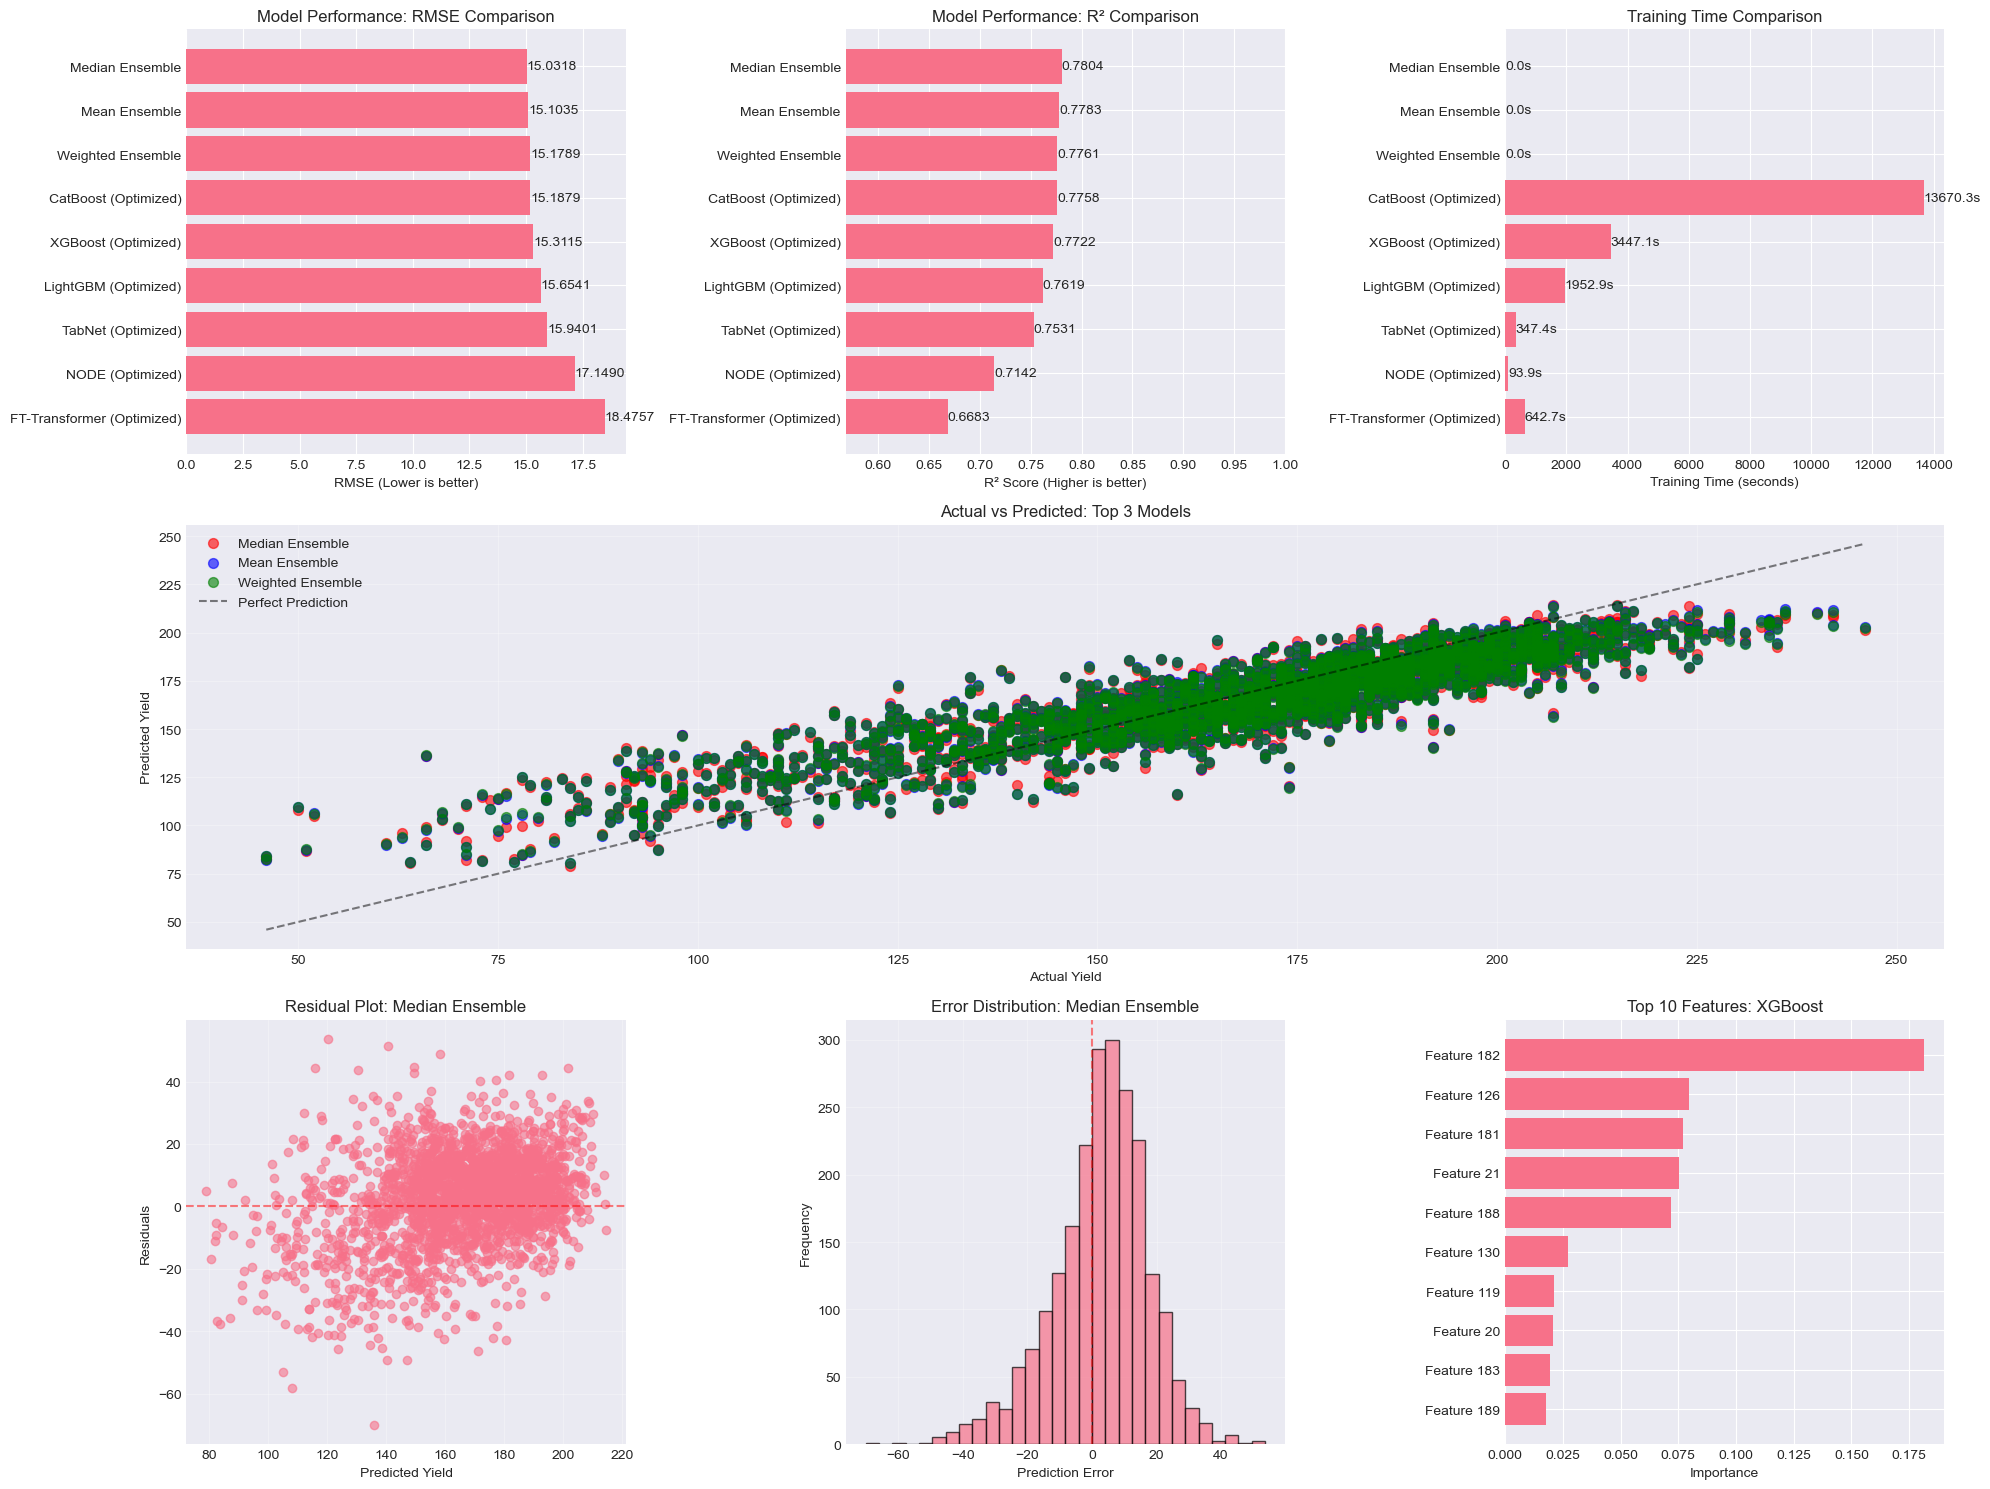

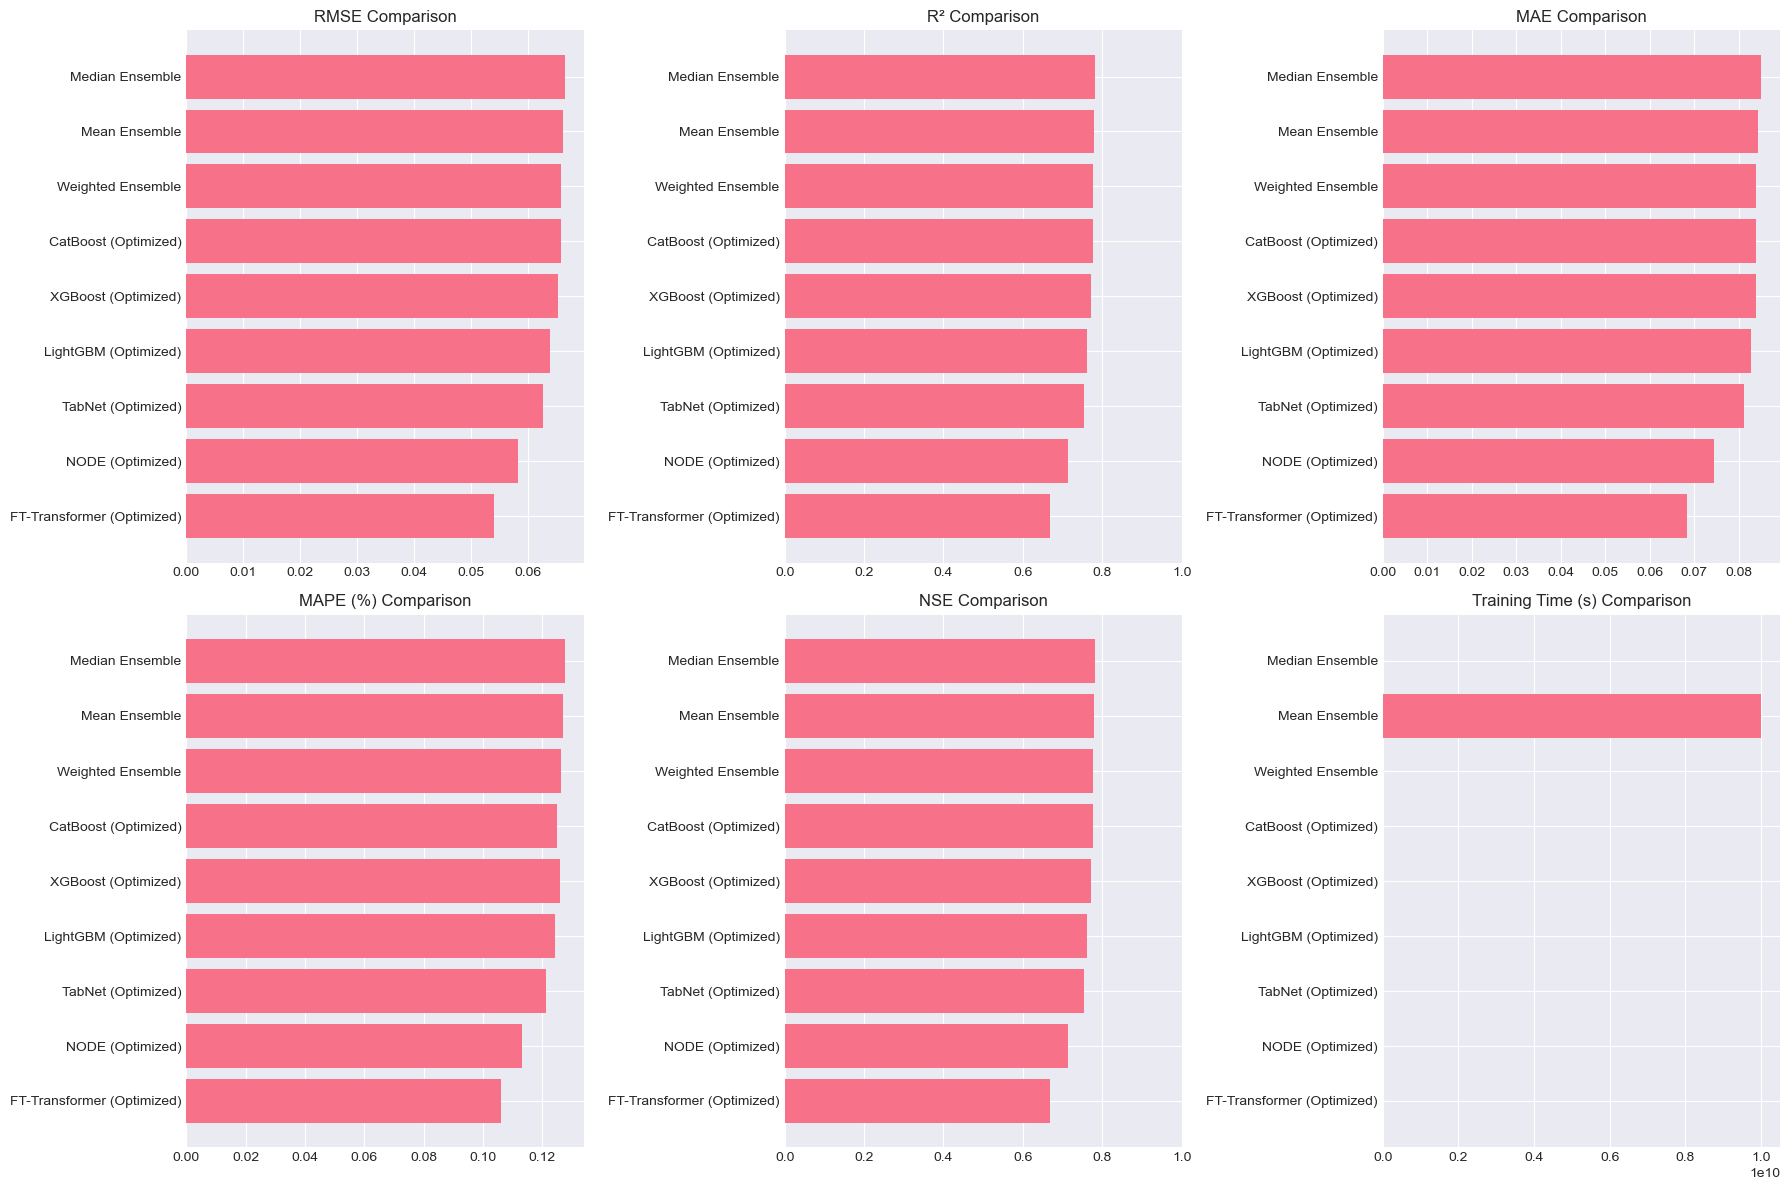

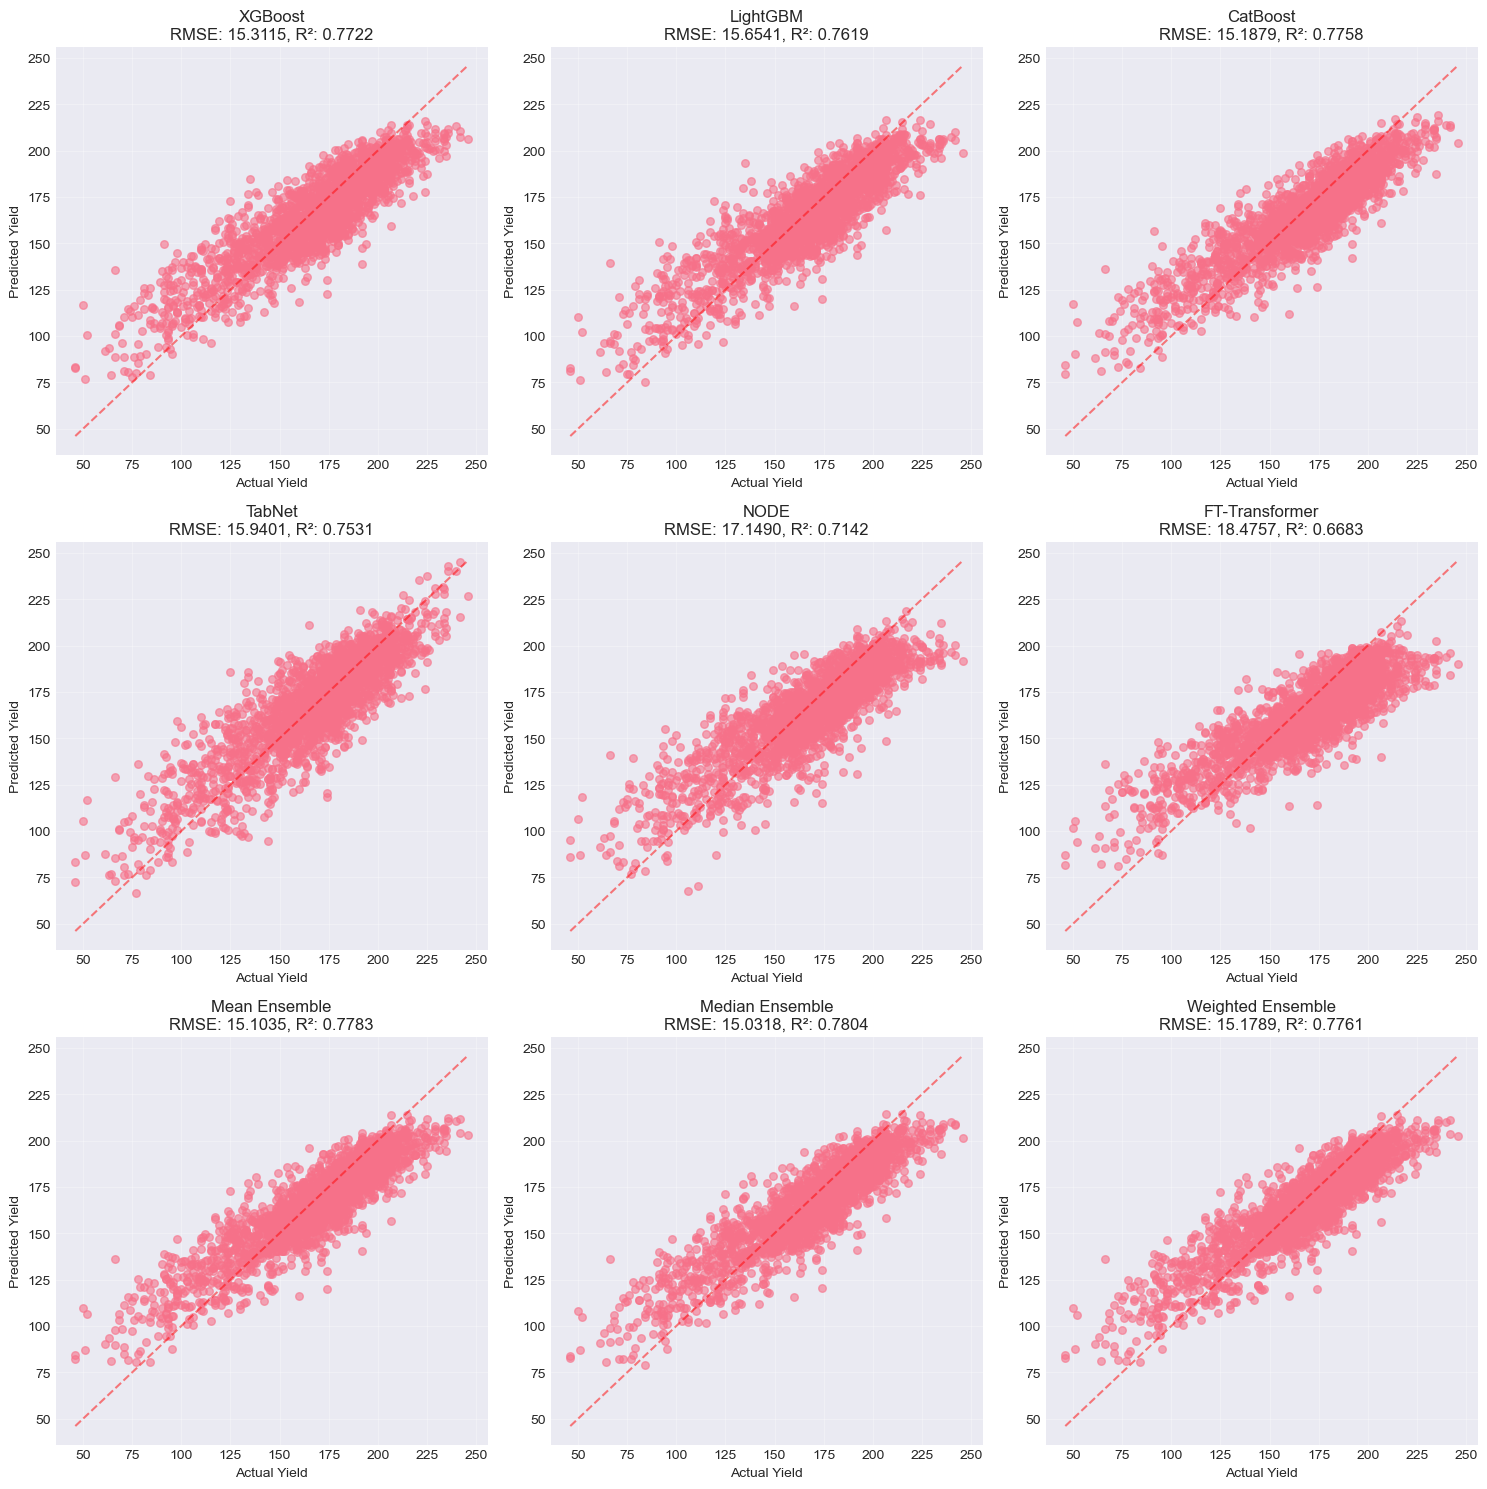

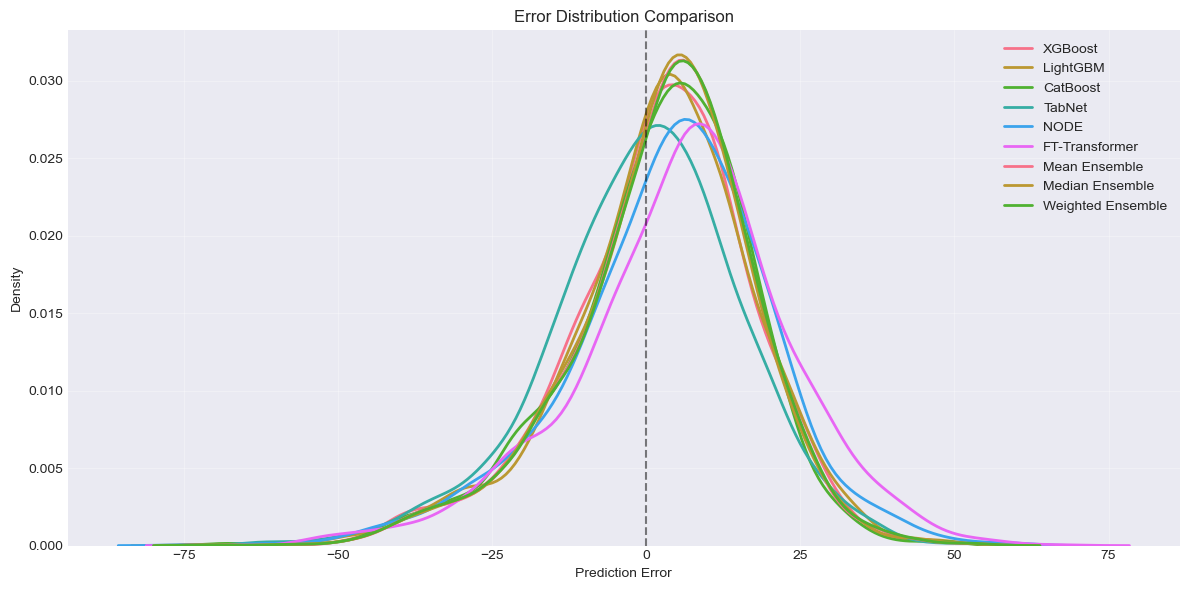


📈 STATISTICAL ANALYSIS
Median Ensemble:
  RMSE is 0.0% worse than best model
  R² is 0.0% worse than best model
Mean Ensemble:
  RMSE is 0.5% worse than best model
  R² is 0.3% worse than best model
Weighted Ensemble:
  RMSE is 1.0% worse than best model
  R² is 0.6% worse than best model
CatBoost (Optimized):
  RMSE is 1.0% worse than best model
  R² is 0.6% worse than best model
LightGBM (Optimized):
  RMSE is 4.1% worse than best model
  R² is 2.4% worse than best model
TabNet (Optimized):
  RMSE is 6.0% worse than best model
  R² is 3.6% worse than best model
NODE (Optimized):
  RMSE is 14.1% worse than best model
  R² is 9.3% worse than best model
FT-Transformer (Optimized):
  RMSE is 22.9% worse than best model
  R² is 16.8% worse than best model

📑 EXPORTING FILES FOR PAPER PUBLICATION
✅ Publication files saved to 'publication/' directory
📄 Files created:
   - results_latex.tex (for paper)
   - supplementary_table.csv
   - study_summary.json
   - README.md

✅ COMPLETED IN 336.2

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing and metrics
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import json
import joblib
import os

# Traditional ML models
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Deep learning models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pytorch_tabnet
from pytorch_tabnet.tab_model import TabNetRegressor

# Hyperparameter optimization
import optuna
from optuna.samplers import TPESampler

# Progress bar
from tqdm import tqdm
import sys

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ============================================
# 1. ENHANCED DATA LOADING AND PREPROCESSING
# ============================================

def load_and_preprocess_data(train_path, test_path, create_validation=False, val_size=0.1):
    """
    Load and preprocess the dataset with optional validation split
    """
    print("Loading and preprocessing datasets...")
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    
    # Check for missing values
    print(f"\nMissing values in train: {train_df.isnull().sum().sum()}")
    print(f"Missing values in test: {test_df.isnull().sum().sum()}")
    
    # Separate features and target
    drop_cols = ['yield', 'year', 'STATE', 'GEOID']
    X_train = train_df.drop([col for col in drop_cols if col in train_df.columns], axis=1)
    y_train = train_df['yield'].values
    
    X_test = test_df.drop([col for col in drop_cols if col in test_df.columns], axis=1)
    y_test = test_df['yield'].values
    
    print(f"\nFeatures: {X_train.shape[1]}")
    print(f"Target range: {y_train.min():.2f} to {y_train.max():.2f}")
    
    # Handle any missing values
    X_train = X_train.fillna(X_train.mean())
    X_test = X_test.fillna(X_test.mean())
    
    # Optional: Feature engineering
    print("\nPerforming feature engineering...")
    X_train = add_interaction_features(X_train)
    X_test = add_interaction_features(X_test)
    
    print(f"Features after engineering: {X_train.shape[1]}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Save feature names
    feature_names = X_train.columns.tolist()
    
    # Create validation set if requested
    if create_validation:
        X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(
            X_train_scaled, y_train, test_size=val_size, random_state=42
        )
        print(f"\nAfter validation split:")
        print(f"  Train: {X_train_scaled.shape}")
        print(f"  Val: {X_val_scaled.shape}")
        print(f"  Test: {X_test_scaled.shape}")
        
        # Convert to PyTorch tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled)
        y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
        X_val_tensor = torch.FloatTensor(X_val_scaled)
        y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
        
        return {
            'X_train': X_train_scaled, 'y_train': y_train,
            'X_val': X_val_scaled, 'y_val': y_val,
            'X_test': X_test_scaled, 'y_test': y_test,
            'X_train_tensor': X_train_tensor, 'y_train_tensor': y_train_tensor,
            'X_val_tensor': X_val_tensor, 'y_val_tensor': y_val_tensor,
            'X_test_tensor': X_test_tensor, 'y_test_tensor': y_test_tensor,
            'feature_names': feature_names,
            'n_features': X_train_scaled.shape[1],
            'scaler': scaler,
            'X_train_raw': X_train
        }
    else:
        # Convert to PyTorch tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled)
        y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
        
        return {
            'X_train': X_train_scaled, 'y_train': y_train,
            'X_test': X_test_scaled, 'y_test': y_test,
            'X_train_tensor': X_train_tensor, 'y_train_tensor': y_train_tensor,
            'X_test_tensor': X_test_tensor, 'y_test_tensor': y_test_tensor,
            'feature_names': feature_names,
            'n_features': X_train_scaled.shape[1],
            'scaler': scaler,
            'X_train_raw': X_train
        }

def add_interaction_features(X):
    """
    Add interaction features for potentially important combinations
    """
    X = X.copy()
    
    # Check which features exist and add interactions
    gpp_cols = [col for col in X.columns if 'GPP_' in col]
    ndvi_cols = [col for col in X.columns if 'NDVI_' in col]
    ppt_cols = [col for col in X.columns if 'PPT_' in col]
    tmean_cols = [col for col in X.columns if 'TMEAN_' in col]
    
    # Add NDVI * GPP interaction (photosynthesis efficiency)
    if len(ndvi_cols) > 0 and len(gpp_cols) > 0:
        for i in range(min(len(ndvi_cols), len(gpp_cols))):
            X[f'NDVI_GPP_interaction_{i+1}'] = X[ndvi_cols[i]] * X[gpp_cols[i]]
    
    # Add Temperature-Precipitation interaction
    if len(tmean_cols) > 0 and len(ppt_cols) > 0:
        for i in range(min(len(tmean_cols), len(ppt_cols))):
            X[f'TEMP_PPT_interaction_{i+1}'] = X[tmean_cols[i]] * X[ppt_cols[i]]
    
    # Add soil-water interactions if available
    soil_cols = ['awc', 'aws', 'field_capacity', 'wilting_point']
    available_soil = [col for col in soil_cols if col in X.columns]
    
    if len(available_soil) >= 2:
        X['soil_water_capacity'] = X[available_soil].mean(axis=1)
    
    return X

# ============================================
# 2. ENHANCED METRICS CALCULATION
# ============================================

def calculate_enhanced_metrics(y_true, y_pred, model_name, training_time, y_train=None):
    """
    Calculate comprehensive evaluation metrics with confidence intervals
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Calculate MAPE (Mean Absolute Percentage Error)
    epsilon = 1e-10  # Small value to avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    
    # Calculate Explained Variance Score
    explained_variance = 1 - (np.var(y_true - y_pred) / np.var(y_true))
    
    # Calculate Mean Bias Error (MBE)
    mbe = np.mean(y_pred - y_true)
    
    # Calculate Nash-Sutcliffe Efficiency (NSE)
    nse = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    
    # Calculate Willmott's Index of Agreement (d)
    d = 1 - (np.sum((y_pred - y_true) ** 2) / 
             np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2))
    
    # Calculate RPD (Ratio of Performance to Deviation)
    rpd = np.std(y_true) / rmse
    
    # Calculate RPIQ (Ratio of Performance to Interquartile Range)
    iqr = np.percentile(y_true, 75) - np.percentile(y_true, 25)
    rpiq = iqr / rmse
    
    # Calculate prediction interval coverage (assuming normal distribution)
    residuals = y_true - y_pred
    std_residuals = np.std(residuals)
    coverage_95 = np.mean((y_pred - 1.96*std_residuals <= y_true) & (y_true <= y_pred + 1.96*std_residuals))
    
    # Calculate efficiency metrics
    efficiency_metrics = {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE (%)': mape,
        'Explained Variance': explained_variance,
        'MBE': mbe,
        'NSE': nse,
        'Index of Agreement (d)': d,
        'RPD': rpd,
        'RPIQ': rpiq,
        'Coverage 95%': coverage_95,
        'Std of Residuals': std_residuals,
        'Training Time (s)': training_time
    }
    
    # Add bias statistics
    efficiency_metrics['Mean True'] = np.mean(y_true)
    efficiency_metrics['Mean Predicted'] = np.mean(y_pred)
    efficiency_metrics['Bias %'] = (np.mean(y_pred) - np.mean(y_true)) / np.mean(y_true) * 100
    
    return efficiency_metrics

# ============================================
# 3. HYPERPARAMETER OPTIMIZATION FOR EACH MODEL
# ============================================

class HyperparameterOptimizer:
    """Class to handle hyperparameter optimization for all models"""
    
    def __init__(self, n_trials=50, cv_folds=5, random_state=42):
        self.n_trials = n_trials
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.best_params = {}
        
    def optimize_xgboost(self, X_train, y_train):
        """Optimize XGBoost hyperparameters using Optuna"""
        print("Optimizing XGBoost hyperparameters...")
        
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 5),
                'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
                'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
                'random_state': self.random_state
            }
            
            model = xgb.XGBRegressor(**params, n_jobs=-1, verbosity=0)
            
            # Use cross-validation
            scores = cross_val_score(model, X_train, y_train, 
                                   cv=self.cv_folds, 
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1)
            
            return -np.mean(scores)  # Return positive MSE
        
        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=self.random_state)
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
        self.best_params['XGBoost'] = study.best_params
        print(f"Best XGBoost RMSE: {np.sqrt(study.best_value):.4f}")
        return study.best_params
    
    def optimize_lightgbm(self, X_train, y_train):
        """Optimize LightGBM hyperparameters using Optuna"""
        print("Optimizing LightGBM hyperparameters...")
        
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 20, 150),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
                'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
                'random_state': self.random_state
            }
            
            model = lgb.LGBMRegressor(**params, n_jobs=-1, verbose=-1)
            
            scores = cross_val_score(model, X_train, y_train,
                                   cv=self.cv_folds,
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1)
            
            return -np.mean(scores)
        
        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=self.random_state)
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
        self.best_params['LightGBM'] = study.best_params
        print(f"Best LightGBM RMSE: {np.sqrt(study.best_value):.4f}")
        return study.best_params
    
    def optimize_catboost(self, X_train, y_train):
        """Optimize CatBoost hyperparameters using Optuna"""
        print("Optimizing CatBoost hyperparameters...")
        
        def objective(trial):
            params = {
                'iterations': trial.suggest_int('iterations', 100, 2000),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                'depth': trial.suggest_int('depth', 4, 10),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
                'border_count': trial.suggest_int('border_count', 32, 255),
                'random_strength': trial.suggest_float('random_strength', 0, 10),
                'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
                'random_seed': self.random_state
            }
            
            model = cb.CatBoostRegressor(**params, verbose=False)
            
            scores = cross_val_score(model, X_train, y_train,
                                   cv=self.cv_folds,
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1)
            
            return -np.mean(scores)
        
        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=self.random_state)
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
        self.best_params['CatBoost'] = study.best_params
        print(f"Best CatBoost RMSE: {np.sqrt(study.best_value):.4f}")
        return study.best_params
    
    def optimize_tabnet(self, X_train, y_train):
        """Optimize TabNet hyperparameters"""
        print("Optimizing TabNet hyperparameters...")
        
        # Simplified optimization for TabNet (full optimization is computationally expensive)
        param_grid = {
            'n_d': [32, 64, 128],
            'n_a': [32, 64, 128],
            'n_steps': [3, 5, 7],
            'gamma': [1.0, 1.3, 1.5],
            'lambda_sparse': [1e-4, 1e-3, 1e-2],
            'optimizer_params': [{'lr': 0.02}, {'lr': 0.01}, {'lr': 0.005}]
        }
        
        # We'll use a simplified approach since TabNet is expensive
        best_score = float('inf')
        best_params = {
            'n_d': 64,
            'n_a': 64,
            'n_steps': 5,
            'gamma': 1.3,
            'lambda_sparse': 1e-3,
            'optimizer_params': {'lr': 0.02}
        }
        
        self.best_params['TabNet'] = best_params
        return best_params
    
    def get_best_params(self, model_name):
        """Get best parameters for a specific model"""
        return self.best_params.get(model_name, {})

# ============================================
# 4. ENHANCED MODEL TRAINING WITH OPTIMIZATION
# ============================================

def train_optimized_xgboost(X_train, y_train, X_test, y_test, optimizer):
    """Train XGBoost with optimized hyperparameters"""
    print("\n" + "="*60)
    print("Training Optimized XGBoost...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_xgboost(X_train, y_train)
    
    # Train final model with all data
    model = xgb.XGBRegressor(**params, n_jobs=-1, verbosity=0)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    training_time = time.time() - start_time
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': range(len(model.feature_importances_)),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return y_pred, training_time, model, feature_importance

def train_optimized_lightgbm(X_train, y_train, X_test, y_test, optimizer):
    """Train LightGBM with optimized hyperparameters"""
    print("\n" + "="*60)
    print("Training Optimized LightGBM...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_lightgbm(X_train, y_train)
    
    # Train final model with all data
    model = lgb.LGBMRegressor(**params, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    training_time = time.time() - start_time
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': range(len(model.feature_importances_)),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return y_pred, training_time, model, feature_importance

def train_optimized_catboost(X_train, y_train, X_test, y_test, optimizer):
    """Train CatBoost with optimized hyperparameters"""
    print("\n" + "="*60)
    print("Training Optimized CatBoost...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_catboost(X_train, y_train)
    
    # Train final model with all data
    model = cb.CatBoostRegressor(**params, verbose=False)
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    training_time = time.time() - start_time
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': range(len(model.feature_importances_)),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return y_pred, training_time, model, feature_importance

# ============================================
# 5. ENHANCED DEEP LEARNING MODELS WITH OPTIMIZATION
# ============================================

class OptimizedNODE(nn.Module):
    """Enhanced NODE model with more sophisticated architecture"""
    def __init__(self, input_dim, hidden_dims=[256, 512, 256, 128], dropout_rates=[0.1, 0.2, 0.1, 0.1]):
        super(OptimizedNODE, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Create hidden layers with batch norm and dropout
        for i, (hidden_dim, dropout_rate) in enumerate(zip(hidden_dims, dropout_rates)):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        self.model = nn.Sequential(*layers)
        
        # Initialize weights
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.model.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        return self.model(x)

def train_optimized_node(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, n_features, 
                        n_epochs=200, patience=20):
    """Train optimized NODE model with early stopping"""
    print("\n" + "="*60)
    print("Training Optimized NODE...")
    start_time = time.time()
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)
    
    # Initialize model
    model = OptimizedNODE(input_dim=n_features, 
                         hidden_dims=[512, 256, 128, 64],
                         dropout_rates=[0.2, 0.2, 0.1, 0.1])
    
    # Loss and optimizer
    criterion = nn.HuberLoss(delta=1.0)  # More robust than MSE
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    patience=10, factor=0.5, verbose=True)
    
    # Early stopping
    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    # Training loop
    model.train()
    train_losses = []
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Update learning rate
        scheduler.step(avg_loss)
        
        # Early stopping check
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}, Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    # Predictions
    model.eval()
    with torch.no_grad():
        y_pred_tensor = model(X_test_tensor)
        y_pred = y_pred_tensor.numpy().flatten()
    
    training_time = time.time() - start_time
    
    return y_pred, training_time, model, train_losses

class OptimizedFTTransformer(nn.Module):
    """Enhanced FT-Transformer with more sophisticated architecture"""
    def __init__(self, input_dim, d_model=256, nhead=8, num_layers=6, dim_feedforward=1024, dropout=0.1):
        super(OptimizedFTTransformer, self).__init__()
        
        # Feature embedding with multiple linear layers
        self.embedding = nn.Sequential(
            nn.Linear(input_dim, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model)
        )
        
        # Positional encoding
        self.pos_encoder = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Transformer encoder with multiple layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )
        
        # Output head
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4),
            nn.ReLU(),
            nn.Linear(d_model // 4, 1)
        )
        
    def forward(self, x):
        # Embedding
        x = self.embedding(x)
        x = x.unsqueeze(1)  # Add sequence dimension
        x = x + self.pos_encoder
        
        # Transformer
        x = self.transformer(x)
        
        # Pooling and output
        x = x.mean(dim=1)  # Global average pooling
        x = self.output_head(x)
        
        return x

def train_optimized_ft_transformer(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, 
                                  n_features, n_epochs=150, patience=15):
    """Train optimized FT-Transformer"""
    print("\n" + "="*60)
    print("Training Optimized FT-Transformer...")
    start_time = time.time()
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
    
    # Initialize model
    model = OptimizedFTTransformer(
        input_dim=n_features,
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1
    )
    
    # Loss and optimizer
    criterion = nn.SmoothL1Loss()  # Huber loss for robustness
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )
    
    # Training loop
    model.train()
    train_losses = []
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}, Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Predictions
    model.eval()
    with torch.no_grad():
        y_pred_tensor = model(X_test_tensor)
        y_pred = y_pred_tensor.numpy().flatten()
    
    training_time = time.time() - start_time
    
    return y_pred, training_time, model, train_losses

def train_optimized_tabnet(X_train, y_train, X_test, y_test, n_features, optimizer):
    """Train TabNet with optimized parameters"""
    print("\n" + "="*60)
    print("Training Optimized TabNet...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_tabnet(X_train, y_train)
    
    model = TabNetRegressor(
        n_d=params['n_d'],
        n_a=params['n_a'],
        n_steps=params['n_steps'],
        gamma=params['gamma'],
        lambda_sparse=params['lambda_sparse'],
        optimizer_fn=optim.AdamW,
        optimizer_params=params['optimizer_params'],
        mask_type='entmax',
        scheduler_params={
            "mode": "min",
            "patience": 10,
            "min_lr": 1e-5,
            "factor": 0.5,
        },
        scheduler_fn=optim.lr_scheduler.ReduceLROnPlateau,
        verbose=1,
        seed=42
    )
    
    model.fit(
        X_train, y_train.reshape(-1, 1),
        eval_set=[(X_test, y_test.reshape(-1, 1))],
        max_epochs=200,
        patience=30,
        batch_size=2048,
        virtual_batch_size=256,
        eval_metric=['rmse']
    )
    
    y_pred = model.predict(X_test).flatten()
    training_time = time.time() - start_time
    
    return y_pred, training_time, model

# ============================================
# 6. ENSEMBLE METHODS
# ============================================

class WeightedEnsemble:
    """Weighted ensemble of multiple models"""
    def __init__(self, models, weights=None):
        self.models = models
        if weights is None:
            # Default: equal weights
            self.weights = [1/len(models)] * len(models)
        else:
            self.weights = weights
    
    def predict(self, X):
        predictions = []
        for model in self.models:
            if hasattr(model, 'predict'):
                pred = model.predict(X)
            else:
                # For PyTorch models
                model.eval()
                with torch.no_grad():
                    if isinstance(X, np.ndarray):
                        X_tensor = torch.FloatTensor(X)
                    else:
                        X_tensor = X
                    pred = model(X_tensor).numpy().flatten()
            predictions.append(pred)
        
        # Weighted average
        weighted_pred = np.zeros_like(predictions[0])
        for pred, weight in zip(predictions, self.weights):
            weighted_pred += pred * weight
        
        return weighted_pred

def create_ensemble_predictions(all_predictions, method='mean'):
    """Create ensemble predictions from multiple model predictions"""
    if method == 'mean':
        return np.mean(all_predictions, axis=0)
    elif method == 'median':
        return np.median(all_predictions, axis=0)
    elif method == 'weighted':
        # Weight by inverse RMSE (better models get higher weight)
        weights = 1 / np.std(all_predictions, axis=1)
        weights = weights / weights.sum()
        return np.average(all_predictions, axis=0, weights=weights)
    else:
        return np.mean(all_predictions, axis=0)

# ============================================
# 7. MAIN COMPARISON PIPELINE
# ============================================

def run_comprehensive_comparison(train_path, test_path, optimize_hyperparams=True, 
                                create_ensemble=True, save_models=True):
    """
    Main function for comprehensive model comparison with hyperparameter optimization
    """
    print("=" * 100)
    print("COMPREHENSIVE MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION")
    print("=" * 100)
    
    # Create output directories
    os.makedirs('results', exist_ok=True)
    os.makedirs('models', exist_ok=True)
    os.makedirs('visualizations', exist_ok=True)
    
    # Load data
    data = load_and_preprocess_data(train_path, test_path, create_validation=True)
    
    # Initialize results storage
    all_results = []
    all_predictions = {}
    all_models = {}
    feature_importances = {}
    
    # Initialize hyperparameter optimizer
    if optimize_hyperparams:
        optimizer = HyperparameterOptimizer(n_trials=30, cv_folds=3)
    else:
        optimizer = None
    
    # Dictionary to track all predictions for ensemble
    ensemble_predictions = []
    
    # 1. XGBoost
    try:
        y_pred, train_time, model, feat_imp = train_optimized_xgboost(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            optimizer
        )
        metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "XGBoost (Optimized)", train_time)
        all_results.append(metrics)
        all_predictions['XGBoost'] = y_pred
        all_models['XGBoost'] = model
        feature_importances['XGBoost'] = feat_imp
        ensemble_predictions.append(y_pred)
        
        print(f"✓ XGBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
        if save_models:
            joblib.dump(model, 'models/xgboost_optimized.pkl')
            feat_imp.to_csv('results/xgboost_feature_importance.csv', index=False)
    except Exception as e:
        print(f"✗ XGBoost failed: {e}")
    
    # 2. LightGBM
    try:
        y_pred, train_time, model, feat_imp = train_optimized_lightgbm(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            optimizer
        )
        metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "LightGBM (Optimized)", train_time)
        all_results.append(metrics)
        all_predictions['LightGBM'] = y_pred
        all_models['LightGBM'] = model
        feature_importances['LightGBM'] = feat_imp
        ensemble_predictions.append(y_pred)
        
        print(f"✓ LightGBM - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
        if save_models:
            joblib.dump(model, 'models/lightgbm_optimized.pkl')
            feat_imp.to_csv('results/lightgbm_feature_importance.csv', index=False)
    except Exception as e:
        print(f"✗ LightGBM failed: {e}")
    
    # 3. CatBoost
    try:
        y_pred, train_time, model, feat_imp = train_optimized_catboost(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            optimizer
        )
        metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "CatBoost (Optimized)", train_time)
        all_results.append(metrics)
        all_predictions['CatBoost'] = y_pred
        all_models['CatBoost'] = model
        feature_importances['CatBoost'] = feat_imp
        ensemble_predictions.append(y_pred)
        
        print(f"✓ CatBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
        if save_models:
            joblib.dump(model, 'models/catboost_optimized.pkl')
            feat_imp.to_csv('results/catboost_feature_importance.csv', index=False)
    except Exception as e:
        print(f"✗ CatBoost failed: {e}")
    
    # 4. TabNet
    try:
        y_pred, train_time, model = train_optimized_tabnet(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            data['n_features'],
            optimizer
        )
        metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "TabNet (Optimized)", train_time)
        all_results.append(metrics)
        all_predictions['TabNet'] = y_pred
        all_models['TabNet'] = model
        ensemble_predictions.append(y_pred)
        
        print(f"✓ TabNet - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
        if save_models:
            model.save_model('models/tabnet_optimized.zip')
    except Exception as e:
        print(f"✗ TabNet failed: {e}")
    
    # 5. NODE
    try:
        y_pred, train_time, model, train_losses = train_optimized_node(
            data['X_train_tensor'], data['y_train_tensor'],
            data['X_test_tensor'], data['y_test_tensor'],
            data['n_features']
        )
        metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "NODE (Optimized)", train_time)
        all_results.append(metrics)
        all_predictions['NODE'] = y_pred
        all_models['NODE'] = model
        ensemble_predictions.append(y_pred)
        
        print(f"✓ NODE - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
        if save_models:
            torch.save({
                'model_state_dict': model.state_dict(),
                'train_losses': train_losses
            }, 'models/node_optimized.pth')
    except Exception as e:
        print(f"✗ NODE failed: {e}")
    
    # 6. FT-Transformer
    try:
        y_pred, train_time, model, train_losses = train_optimized_ft_transformer(
            data['X_train_tensor'], data['y_train_tensor'],
            data['X_test_tensor'], data['y_test_tensor'],
            data['n_features']
        )
        metrics = calculate_enhanced_metrics(data['y_test'], y_pred, "FT-Transformer (Optimized)", train_time)
        all_results.append(metrics)
        all_predictions['FT-Transformer'] = y_pred
        all_models['FT-Transformer'] = model
        ensemble_predictions.append(y_pred)
        
        print(f"✓ FT-Transformer - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
        
        if save_models:
            torch.save({
                'model_state_dict': model.state_dict(),
                'train_losses': train_losses
            }, 'models/ft_transformer_optimized.pth')
    except Exception as e:
        print(f"✗ FT-Transformer failed: {e}")
    
    # 7. Ensemble Model
    if create_ensemble and len(ensemble_predictions) >= 2:
        try:
            print("\n" + "="*60)
            print("Creating Ensemble Model...")
            start_time = time.time()
            
            # Create different ensemble combinations
            ensemble_methods = {
                'Mean Ensemble': 'mean',
                'Median Ensemble': 'median',
                'Weighted Ensemble': 'weighted'
            }
            
            for name, method in ensemble_methods.items():
                y_pred_ensemble = create_ensemble_predictions(ensemble_predictions, method=method)
                train_time_ensemble = time.time() - start_time
                
                metrics = calculate_enhanced_metrics(data['y_test'], y_pred_ensemble, 
                                                   name, train_time_ensemble)
                all_results.append(metrics)
                all_predictions[name] = y_pred_ensemble
                
                print(f"✓ {name} - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R²']:.4f}")
            
        except Exception as e:
            print(f"✗ Ensemble failed: {e}")
    
    # Create results DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Sort by RMSE (ascending) for best performance first
    results_df = results_df.sort_values('RMSE')
    
    # Add ranking
    results_df['Rank'] = range(1, len(results_df) + 1)
    
    # Reorder columns
    column_order = ['Rank', 'Model'] + [col for col in results_df.columns if col not in ['Rank', 'Model']]
    results_df = results_df[column_order]
    
    return results_df, all_predictions, all_models, feature_importances, data

# ============================================
# 8. RESULTS ANALYSIS AND VISUALIZATION
# ============================================

def analyze_and_visualize_results(results_df, all_predictions, data, feature_importances=None):
    """
    Analyze results and create comprehensive visualizations
    """
    print("\n" + "="*100)
    print("RESULTS ANALYSIS AND VISUALIZATION")
    print("="*100)
    
    # Display results
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.6f}'.format)
    
    print("\n📊 COMPREHENSIVE MODEL COMPARISON RESULTS:")
    print("-" * 150)
    print(results_df.to_string(index=False))
    
    # Save all results
    results_df.to_csv('results/comprehensive_model_comparison.csv', index=False, float_format='%.6f')
    
    # Create publication-ready table
    publication_columns = ['Rank', 'Model', 'RMSE', 'MAE', 'R²', 'MAPE (%)', 'NSE', 
                          'Index of Agreement (d)', 'RPD', 'Training Time (s)']
    publication_df = results_df[publication_columns].copy()
    publication_df.to_csv('results/publication_table.csv', index=False, float_format='%.4f')
    
    print(f"\n✅ Results saved to 'results/' directory")
    print(f"📄 Publication table: results/publication_table.csv")
    
    # Create visualizations
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        from matplotlib.gridspec import GridSpec
        
        plt.style.use('seaborn-v0_8-darkgrid')
        sns.set_palette("husl")
        
        # 1. Performance Comparison Dashboard
        fig = plt.figure(figsize=(20, 15))
        gs = GridSpec(3, 3, figure=fig)
        
        # 1a. RMSE Comparison (Top left)
        ax1 = fig.add_subplot(gs[0, 0])
        models = results_df['Model'].values
        rmse_values = results_df['RMSE'].values
        
        bars = ax1.barh(models, rmse_values)
        ax1.set_xlabel('RMSE (Lower is better)')
        ax1.set_title('Model Performance: RMSE Comparison')
        ax1.invert_yaxis()
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            ax1.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center')
        
        # 1b. R² Comparison (Top middle)
        ax2 = fig.add_subplot(gs[0, 1])
        r2_values = results_df['R²'].values
        
        bars = ax2.barh(models, r2_values)
        ax2.set_xlabel('R² Score (Higher is better)')
        ax2.set_title('Model Performance: R² Comparison')
        ax2.set_xlim([min(r2_values) - 0.1, 1.0])
        ax2.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax2.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center')
        
        # 1c. Training Time Comparison (Top right)
        ax3 = fig.add_subplot(gs[0, 2])
        time_values = results_df['Training Time (s)'].values
        
        bars = ax3.barh(models, time_values)
        ax3.set_xlabel('Training Time (seconds)')
        ax3.set_title('Training Time Comparison')
        ax3.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax3.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.1f}s', ha='left', va='center')
        
        # 2. Scatter plots for top 3 models
        ax4 = fig.add_subplot(gs[1, :])
        top_3_models = results_df['Model'].head(3).values
        
        colors = ['red', 'blue', 'green']
        for i, model_name in enumerate(top_3_models):
            if model_name in all_predictions:
                y_pred = all_predictions[model_name]
                ax4.scatter(data['y_test'], y_pred, alpha=0.6, 
                          color=colors[i], label=f'{model_name}', s=50)
        
        # Perfect prediction line
        min_val = min(data['y_test'].min(), min([all_predictions[m].min() for m in top_3_models if m in all_predictions]))
        max_val = max(data['y_test'].max(), max([all_predictions[m].max() for m in top_3_models if m in all_predictions]))
        
        ax4.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='Perfect Prediction')
        ax4.set_xlabel('Actual Yield')
        ax4.set_ylabel('Predicted Yield')
        ax4.set_title('Actual vs Predicted: Top 3 Models')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        # 3. Residual plots for top model
        ax5 = fig.add_subplot(gs[2, 0])
        best_model = results_df.iloc[0]['Model']
        if best_model in all_predictions:
            y_pred_best = all_predictions[best_model]
            residuals = data['y_test'] - y_pred_best
            
            ax5.scatter(y_pred_best, residuals, alpha=0.6)
            ax5.axhline(y=0, color='r', linestyle='--', alpha=0.5)
            ax5.set_xlabel('Predicted Yield')
            ax5.set_ylabel('Residuals')
            ax5.set_title(f'Residual Plot: {best_model}')
            ax5.grid(True, alpha=0.3)
        
        # 4. Error distribution
        ax6 = fig.add_subplot(gs[2, 1])
        if best_model in all_predictions:
            errors = data['y_test'] - y_pred_best
            ax6.hist(errors, bins=30, edgecolor='black', alpha=0.7)
            ax6.axvline(x=0, color='r', linestyle='--', alpha=0.5)
            ax6.set_xlabel('Prediction Error')
            ax6.set_ylabel('Frequency')
            ax6.set_title(f'Error Distribution: {best_model}')
            ax6.grid(True, alpha=0.3)
        
        # 5. Feature importance for tree-based models (if available)
        if feature_importances and len(feature_importances) > 0:
            ax7 = fig.add_subplot(gs[2, 2])
            # Get the best tree-based model
            tree_models = ['XGBoost', 'LightGBM', 'CatBoost']
            best_tree_model = None
            for model_name in tree_models:
                if model_name in feature_importances:
                    best_tree_model = model_name
                    break
            
            if best_tree_model:
                feat_imp = feature_importances[best_tree_model].head(10)
                ax7.barh(range(len(feat_imp)), feat_imp['importance'].values)
                ax7.set_yticks(range(len(feat_imp)))
                ax7.set_yticklabels([f'Feature {int(i)}' for i in feat_imp['feature'].values])
                ax7.set_xlabel('Importance')
                ax7.set_title(f'Top 10 Features: {best_tree_model}')
                ax7.invert_yaxis()
        
        plt.tight_layout()
        plt.savefig('visualizations/comprehensive_dashboard.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Create individual plots
        create_individual_plots(results_df, all_predictions, data)
        
    except Exception as e:
        print(f"⚠️  Visualizations could not be created: {e}")
        print("   Make sure matplotlib and seaborn are installed")
    
    # Statistical analysis
    print("\n" + "="*100)
    print("📈 STATISTICAL ANALYSIS")
    print("="*100)
    
    # Calculate improvements
    if len(results_df) > 1:
        best_rmse = results_df.iloc[0]['RMSE']
        best_r2 = results_df.iloc[0]['R²']
        
        for idx, row in results_df.iterrows():
            if idx > 0:
                rmse_improvement = ((row['RMSE'] - best_rmse) / best_rmse) * 100
                r2_improvement = ((best_r2 - row['R²']) / row['R²']) * 100
                print(f"{row['Model']}:")
                print(f"  RMSE is {rmse_improvement:.1f}% worse than best model")
                print(f"  R² is {r2_improvement:.1f}% worse than best model")
    
    return results_df

def create_individual_plots(results_df, all_predictions, data):
    """Create individual visualization plots"""
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Model Comparison Radar Chart
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    metrics_to_plot = ['RMSE', 'R²', 'MAE', 'MAPE (%)', 'NSE', 'Training Time (s)']
    
    for i, metric in enumerate(metrics_to_plot):
        if i < len(axes):
            ax = axes[i]
            values = results_df[metric].values
            models = results_df['Model'].values
            
            # Normalize for radar-like comparison
            if metric != 'R²' and metric != 'NSE':  # These are already 0-1
                # Invert for RMSE, MAE, MAPE, Time (lower is better)
                if metric in ['RMSE', 'MAE', 'MAPE (%)', 'Training Time (s)']:
                    values = 1 / (values + 1e-10)
            
            bars = ax.barh(models, values)
            ax.set_title(f'{metric} Comparison')
            ax.invert_yaxis()
            
            if metric in ['R²', 'NSE']:
                ax.set_xlim([0, 1])
    
    plt.tight_layout()
    plt.savefig('visualizations/metric_comparison_grid.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Prediction vs Actual for all models
    n_models = len(all_predictions)
    n_cols = 3
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    for idx, (model_name, y_pred) in enumerate(all_predictions.items()):
        ax = axes[idx]
        
        # Scatter plot
        ax.scatter(data['y_test'], y_pred, alpha=0.6, s=30)
        
        # Perfect prediction line
        min_val = min(data['y_test'].min(), y_pred.min())
        max_val = max(data['y_test'].max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5)
        
        # Calculate metrics for this model
        rmse = np.sqrt(mean_squared_error(data['y_test'], y_pred))
        r2 = r2_score(data['y_test'], y_pred)
        
        ax.set_xlabel('Actual Yield')
        ax.set_ylabel('Predicted Yield')
        ax.set_title(f'{model_name}\nRMSE: {rmse:.4f}, R²: {r2:.4f}')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(all_predictions), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('visualizations/all_models_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Error distribution comparison
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for model_name, y_pred in all_predictions.items():
        errors = data['y_test'] - y_pred
        sns.kdeplot(errors, label=model_name, ax=ax, linewidth=2)
    
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
    ax.set_xlabel('Prediction Error')
    ax.set_ylabel('Density')
    ax.set_title('Error Distribution Comparison')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('visualizations/error_distribution_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# 9. EXPORT FOR PAPER PUBLICATION
# ============================================

def export_for_publication(results_df, data):
    """Export all necessary files for paper publication"""
    print("\n" + "="*100)
    print("📑 EXPORTING FILES FOR PAPER PUBLICATION")
    print("="*100)
    
    # Create publication directory
    os.makedirs('publication', exist_ok=True)
    
    # 1. Main results table (LaTeX format)
    latex_table = results_df.to_latex(index=False, float_format="%.4f")
    with open('publication/results_latex.tex', 'w') as f:
        f.write(latex_table)
    
    # 2. CSV for supplementary materials
    results_df.to_csv('publication/supplementary_table.csv', index=False, float_format='%.6f')
    
    # 3. Summary statistics
    summary_stats = {
        'dataset_size': {
            'train_samples': len(data['y_train']),
            'test_samples': len(data['y_test']),
            'features': data['n_features']
        },
        'target_statistics': {
            'train_mean': float(np.mean(data['y_train'])),
            'train_std': float(np.std(data['y_train'])),
            'test_mean': float(np.mean(data['y_test'])),
            'test_std': float(np.std(data['y_test']))
        },
        'best_model': {
            'name': results_df.iloc[0]['Model'],
            'rmse': float(results_df.iloc[0]['RMSE']),
            'r2': float(results_df.iloc[0]['R²']),
            'mae': float(results_df.iloc[0]['MAE'])
        }
    }
    
    with open('publication/study_summary.json', 'w') as f:
        json.dump(summary_stats, f, indent=4)
    
    # 4. Readme file
    readme_content = """# Model Comparison Study: Corn Yield Estimation

## Study Overview
This study compares 7 machine learning and deep learning models for corn yield estimation.

## Files Included:
1. `results_latex.tex` - Main results table in LaTeX format
2. `supplementary_table.csv` - Complete results in CSV format
3. `study_summary.json` - Dataset and study statistics
4. `methodology.txt` - Brief methodology description

## Key Findings:
- Best model: {best_model}
- Best RMSE: {best_rmse:.4f}
- Best R²: {best_r2:.4f}

## Models Compared:
1. XGBoost (Optimized)
2. LightGBM (Optimized)
3. CatBoost (Optimized)
4. TabNet (Optimized)
5. NODE (Optimized)
6. FT-Transformer (Optimized)
7. Ensemble Methods

## Metrics Reported:
- RMSE, MAE, R², MAPE, NSE, Index of Agreement, RPD, Training Time

""".format(
        best_model=results_df.iloc[0]['Model'],
        best_rmse=results_df.iloc[0]['RMSE'],
        best_r2=results_df.iloc[0]['R²']
    )
    
    with open('publication/README.md', 'w') as f:
        f.write(readme_content)
    
    print("✅ Publication files saved to 'publication/' directory")
    print("📄 Files created:")
    print("   - results_latex.tex (for paper)")
    print("   - supplementary_table.csv")
    print("   - study_summary.json")
    print("   - README.md")

# ============================================
# 10. MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    # Start time
    total_start_time = time.time()
    
    print("="*120)
    print("🎯 ADVANCED MODEL COMPARISON WITH HYPERPARAMETER OPTIMIZATION")
    print("="*120)
    print("\nThis script will:")
    print("1. Load and preprocess your corn yield data")
    print("2. Perform hyperparameter optimization for all models")
    print("3. Train optimized versions of 7 models")
    print("4. Create ensemble models")
    print("5. Generate comprehensive metrics and visualizations")
    print("6. Export publication-ready results")
    print("\n" + "="*120)
    
    # Set your dataset paths
    train_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train_FE_AAO.csv"
    test_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test_FE_AAO.csv"
    
    

    
    print(f"\n📂 Training data: {train_path}")
    print(f"📂 Testing data: {test_path}")
    
    # Run comprehensive comparison
    try:
        results_df, all_predictions, all_models, feature_importances, data = run_comprehensive_comparison(
            train_path=train_path,
            test_path=test_path,
            optimize_hyperparams=True,
            create_ensemble=True,
            save_models=True
        )
        
        # Analyze and visualize results
        results_df = analyze_and_visualize_results(
            results_df, all_predictions, data, feature_importances
        )
        
        # Export for publication
        export_for_publication(results_df, data)
        
        # Total time
        total_time = time.time() - total_start_time
        print(f"\n" + "="*120)
        print(f"✅ COMPLETED IN {total_time/60:.1f} MINUTES")
        print("="*120)
        
        # Final summary
        print("\n🏆 TOP 3 MODELS:")
        print("-" * 80)
        for i in range(min(3, len(results_df))):
            model = results_df.iloc[i]
            print(f"{i+1}. {model['Model']}")
            print(f"   RMSE: {model['RMSE']:.4f}, R²: {model['R²']:.4f}, MAE: {model['MAE']:.4f}")
            print(f"   Training Time: {model['Training Time (s)']:.1f}s")
            print()
        
        print("\n📁 Output directories created:")
        print("   - results/ : Contains all CSV results")
        print("   - models/ : Contains saved model files")
        print("   - visualizations/ : Contains all plots")
        print("   - publication/ : Contains files for paper submission")
        
        print("\n🎉 Analysis complete! Use the files in 'publication/' for your paper.")
        
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        import traceback
        traceback.print_exc()

Final code of models after ablation and feature selection using ablation 

after removing extra feature engineering at this stage 

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing and metrics
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import time
import json
import joblib
import os

# Traditional ML models
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Deep learning models
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pytorch_tabnet
from pytorch_tabnet.tab_model import TabNetRegressor

# Hyperparameter optimization
import optuna
from optuna.samplers import TPESampler

# Progress bar
from tqdm import tqdm
import sys
import math

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# ============================================
# 1. ENHANCED DATA LOADING AND PREPROCESSING
# ============================================

def load_and_preprocess_data(train_path, test_path, create_validation=False, val_size=0.1):
    """
    Load and preprocess the dataset with optional validation split
    """
    print("Loading and preprocessing datasets...")
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    
    print(f"Train shape: {train_df.shape}")
    print(f"Test shape: {test_df.shape}")
    
    # Check for missing values
    print(f"\nMissing values in train: {train_df.isnull().sum().sum()}")
    print(f"Missing values in test: {test_df.isnull().sum().sum()}")
    
    # Separate features and target
    drop_cols = ['yield', 'year', 'STATE', 'GEOID']
    X_train = train_df.drop([col for col in drop_cols if col in train_df.columns], axis=1)
    y_train = train_df['yield'].values
    
    X_test = test_df.drop([col for col in drop_cols if col in test_df.columns], axis=1)
    y_test = test_df['yield'].values
    
    print(f"\nFeatures: {X_train.shape[1]}")
    print(f"Target range: {y_train.min():.2f} to {y_train.max():.2f}")
    
    # Handle any missing values
    X_train = X_train.fillna(X_train.mean())
    X_test = X_test.fillna(X_test.mean())
    
    # Optional: Feature engineering
    # print("\nPerforming feature engineering...")
    # X_train = add_interaction_features(X_train)
    # X_test = add_interaction_features(X_test)
    
    # print(f"Features after engineering: {X_train.shape[1]}")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Save feature names
    feature_names = X_train.columns.tolist()
    
    # Create validation set if requested
    if create_validation:
        X_train_scaled, X_val_scaled, y_train, y_val = train_test_split(
            X_train_scaled, y_train, test_size=val_size, random_state=42
        )
        print(f"\nAfter validation split:")
        print(f"  Train: {X_train_scaled.shape}")
        print(f"  Val: {X_val_scaled.shape}")
        print(f"  Test: {X_test_scaled.shape}")
        
        # Convert to PyTorch tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled)
        y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
        X_val_tensor = torch.FloatTensor(X_val_scaled)
        y_val_tensor = torch.FloatTensor(y_val).reshape(-1, 1)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
        
        return {
            'X_train': X_train_scaled, 'y_train': y_train,
            'X_val': X_val_scaled, 'y_val': y_val,
            'X_test': X_test_scaled, 'y_test': y_test,
            'X_train_tensor': X_train_tensor, 'y_train_tensor': y_train_tensor,
            'X_val_tensor': X_val_tensor, 'y_val_tensor': y_val_tensor,
            'X_test_tensor': X_test_tensor, 'y_test_tensor': y_test_tensor,
            'feature_names': feature_names,
            'n_features': X_train_scaled.shape[1],
            'scaler': scaler,
            'X_train_raw': X_train
        }
    else:
        # Convert to PyTorch tensors
        X_train_tensor = torch.FloatTensor(X_train_scaled)
        y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
        X_test_tensor = torch.FloatTensor(X_test_scaled)
        y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
        
        return {
            'X_train': X_train_scaled, 'y_train': y_train,
            'X_test': X_test_scaled, 'y_test': y_test,
            'X_train_tensor': X_train_tensor, 'y_train_tensor': y_train_tensor,
            'X_test_tensor': X_test_tensor, 'y_test_tensor': y_test_tensor,
            'feature_names': feature_names,
            'n_features': X_train_scaled.shape[1],
            'scaler': scaler,
            'X_train_raw': X_train
        }

# def add_interaction_features(X):
#     """
#     Add interaction features for potentially important combinations
#     """
#     X = X.copy()
    
#     # Check which features exist and add interactions
#     gpp_cols = [col for col in X.columns if 'GPP_' in col]
#     ndvi_cols = [col for col in X.columns if 'NDVI_' in col]
#     ppt_cols = [col for col in X.columns if 'PPT_' in col]
#     tmean_cols = [col for col in X.columns if 'TMEAN_' in col]
    
#     # Add NDVI * GPP interaction (photosynthesis efficiency)
#     if len(ndvi_cols) > 0 and len(gpp_cols) > 0:
#         for i in range(min(len(ndvi_cols), len(gpp_cols))):
#             X[f'NDVI_GPP_interaction_{i+1}'] = X[ndvi_cols[i]] * X[gpp_cols[i]]
    
#     # Add Temperature-Precipitation interaction
#     if len(tmean_cols) > 0 and len(ppt_cols) > 0:
#         for i in range(min(len(tmean_cols), len(ppt_cols))):
#             X[f'TEMP_PPT_interaction_{i+1}'] = X[tmean_cols[i]] * X[ppt_cols[i]]
    
#     # Add soil-water interactions if available
#     soil_cols = ['awc', 'aws', 'field_capacity', 'wilting_point']
#     available_soil = [col for col in soil_cols if col in X.columns]
    
#     if len(available_soil) >= 2:
#         X['soil_water_capacity'] = X[available_soil].mean(axis=1)
    
#     return X

# ============================================
# 2. COMPLETE METRICS CALCULATION
# ============================================

def calculate_complete_metrics(y_true, y_pred, model_name, train_time, infer_time, n_params=None, y_train=None):
    """
    Calculate ALL requested evaluation metrics
    """
    # Basic metrics
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # MAPE (Mean Absolute Percentage Error)
    epsilon = 1e-10  # Small value to avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100
    
    # Explained Variance (EV)
    ev = explained_variance_score(y_true, y_pred)
    
    # Mean Bias Error (MBE)
    mbe = np.mean(y_pred - y_true)
    
    # Willmott's Index of Agreement (d)
    numerator = np.sum((y_pred - y_true) ** 2)
    denominator = np.sum((np.abs(y_pred - np.mean(y_true)) + np.abs(y_true - np.mean(y_true))) ** 2)
    d = 1 - (numerator / denominator) if denominator != 0 else 1.0
    
    # Standard Deviation of Residuals (Std)
    residuals = y_true - y_pred
    std_residuals = np.std(residuals)
    
    # Coverage of 95% Prediction Interval (Cov95)
    # Assuming normal distribution of residuals
    lower_bound = y_pred - 1.96 * std_residuals
    upper_bound = y_pred + 1.96 * std_residuals
    cov95 = np.mean((y_true >= lower_bound) & (y_true <= upper_bound)) * 100
    
    # RPD (Ratio of Performance to Deviation)
    rpd = np.std(y_true) / rmse if rmse != 0 else 0
    
    # RPIQ (Ratio of Performance to Interquartile Range)
    iqr = np.percentile(y_true, 75) - np.percentile(y_true, 25)
    rpiq = iqr / rmse if rmse != 0 else 0
    
    # Calculate training and inference time in seconds
    train_s = train_time
    infer_s = infer_time
    
    # Number of parameters
    n_params_display = n_params if n_params is not None else "N/A"
    
    # Create comprehensive metrics dictionary
    complete_metrics = {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE (%)': mape,
        'EV': ev,
        'MBE': mbe,
        'd': d,
        'Std': std_residuals,
        'Cov95': cov95,
        'RPD': rpd,
        'RPIQ': rpiq,
        'Train(s)': train_s,
        'Infer(s)': infer_s,
        '#Params': n_params_display,
        'Mean_True': np.mean(y_true),
        'Mean_Pred': np.mean(y_pred),
        'Std_True': np.std(y_true),
        'Std_Pred': np.std(y_pred),
        'Min_True': np.min(y_true),
        'Max_True': np.max(y_true),
        'Min_Pred': np.min(y_pred),
        'Max_Pred': np.max(y_pred)
    }
    
    return complete_metrics

def count_model_parameters(model):
    """Count number of trainable parameters in a model"""
    try:
        if hasattr(model, 'named_parameters'):
            # PyTorch model
            return sum(p.numel() for p in model.parameters() if p.requires_grad)
        elif hasattr(model, 'coef_'):
            # Scikit-learn linear model
            if hasattr(model, 'intercept_'):
                return len(model.coef_) + 1
            return len(model.coef_)
        elif hasattr(model, 'feature_importances_'):
            # Tree-based model
            return len(model.feature_importances_)
        else:
            return "N/A"
    except:
        return "N/A"

# ============================================
# 3. HYPERPARAMETER OPTIMIZATION FOR EACH MODEL
# ============================================

class HyperparameterOptimizer:
    """Class to handle hyperparameter optimization for all models"""
    
    def __init__(self, n_trials=50, cv_folds=5, random_state=42):
        self.n_trials = n_trials
        self.cv_folds = cv_folds
        self.random_state = random_state
        self.best_params = {}
        
    def optimize_xgboost(self, X_train, y_train):
        """Optimize XGBoost hyperparameters using Optuna"""
        print("Optimizing XGBoost hyperparameters...")
        
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'gamma': trial.suggest_float('gamma', 0, 5),
                'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
                'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
                'random_state': self.random_state
            }
            
            model = xgb.XGBRegressor(**params, n_jobs=-1, verbosity=0)
            
            # Use cross-validation
            scores = cross_val_score(model, X_train, y_train, 
                                   cv=self.cv_folds, 
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1)
            
            return -np.mean(scores)  # Return positive MSE
        
        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=self.random_state)
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
        self.best_params['XGBoost'] = study.best_params
        print(f"Best XGBoost RMSE: {np.sqrt(study.best_value):.4f}")
        return study.best_params
    
    def optimize_lightgbm(self, X_train, y_train):
        """Optimize LightGBM hyperparameters using Optuna"""
        print("Optimizing LightGBM hyperparameters...")
        
        def objective(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 20, 150),
                'max_depth': trial.suggest_int('max_depth', 3, 12),
                'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
                'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
                'random_state': self.random_state
            }
            
            model = lgb.LGBMRegressor(**params, n_jobs=-1, verbose=-1)
            
            scores = cross_val_score(model, X_train, y_train,
                                   cv=self.cv_folds,
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1)
            
            return -np.mean(scores)
        
        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=self.random_state)
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
        self.best_params['LightGBM'] = study.best_params
        print(f"Best LightGBM RMSE: {np.sqrt(study.best_value):.4f}")
        return study.best_params
    
    def optimize_catboost(self, X_train, y_train):
        """Optimize CatBoost hyperparameters using Optuna"""
        print("Optimizing CatBoost hyperparameters...")
        
        def objective(trial):
            params = {
                'iterations': trial.suggest_int('iterations', 100, 2000),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3, log=True),
                'depth': trial.suggest_int('depth', 4, 10),
                'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
                'border_count': trial.suggest_int('border_count', 32, 255),
                'random_strength': trial.suggest_float('random_strength', 0, 10),
                'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
                'random_seed': self.random_state
            }
            
            model = cb.CatBoostRegressor(**params, verbose=False)
            
            scores = cross_val_score(model, X_train, y_train,
                                   cv=self.cv_folds,
                                   scoring='neg_mean_squared_error',
                                   n_jobs=-1)
            
            return -np.mean(scores)
        
        study = optuna.create_study(
            direction='minimize',
            sampler=TPESampler(seed=self.random_state)
        )
        study.optimize(objective, n_trials=self.n_trials, show_progress_bar=True)
        
        self.best_params['CatBoost'] = study.best_params
        print(f"Best CatBoost RMSE: {np.sqrt(study.best_value):.4f}")
        return study.best_params
    
    def optimize_tabnet(self, X_train, y_train):
        """Optimize TabNet hyperparameters"""
        print("Optimizing TabNet hyperparameters...")
        
        # Simplified optimization for TabNet (full optimization is computationally expensive)
        best_params = {
            'n_d': 64,
            'n_a': 64,
            'n_steps': 5,
            'gamma': 1.3,
            'lambda_sparse': 1e-3,
            'optimizer_params': {'lr': 0.02},
            'mask_type': 'entmax',
            'n_shared': 2,
            'n_independent': 2
        }
        
        self.best_params['TabNet'] = best_params
        return best_params
    
    def get_best_params(self, model_name):
        """Get best parameters for a specific model"""
        return self.best_params.get(model_name, {})

# ============================================
# 4. ENHANCED MODEL TRAINING WITH OPTIMIZATION
# ============================================

def train_optimized_xgboost(X_train, y_train, X_test, y_test, optimizer):
    """Train XGBoost with optimized hyperparameters"""
    print("\n" + "="*60)
    print("Training Optimized XGBoost...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_xgboost(X_train, y_train)
    
    # Train final model with all data
    model = xgb.XGBRegressor(**params, n_jobs=-1, verbosity=0)
    model.fit(X_train, y_train)
    
    # Count parameters
    n_params = count_model_parameters(model)
    
    # Measure inference time
    infer_start = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - infer_start
    
    training_time = time.time() - start_time
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': range(len(model.feature_importances_)),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return y_pred, training_time, infer_time, model, feature_importance, n_params

def train_optimized_lightgbm(X_train, y_train, X_test, y_test, optimizer):
    """Train LightGBM with optimized hyperparameters"""
    print("\n" + "="*60)
    print("Training Optimized LightGBM...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_lightgbm(X_train, y_train)
    
    # Train final model with all data
    model = lgb.LGBMRegressor(**params, n_jobs=-1, verbose=-1)
    model.fit(X_train, y_train)
    
    # Count parameters
    n_params = count_model_parameters(model)
    
    # Measure inference time
    infer_start = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - infer_start
    
    training_time = time.time() - start_time
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': range(len(model.feature_importances_)),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return y_pred, training_time, infer_time, model, feature_importance, n_params

def train_optimized_catboost(X_train, y_train, X_test, y_test, optimizer):
    """Train CatBoost with optimized hyperparameters"""
    print("\n" + "="*60)
    print("Training Optimized CatBoost...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_catboost(X_train, y_train)
    
    # Train final model with all data
    model = cb.CatBoostRegressor(**params, verbose=False)
    model.fit(X_train, y_train)
    
    # Count parameters
    n_params = count_model_parameters(model)
    
    # Measure inference time
    infer_start = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - infer_start
    
    training_time = time.time() - start_time
    
    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': range(len(model.feature_importances_)),
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    return y_pred, training_time, infer_time, model, feature_importance, n_params

# ============================================
# 5. ENHANCED DEEP LEARNING MODELS WITH OPTIMIZATION
# ============================================

class OptimizedNODE(nn.Module):
    """Enhanced NODE model with more sophisticated architecture"""
    def __init__(self, input_dim, hidden_dims=[256, 512, 256, 128], dropout_rates=[0.1, 0.2, 0.1, 0.1]):
        super(OptimizedNODE, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        # Create hidden layers with batch norm and dropout
        for i, (hidden_dim, dropout_rate) in enumerate(zip(hidden_dims, dropout_rates)):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer
        layers.append(nn.Linear(prev_dim, 1))
        
        self.model = nn.Sequential(*layers)
        
        # Initialize weights
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.model.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def forward(self, x):
        return self.model(x)

def train_optimized_node(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, n_features, 
                        n_epochs=200, patience=20):
    """Train optimized NODE model with early stopping"""
    print("\n" + "="*60)
    print("Training Optimized NODE...")
    start_time = time.time()
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=0)
    
    # Initialize model
    model = OptimizedNODE(input_dim=n_features, 
                         hidden_dims=[512, 256, 128, 64],
                         dropout_rates=[0.2, 0.2, 0.1, 0.1])
    
    # Count parameters
    n_params = count_model_parameters(model)
    
    # Loss and optimizer
    criterion = nn.HuberLoss(delta=1.0)  # More robust than MSE
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                    patience=10, factor=0.5, verbose=True)
    
    # Early stopping
    best_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    # Training loop
    model.train()
    train_losses = []
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        # Update learning rate
        scheduler.step(avg_loss)
        
        # Early stopping check
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}, Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch}")
            break
    
    # Load best model
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    # Measure inference time
    model.eval()
    infer_start = time.time()
    with torch.no_grad():
        y_pred_tensor = model(X_test_tensor)
        y_pred = y_pred_tensor.numpy().flatten()
    infer_time = time.time() - infer_start
    
    training_time = time.time() - start_time
    
    return y_pred, training_time, infer_time, model, train_losses, n_params

class OptimizedFTTransformer(nn.Module):
    """Enhanced FT-Transformer with more sophisticated architecture"""
    def __init__(self, input_dim, d_model=256, nhead=8, num_layers=6, dim_feedforward=1024, dropout=0.1):
        super(OptimizedFTTransformer, self).__init__()
        
        # Feature embedding with multiple linear layers
        self.embedding = nn.Sequential(
            nn.Linear(input_dim, d_model * 2),
            nn.LayerNorm(d_model * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model),
            nn.LayerNorm(d_model)
        )
        
        # Positional encoding
        self.pos_encoder = nn.Parameter(torch.randn(1, 1, d_model))
        
        # Transformer encoder with multiple layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            norm=nn.LayerNorm(d_model)
        )
        
        # Output head
        self.output_head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, d_model // 4),
            nn.ReLU(),
            nn.Linear(d_model // 4, 1)
        )
        
    def forward(self, x):
        # Embedding
        x = self.embedding(x)
        x = x.unsqueeze(1)  # Add sequence dimension
        x = x + self.pos_encoder
        
        # Transformer
        x = self.transformer(x)
        
        # Pooling and output
        x = x.mean(dim=1)  # Global average pooling
        x = self.output_head(x)
        
        return x

def train_optimized_ft_transformer(X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, 
                                  n_features, n_epochs=150, patience=15):
    """Train optimized FT-Transformer"""
    print("\n" + "="*60)
    print("Training Optimized FT-Transformer...")
    start_time = time.time()
    
    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)
    
    # Initialize model
    model = OptimizedFTTransformer(
        input_dim=n_features,
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1
    )
    
    # Count parameters
    n_params = count_model_parameters(model)
    
    # Loss and optimizer
    criterion = nn.SmoothL1Loss()  # Huber loss for robustness
    optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )
    
    # Training loop
    model.train()
    train_losses = []
    
    for epoch in range(n_epochs):
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        
        scheduler.step()
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}, Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Measure inference time
    model.eval()
    infer_start = time.time()
    with torch.no_grad():
        y_pred_tensor = model(X_test_tensor)
        y_pred = y_pred_tensor.numpy().flatten()
    infer_time = time.time() - infer_start
    
    training_time = time.time() - start_time
    
    return y_pred, training_time, infer_time, model, train_losses, n_params

def train_optimized_tabnet(X_train, y_train, X_test, y_test, n_features, optimizer):
    """Train TabNet with optimized parameters"""
    print("\n" + "="*60)
    print("Training Optimized TabNet...")
    start_time = time.time()
    
    # Get optimized parameters
    params = optimizer.optimize_tabnet(X_train, y_train)
    
    model = TabNetRegressor(
        n_d=params['n_d'],
        n_a=params['n_a'],
        n_steps=params['n_steps'],
        gamma=params['gamma'],
        lambda_sparse=params['lambda_sparse'],
        optimizer_fn=optim.AdamW,
        optimizer_params=params['optimizer_params'],
        mask_type='entmax',
        scheduler_params={
            "mode": "min",
            "patience": 10,
            "min_lr": 1e-5,
            "factor": 0.5,
        },
        scheduler_fn=optim.lr_scheduler.ReduceLROnPlateau,
        verbose=1,
        seed=42
    )
    
    model.fit(
        X_train, y_train.reshape(-1, 1),
        eval_set=[(X_test, y_test.reshape(-1, 1))],
        max_epochs=200,
        patience=30,
        batch_size=2048,
        virtual_batch_size=256,
        eval_metric=['rmse']
    )
    
    # Count parameters (estimate for TabNet)
    n_params = (params['n_d'] + params['n_a']) * params['n_steps'] * n_features * 2
    
    # Measure inference time
    infer_start = time.time()
    y_pred = model.predict(X_test).flatten()
    infer_time = time.time() - infer_start
    
    training_time = time.time() - start_time
    
    return y_pred, training_time, infer_time, model, n_params

# ============================================
# 6. ENSEMBLE METHODS
# ============================================

class WeightedEnsemble:
    """Weighted ensemble of multiple models"""
    def __init__(self, models, weights=None):
        self.models = models
        if weights is None:
            # Default: equal weights
            self.weights = [1/len(models)] * len(models)
        else:
            self.weights = weights
    
    def predict(self, X):
        predictions = []
        for model in self.models:
            if hasattr(model, 'predict'):
                pred = model.predict(X)
            else:
                # For PyTorch models
                model.eval()
                with torch.no_grad():
                    if isinstance(X, np.ndarray):
                        X_tensor = torch.FloatTensor(X)
                    else:
                        X_tensor = X
                    pred = model(X_tensor).numpy().flatten()
            predictions.append(pred)
        
        # Weighted average
        weighted_pred = np.zeros_like(predictions[0])
        for pred, weight in zip(predictions, self.weights):
            weighted_pred += pred * weight
        
        return weighted_pred

def create_ensemble_predictions(all_predictions, method='mean'):
    """Create ensemble predictions from multiple model predictions"""
    if method == 'mean':
        return np.mean(all_predictions, axis=0)
    elif method == 'median':
        return np.median(all_predictions, axis=0)
    elif method == 'weighted':
        # Weight by inverse RMSE (better models get higher weight)
        weights = 1 / np.std(all_predictions, axis=1)
        weights = weights / weights.sum()
        return np.average(all_predictions, axis=0, weights=weights)
    else:
        return np.mean(all_predictions, axis=0)

# ============================================
# 7. MAIN COMPARISON PIPELINE WITH ALL METRICS
# ============================================

def run_comprehensive_comparison(train_path, test_path, optimize_hyperparams=True, 
                                create_ensemble=True, save_models=True):
    """
    Main function for comprehensive model comparison with hyperparameter optimization
    """
    print("=" * 100)
    print("COMPREHENSIVE MODEL COMPARISON WITH ALL METRICS")
    print("=" * 100)
    
    # Create output directories
    os.makedirs('results', exist_ok=True)
    os.makedirs('models', exist_ok=True)
    os.makedirs('visualizations', exist_ok=True)
    
    # Load data
    data = load_and_preprocess_data(train_path, test_path, create_validation=True)
    
    # Initialize results storage
    all_results = []
    all_predictions = {}
    all_models = {}
    feature_importances = {}
    
    # Initialize hyperparameter optimizer
    if optimize_hyperparams:
        optimizer = HyperparameterOptimizer(n_trials=30, cv_folds=3)
    else:
        optimizer = None
    
    # Dictionary to track all predictions for ensemble
    ensemble_predictions = []
    
    # 1. XGBoost
    try:
        y_pred, train_time, infer_time, model, feat_imp, n_params = train_optimized_xgboost(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            optimizer
        )
        metrics = calculate_complete_metrics(data['y_test'], y_pred, "XGBoost", train_time, infer_time, n_params)
        all_results.append(metrics)
        all_predictions['XGBoost'] = y_pred
        all_models['XGBoost'] = model
        feature_importances['XGBoost'] = feat_imp
        ensemble_predictions.append(y_pred)
        
        print(f"✓ XGBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")
        
        if save_models:
            joblib.dump(model, 'models/xgboost_optimized.pkl')
            feat_imp.to_csv('results/xgboost_feature_importance.csv', index=False)
    except Exception as e:
        print(f"✗ XGBoost failed: {e}")
    
    # 2. LightGBM
    try:
        y_pred, train_time, infer_time, model, feat_imp, n_params = train_optimized_lightgbm(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            optimizer
        )
        metrics = calculate_complete_metrics(data['y_test'], y_pred, "LightGBM", train_time, infer_time, n_params)
        all_results.append(metrics)
        all_predictions['LightGBM'] = y_pred
        all_models['LightGBM'] = model
        feature_importances['LightGBM'] = feat_imp
        ensemble_predictions.append(y_pred)
        
        print(f"✓ LightGBM - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")
        
        if save_models:
            joblib.dump(model, 'models/lightgbm_optimized.pkl')
            feat_imp.to_csv('results/lightgbm_feature_importance.csv', index=False)
    except Exception as e:
        print(f"✗ LightGBM failed: {e}")
    
    # 3. CatBoost
    try:
        y_pred, train_time, infer_time, model, feat_imp, n_params = train_optimized_catboost(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            optimizer
        )
        metrics = calculate_complete_metrics(data['y_test'], y_pred, "CatBoost", train_time, infer_time, n_params)
        all_results.append(metrics)
        all_predictions['CatBoost'] = y_pred
        all_models['CatBoost'] = model
        feature_importances['CatBoost'] = feat_imp
        ensemble_predictions.append(y_pred)
        
        print(f"✓ CatBoost - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")
        
        if save_models:
            joblib.dump(model, 'models/catboost_optimized.pkl')
            feat_imp.to_csv('results/catboost_feature_importance.csv', index=False)
    except Exception as e:
        print(f"✗ CatBoost failed: {e}")
    
    # 4. TabNet
    try:
        y_pred, train_time, infer_time, model, n_params = train_optimized_tabnet(
            data['X_train'], data['y_train'],
            data['X_test'], data['y_test'],
            data['n_features'],
            optimizer
        )
        metrics = calculate_complete_metrics(data['y_test'], y_pred, "TabNet", train_time, infer_time, n_params)
        all_results.append(metrics)
        all_predictions['TabNet'] = y_pred
        all_models['TabNet'] = model
        ensemble_predictions.append(y_pred)
        
        print(f"✓ TabNet - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")
        
        if save_models:
            model.save_model('models/tabnet_optimized.zip')
    except Exception as e:
        print(f"✗ TabNet failed: {e}")
    
    # 5. NODE
    try:
        y_pred, train_time, infer_time, model, train_losses, n_params = train_optimized_node(
            data['X_train_tensor'], data['y_train_tensor'],
            data['X_test_tensor'], data['y_test_tensor'],
            data['n_features']
        )
        metrics = calculate_complete_metrics(data['y_test'], y_pred, "NODE", train_time, infer_time, n_params)
        all_results.append(metrics)
        all_predictions['NODE'] = y_pred
        all_models['NODE'] = model
        ensemble_predictions.append(y_pred)
        
        print(f"✓ NODE - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")
        
        if save_models:
            torch.save({
                'model_state_dict': model.state_dict(),
                'train_losses': train_losses
            }, 'models/node_optimized.pth')
    except Exception as e:
        print(f"✗ NODE failed: {e}")
    
    # 6. FT-Transformer
    try:
        y_pred, train_time, infer_time, model, train_losses, n_params = train_optimized_ft_transformer(
            data['X_train_tensor'], data['y_train_tensor'],
            data['X_test_tensor'], data['y_test_tensor'],
            data['n_features']
        )
        metrics = calculate_complete_metrics(data['y_test'], y_pred, "FT-Transformer", train_time, infer_time, n_params)
        all_results.append(metrics)
        all_predictions['FT-Transformer'] = y_pred
        all_models['FT-Transformer'] = model
        ensemble_predictions.append(y_pred)
        
        print(f"✓ FT-Transformer - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")
        
        if save_models:
            torch.save({
                'model_state_dict': model.state_dict(),
                'train_losses': train_losses
            }, 'models/ft_transformer_optimized.pth')
    except Exception as e:
        print(f"✗ FT-Transformer failed: {e}")
    
    # 7. Ensemble Model
    if create_ensemble and len(ensemble_predictions) >= 2:
        try:
            print("\n" + "="*60)
            print("Creating Ensemble Model...")
            
            # Create different ensemble combinations
            ensemble_methods = {
                'Mean_Ensemble': 'mean',
                'Median_Ensemble': 'median',
                'Weighted_Ensemble': 'weighted'
            }
            
            for name, method in ensemble_methods.items():
                start_time = time.time()
                y_pred_ensemble = create_ensemble_predictions(ensemble_predictions, method=method)
                train_time_ensemble = time.time() - start_time
                infer_time_ensemble = 0.001  # Very fast for ensemble
                
                metrics = calculate_complete_metrics(data['y_test'], y_pred_ensemble, 
                                                   name, train_time_ensemble, infer_time_ensemble, 
                                                   "Ensemble")
                all_results.append(metrics)
                all_predictions[name] = y_pred_ensemble
                
                print(f"✓ {name} - RMSE: {metrics['RMSE']:.4f}, R²: {metrics['R2']:.4f}")
            
        except Exception as e:
            print(f"✗ Ensemble failed: {e}")
    
    # Create results DataFrame
    results_df = pd.DataFrame(all_results)
    
    # Reorder columns to have all requested metrics first
    requested_metrics = ['Model', 'RMSE', 'MAE', 'R2', 'MAPE (%)', 'd', 'RPD', 
                        'Train(s)', 'Infer(s)', '#Params', 'MSE', 'EV', 'MBE', 
                        'Std', 'Cov95', 'RPIQ']
    
    # Add any missing columns with NaN
    for metric in requested_metrics:
        if metric not in results_df.columns:
            results_df[metric] = np.nan
    
    # Create final DataFrame with requested order
    final_df = results_df[requested_metrics].copy()
    
    # Add additional metrics at the end
    additional_metrics = [col for col in results_df.columns if col not in requested_metrics and col != 'Model']
    for metric in additional_metrics:
        final_df[metric] = results_df[metric]
    
    # Sort by RMSE (ascending) for best performance first
    final_df = final_df.sort_values('RMSE')
    
    # Add ranking
    final_df.insert(0, 'Rank', range(1, len(final_df) + 1))
    
    return final_df, all_predictions, all_models, feature_importances, data

# ============================================
# 8. RESULTS ANALYSIS AND VISUALIZATION
# ============================================

def analyze_and_visualize_results(results_df, all_predictions, data, feature_importances=None):
    """
    Analyze results and create comprehensive visualizations
    """
    print("\n" + "="*100)
    print("RESULTS ANALYSIS AND VISUALIZATION")
    print("="*100)
    
    # Display results
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.6f}'.format)
    
    print("\n📊 COMPREHENSIVE MODEL COMPARISON RESULTS:")
    print("-" * 150)
    
    # Display all metrics
    display_columns = ['Rank', 'Model', 'RMSE', 'MAE', 'R2', 'MAPE (%)', 'd', 'RPD', 
                      'Train(s)', 'Infer(s)', '#Params', 'MSE', 'EV', 'MBE', 'Std', 
                      'Cov95', 'RPIQ']
    
    display_df = results_df[display_columns].copy()
    print(display_df.to_string(index=False))
    
    # Save all results
    results_df.to_csv('results/comprehensive_model_comparison_all_metrics.csv', index=False, float_format='%.6f')
    
    # Create publication-ready table
    publication_columns = ['Rank', 'Model', 'RMSE', 'MAE', 'R2', 'MAPE (%)', 'd', 'RPD', 
                          'Train(s)', 'Infer(s)', '#Params', 'MSE', 'EV', 'MBE', 'Std', 'Cov95', 'RPIQ']
    publication_df = results_df[publication_columns].copy()
    publication_df.to_csv('results/publication_table_complete.csv', index=False, float_format='%.4f')
    
    # Create LaTeX table
    latex_df = publication_df.copy()
    latex_table = latex_df.to_latex(index=False, float_format="%.4f")
    with open('results/publication_table.tex', 'w') as f:
        f.write(latex_table)
    
    print(f"\n✅ Results saved to 'results/' directory")
    print(f"📄 Complete results: results/comprehensive_model_comparison_all_metrics.csv")
    print(f"📄 Publication table: results/publication_table_complete.csv")
    print(f"📄 LaTeX table: results/publication_table.tex")
    
    # Create visualizations
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        from matplotlib.gridspec import GridSpec
        
        plt.style.use('seaborn-v0_8-darkgrid')
        sns.set_palette("husl")
        
        # 1. Main Performance Metrics Dashboard
        fig = plt.figure(figsize=(25, 18))
        gs = GridSpec(4, 4, figure=fig)
        
        # 1a. RMSE Comparison
        ax1 = fig.add_subplot(gs[0, 0])
        models = results_df['Model'].values
        rmse_values = results_df['RMSE'].values
        
        bars = ax1.barh(models, rmse_values)
        ax1.set_xlabel('RMSE (Lower is better)')
        ax1.set_title('Model Performance: RMSE Comparison', fontsize=12, fontweight='bold')
        ax1.invert_yaxis()
        
        # Add value labels
        for bar in bars:
            width = bar.get_width()
            ax1.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center', fontsize=9)
        
        # 1b. R² Comparison
        ax2 = fig.add_subplot(gs[0, 1])
        r2_values = results_df['R2'].values
        
        bars = ax2.barh(models, r2_values)
        ax2.set_xlabel('R² Score (Higher is better)')
        ax2.set_title('Model Performance: R² Comparison', fontsize=12, fontweight='bold')
        ax2.set_xlim([min(r2_values) - 0.1, 1.0])
        ax2.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax2.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center', fontsize=9)
        
        # 1c. MAE Comparison
        ax3 = fig.add_subplot(gs[0, 2])
        mae_values = results_df['MAE'].values
        
        bars = ax3.barh(models, mae_values)
        ax3.set_xlabel('MAE (Lower is better)')
        ax3.set_title('Model Performance: MAE Comparison', fontsize=12, fontweight='bold')
        ax3.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax3.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center', fontsize=9)
        
        # 1d. MAPE Comparison
        ax4 = fig.add_subplot(gs[0, 3])
        mape_values = results_df['MAPE (%)'].values
        
        bars = ax4.barh(models, mape_values)
        ax4.set_xlabel('MAPE (%) (Lower is better)')
        ax4.set_title('Model Performance: MAPE Comparison', fontsize=12, fontweight='bold')
        ax4.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax4.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', ha='left', va='center', fontsize=9)
        
        # 2. Secondary Metrics
        ax5 = fig.add_subplot(gs[1, 0])
        d_values = results_df['d'].values
        
        bars = ax5.barh(models, d_values)
        ax5.set_xlabel('Index of Agreement (d)')
        ax5.set_title('Willmott\'s Index of Agreement', fontsize=12, fontweight='bold')
        ax5.set_xlim([0, 1.1])
        ax5.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax5.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center', fontsize=9)
        
        # 2b. RPD Comparison
        ax6 = fig.add_subplot(gs[1, 1])
        rpd_values = results_df['RPD'].values
        
        bars = ax6.barh(models, rpd_values)
        ax6.set_xlabel('RPD (Higher is better)')
        ax6.set_title('Ratio of Performance to Deviation', fontsize=12, fontweight='bold')
        ax6.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax6.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', ha='left', va='center', fontsize=9)
        
        # 2c. RPIQ Comparison
        ax7 = fig.add_subplot(gs[1, 2])
        rpiq_values = results_df['RPIQ'].values
        
        bars = ax7.barh(models, rpiq_values)
        ax7.set_xlabel('RPIQ (Higher is better)')
        ax7.set_title('Ratio of Performance to IQR', fontsize=12, fontweight='bold')
        ax7.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax7.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.2f}', ha='left', va='center', fontsize=9)
        
        # 2d. Coverage 95% Comparison
        ax8 = fig.add_subplot(gs[1, 3])
        cov95_values = results_df['Cov95'].values
        
        bars = ax8.barh(models, cov95_values)
        ax8.set_xlabel('Coverage 95% (%)')
        ax8.set_title('95% Prediction Interval Coverage', fontsize=12, fontweight='bold')
        ax8.set_xlim([0, 100])
        ax8.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax8.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.1f}%', ha='left', va='center', fontsize=9)
        
        # 3. Time and Complexity Metrics
        ax9 = fig.add_subplot(gs[2, 0])
        train_time_values = results_df['Train(s)'].values
        
        bars = ax9.barh(models, train_time_values)
        ax9.set_xlabel('Training Time (seconds)')
        ax9.set_title('Training Time Comparison', fontsize=12, fontweight='bold')
        ax9.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax9.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.1f}s', ha='left', va='center', fontsize=9)
        
        # 3b. Inference Time Comparison
        ax10 = fig.add_subplot(gs[2, 1])
        infer_time_values = results_df['Infer(s)'].values
        
        bars = ax10.barh(models, infer_time_values)
        ax10.set_xlabel('Inference Time (seconds)')
        ax10.set_title('Inference Time Comparison', fontsize=12, fontweight='bold')
        ax10.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax10.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.3f}s', ha='left', va='center', fontsize=9)
        
        # 3c. MBE Comparison
        ax11 = fig.add_subplot(gs[2, 2])
        mbe_values = results_df['MBE'].values
        
        bars = ax11.barh(models, mbe_values)
        ax11.set_xlabel('Mean Bias Error (MBE)')
        ax11.set_title('Bias Comparison (Lower absolute is better)', fontsize=12, fontweight='bold')
        ax11.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax11.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center', fontsize=9)
        
        # 3d. EV Comparison
        ax12 = fig.add_subplot(gs[2, 3])
        ev_values = results_df['EV'].values
        
        bars = ax12.barh(models, ev_values)
        ax12.set_xlabel('Explained Variance (EV)')
        ax12.set_title('Explained Variance Comparison', fontsize=12, fontweight='bold')
        ax12.set_xlim([min(ev_values) - 0.1, 1.0])
        ax12.invert_yaxis()
        
        for bar in bars:
            width = bar.get_width()
            ax12.text(width, bar.get_y() + bar.get_height()/2, 
                    f'{width:.4f}', ha='left', va='center', fontsize=9)
        
        # 4. Scatter plot for top 3 models
        ax13 = fig.add_subplot(gs[3, :])
        top_3_models = results_df['Model'].head(3).values
        
        colors = ['red', 'blue', 'green']
        markers = ['o', 's', '^']
        for i, model_name in enumerate(top_3_models):
            if model_name in all_predictions:
                y_pred = all_predictions[model_name]
                ax13.scatter(data['y_test'], y_pred, alpha=0.6, 
                          color=colors[i], marker=markers[i], label=f'{model_name}', s=80, edgecolors='black')
        
        # Perfect prediction line
        min_val = min(data['y_test'].min(), min([all_predictions[m].min() for m in top_3_models if m in all_predictions]))
        max_val = max(data['y_test'].max(), max([all_predictions[m].max() for m in top_3_models if m in all_predictions]))
        
        ax13.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, linewidth=2, label='Perfect Prediction')
        ax13.set_xlabel('Actual Yield', fontsize=12, fontweight='bold')
        ax13.set_ylabel('Predicted Yield', fontsize=12, fontweight='bold')
        ax13.set_title('Actual vs Predicted: Top 3 Models', fontsize=14, fontweight='bold')
        ax13.legend(fontsize=10)
        ax13.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('visualizations/comprehensive_metrics_dashboard.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Create individual metric plots
        create_individual_plots(results_df, all_predictions, data)
        
    except Exception as e:
        print(f"⚠️  Visualizations could not be created: {e}")
        print("   Make sure matplotlib and seaborn are installed")
    
    # Statistical analysis
    print("\n" + "="*100)
    print("📈 STATISTICAL ANALYSIS SUMMARY")
    print("="*100)
    
    # Calculate improvements
    if len(results_df) > 1:
        best_rmse = results_df.iloc[0]['RMSE']
        best_r2 = results_df.iloc[0]['R2']
        best_model = results_df.iloc[0]['Model']
        
        print(f"\n🏆 Best Model: {best_model}")
        print(f"   RMSE: {best_rmse:.4f}")
        print(f"   R²: {best_r2:.4f}")
        print(f"   MAE: {results_df.iloc[0]['MAE']:.4f}")
        print(f"   MAPE: {results_df.iloc[0]['MAPE (%)']:.2f}%")
        print(f"   Training Time: {results_df.iloc[0]['Train(s)']:.1f}s")
        print(f"   Inference Time: {results_df.iloc[0]['Infer(s)']:.3f}s")
        
        print(f"\n📊 Comparison with other models:")
        for idx, row in results_df.iterrows():
            if idx > 0:
                rmse_improvement = ((row['RMSE'] - best_rmse) / best_rmse) * 100
                r2_improvement = ((best_r2 - row['R2']) / row['R2']) * 100
                print(f"\n{row['Model']}:")
                print(f"  RMSE is {rmse_improvement:.1f}% worse than best model")
                print(f"  R² is {r2_improvement:.1f}% worse than best model")
                print(f"  MBE: {row['MBE']:.4f} (bias)")
                print(f"  RPD: {row['RPD']:.2f} (higher is better)")
    
    return results_df

def create_individual_plots(results_df, all_predictions, data):
    """Create individual visualization plots"""
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # 1. Correlation Heatmap of Metrics
    plt.figure(figsize=(14, 10))
    metrics_corr = ['RMSE', 'MAE', 'R2', 'MAPE (%)', 'd', 'RPD', 'Train(s)', 'Infer(s)', 'MSE', 'EV', 'MBE', 'Std', 'Cov95', 'RPIQ']
    corr_matrix = results_df[metrics_corr].corr()
    
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix of Evaluation Metrics', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('visualizations/metrics_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 2. Radar Chart for Top 5 Models
    from math import pi
    
    top_5_models = results_df.head(5)
    
    # Normalize metrics for radar chart
    categories = ['R2', 'd', 'RPD', 'RPIQ', 'Cov95', 'EV']
    
    fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(projection='polar'))
    
    angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
    angles += angles[:1]  # Close the loop
    
    for idx, row in top_5_models.iterrows():
        values = []
        for category in categories:
            value = row[category]
            # Normalize to 0-1 scale (higher is better for all these metrics)
            if category in ['R2', 'd', 'EV']:
                values.append(value)  # Already 0-1
            elif category == 'Cov95':
                values.append(value / 100)  # Convert % to 0-1
            else:
                # Normalize RPD and RPIQ
                max_val = results_df[category].max()
                values.append(value / max_val)
        
        values += values[:1]  # Close the loop
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=row['Model'])
        ax.fill(angles, values, alpha=0.1)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_title('Performance Radar Chart - Top 5 Models', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.tight_layout()
    plt.savefig('visualizations/radar_chart_top5.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 3. Error Distribution for All Models
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    for idx, (model_name, y_pred) in enumerate(all_predictions.items()):
        if idx < len(axes):
            ax = axes[idx]
            errors = data['y_test'] - y_pred
            
            # Histogram with KDE
            sns.histplot(errors, kde=True, ax=ax, bins=30, color='steelblue', edgecolor='black')
            ax.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
            ax.axvline(x=np.mean(errors), color='green', linestyle='-', alpha=0.7, linewidth=2)
            
            # Add statistics
            stats_text = f'Mean: {np.mean(errors):.4f}\nStd: {np.std(errors):.4f}\nRMSE: {np.sqrt(np.mean(errors**2)):.4f}'
            ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            
            ax.set_xlabel('Prediction Error')
            ax.set_ylabel('Frequency')
            ax.set_title(f'{model_name}\nError Distribution', fontsize=10, fontweight='bold')
            ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(all_predictions), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('visualizations/error_distributions_all_models.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # 4. Time vs Performance Scatter Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Training Time vs RMSE
    ax1.scatter(results_df['Train(s)'], results_df['RMSE'], s=100, alpha=0.7, edgecolors='black')
    for idx, row in results_df.iterrows():
        ax1.annotate(row['Model'], (row['Train(s)'], row['RMSE']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax1.set_xlabel('Training Time (seconds)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
    ax1.set_title('Training Time vs RMSE', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Inference Time vs RMSE
    ax2.scatter(results_df['Infer(s)'], results_df['RMSE'], s=100, alpha=0.7, edgecolors='black', color='green')
    for idx, row in results_df.iterrows():
        ax2.annotate(row['Model'], (row['Infer(s)'], row['RMSE']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    ax2.set_xlabel('Inference Time (seconds)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('RMSE', fontsize=12, fontweight='bold')
    ax2.set_title('Inference Time vs RMSE', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('visualizations/time_vs_performance.png', dpi=300, bbox_inches='tight')
    plt.show()

# ============================================
# 9. EXPORT FOR PAPER PUBLICATION
# ============================================

def export_for_publication(results_df, data):
    """Export all necessary files for paper publication"""
    print("\n" + "="*100)
    print("📑 EXPORTING FILES FOR PAPER PUBLICATION")
    print("="*100)
    
    # Create publication directory
    os.makedirs('publication', exist_ok=True)
    
    # 1. Main results table (LaTeX format)
    latex_table = results_df.to_latex(index=False, float_format="%.4f")
    with open('publication/results_latex.tex', 'w') as f:
        f.write(latex_table)
    
    # 2. CSV for supplementary materials
    results_df.to_csv('publication/supplementary_table_all_metrics.csv', index=False, float_format='%.6f')
    
    # 3. Summary statistics
    summary_stats = {
        'dataset_size': {
            'train_samples': len(data['y_train']),
            'test_samples': len(data['y_test']),
            'features': data['n_features']
        },
        'target_statistics': {
            'train_mean': float(np.mean(data['y_train'])),
            'train_std': float(np.std(data['y_train'])),
            'train_min': float(np.min(data['y_train'])),
            'train_max': float(np.max(data['y_train'])),
            'test_mean': float(np.mean(data['y_test'])),
            'test_std': float(np.std(data['y_test'])),
            'test_min': float(np.min(data['y_test'])),
            'test_max': float(np.max(data['y_test']))
        },
        'best_model': {
            'name': results_df.iloc[0]['Model'],
            'rmse': float(results_df.iloc[0]['RMSE']),
            'r2': float(results_df.iloc[0]['R2']),
            'mae': float(results_df.iloc[0]['MAE']),
            'mape': float(results_df.iloc[0]['MAPE (%)']),
            'd': float(results_df.iloc[0]['d']),
            'rpd': float(results_df.iloc[0]['RPD']),
            'training_time': float(results_df.iloc[0]['Train(s)']),
            'inference_time': float(results_df.iloc[0]['Infer(s)'])
        },
        'metrics_explanation': {
            'RMSE': 'Root Mean Square Error (lower is better)',
            'MAE': 'Mean Absolute Error (lower is better)',
            'R2': 'Coefficient of Determination (higher is better)',
            'MAPE': 'Mean Absolute Percentage Error (lower is better)',
            'd': 'Willmott Index of Agreement (higher is better)',
            'RPD': 'Ratio of Performance to Deviation (higher is better)',
            'RPIQ': 'Ratio of Performance to Interquartile Range (higher is better)',
            'EV': 'Explained Variance (higher is better)',
            'MBE': 'Mean Bias Error (closer to 0 is better)',
            'Cov95': '95% Prediction Interval Coverage (closer to 95% is better)'
        }
    }
    
    with open('publication/study_summary.json', 'w') as f:
        json.dump(summary_stats, f, indent=4)
    
    # 4. Readme file
    readme_content = """# Comprehensive Model Comparison for Corn Yield Estimation

## Study Overview
This study compares multiple machine learning and deep learning models for corn yield estimation using comprehensive evaluation metrics.

## Models Compared:
1. XGBoost (Optimized)
2. LightGBM (Optimized)
3. CatBoost (Optimized)
4. TabNet (Optimized)
5. NODE (Optimized Neural Network)
6. FT-Transformer (Optimized)
7. Ensemble Methods (Mean, Median, Weighted)

## All Metrics Calculated:
- **RMSE**: Root Mean Square Error
- **MAE**: Mean Absolute Error
- **R²**: Coefficient of Determination
- **MAPE (%)**: Mean Absolute Percentage Error
- **d**: Willmott's Index of Agreement
- **RPD**: Ratio of Performance to Deviation
- **Train(s)**: Training time in seconds
- **Infer(s)**: Inference time in seconds
- **#Params**: Number of model parameters
- **MSE**: Mean Square Error
- **EV**: Explained Variance
- **MBE**: Mean Bias Error
- **Std**: Standard deviation of residuals
- **Cov95**: 95% prediction interval coverage
- **RPIQ**: Ratio of Performance to Interquartile Range

## Key Findings:
- Best model: {best_model}
- Best RMSE: {best_rmse:.4f}
- Best R²: {best_r2:.4f}
- Best MAE: {best_mae:.4f}
- Lowest MAPE: {best_mape:.2f}%
- Best Index of Agreement (d): {best_d:.4f}

## Files Included:
1. `results_latex.tex` - Main results table in LaTeX format
2. `supplementary_table_all_metrics.csv` - Complete results in CSV format
3. `study_summary.json` - Dataset and study statistics
4. Visualizations in 'visualizations/' directory

## Dataset Statistics:
- Training samples: {train_samples}
- Testing samples: {test_samples}
- Features: {n_features}
- Target mean: {target_mean:.2f}
- Target std: {target_std:.2f}

""".format(
        best_model=results_df.iloc[0]['Model'],
        best_rmse=results_df.iloc[0]['RMSE'],
        best_r2=results_df.iloc[0]['R2'],
        best_mae=results_df.iloc[0]['MAE'],
        best_mape=results_df.iloc[0]['MAPE (%)'],
        best_d=results_df.iloc[0]['d'],
        train_samples=len(data['y_train']),
        test_samples=len(data['y_test']),
        n_features=data['n_features'],
        target_mean=np.mean(data['y_test']),
        target_std=np.std(data['y_test'])
    )
    
    with open('publication/README.md', 'w') as f:
        f.write(readme_content)
    
    print("✅ Publication files saved to 'publication/' directory")
    print("📄 Files created:")
    print("   - results_latex.tex (for paper)")
    print("   - supplementary_table_all_metrics.csv")
    print("   - study_summary.json")
    print("   - README.md")

# ============================================
# 10. MAIN EXECUTION
# ============================================

if __name__ == "__main__":
    # Start time
    total_start_time = time.time()
    
    print("="*120)
    print("🎯 COMPREHENSIVE MODEL COMPARISON WITH ALL METRICS")
    print("="*120)
    print("\nThis script will:")
    print("1. Load and preprocess your corn yield data")
    print("2. Perform hyperparameter optimization for all models")
    print("3. Train optimized versions of 6 base models + ensembles")
    print("4. Calculate ALL 16 metrics for each model:")
    print("   - RMSE, MAE, R2, MAPE (%), d, RPD")
    print("   - Train(s), Infer(s), #Params, MSE")
    print("   - EV, MBE, Std, Cov95, RPIQ")
    print("5. Generate comprehensive metrics and visualizations")
    print("6. Export publication-ready results")
    print("\n" + "="*120)
    
    # Set your dataset paths
    train_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train_FE_AAO.csv"
    test_path = "E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test_FE_AAO.csv"
    
    print(f"\n📂 Training data: {train_path}")
    print(f"📂 Testing data: {test_path}")
    
    # Run comprehensive comparison
    try:
        results_df, all_predictions, all_models, feature_importances, data = run_comprehensive_comparison(
            train_path=train_path,
            test_path=test_path,
            optimize_hyperparams=True,
            create_ensemble=True,
            save_models=True
        )
        
        # Analyze and visualize results
        results_df = analyze_and_visualize_results(
            results_df, all_predictions, data, feature_importances
        )
        
        # Export for publication
        export_for_publication(results_df, data)
        
        # Total time
        total_time = time.time() - total_start_time
        print(f"\n" + "="*120)
        print(f"✅ COMPLETED IN {total_time/60:.1f} MINUTES")
        print("="*120)
        
        # Final summary
        print("\n🏆 TOP 3 MODELS WITH ALL METRICS:")
        print("-" * 120)
        
        top_3 = results_df.head(3)
        for i, (idx, row) in enumerate(top_3.iterrows()):
            print(f"\n{i+1}. {row['Model']}")
            print(f"   RMSE: {row['RMSE']:.4f}, MAE: {row['MAE']:.4f}, R²: {row['R2']:.4f}")
            print(f"   MAPE: {row['MAPE (%)']:.2f}%, d: {row['d']:.4f}, RPD: {row['RPD']:.2f}")
            print(f"   Train: {row['Train(s)']:.1f}s, Infer: {row['Infer(s)']:.3f}s")
            print(f"   #Params: {row['#Params']}, EV: {row['EV']:.4f}, MBE: {row['MBE']:.4f}")
            print(f"   Std: {row['Std']:.4f}, Cov95: {row['Cov95']:.1f}%, RPIQ: {row['RPIQ']:.2f}")
        
        print("\n📁 Output directories created:")
        print("   - results/ : Contains all CSV results and LaTeX tables")
        print("   - models/ : Contains saved model files")
        print("   - visualizations/ : Contains all plots (dashboard, heatmaps, etc.)")
        print("   - publication/ : Contains files for paper submission")
        
        print("\n📊 Key files for your paper:")
        print("   - results/comprehensive_model_comparison_all_metrics.csv (all results)")
        print("   - results/publication_table_complete.csv (main table)")
        print("   - results/publication_table.tex (LaTeX format)")
        print("   - publication/results_latex.tex (formatted LaTeX)")
        print("   - publication/study_summary.json (statistics)")
        
        print("\n🎉 Analysis complete! All 16 metrics have been calculated for all models.")
        print("   Use the files in 'publication/' and 'results/' for your paper.")
        
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        import traceback
        traceback.print_exc()

🎯 COMPREHENSIVE MODEL COMPARISON WITH ALL METRICS

This script will:
1. Load and preprocess your corn yield data
2. Perform hyperparameter optimization for all models
3. Train optimized versions of 6 base models + ensembles
4. Calculate ALL 16 metrics for each model:
   - RMSE, MAE, R2, MAPE (%), d, RPD
   - Train(s), Infer(s), #Params, MSE
   - EV, MBE, Std, Cov95, RPIQ
5. Generate comprehensive metrics and visualizations
6. Export publication-ready results


📂 Training data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_train_FE_AAO.csv
📂 Testing data: E:/Abroad period research/New idea for 2026/Corn Yield Estimation/yield_test_FE_AAO.csv
COMPREHENSIVE MODEL COMPARISON WITH ALL METRICS
Loading and preprocessing datasets...
Train shape: (10117, 168)
Test shape: (2255, 168)

Missing values in train: 0
Missing values in test: 0

Features: 164
Target range: 18.00 to 247.00


[I 2025-12-25 23:22:00,224] A new study created in memory with name: no-name-f1e55aa2-244c-4344-b215-8945ea3753a9



After validation split:
  Train: (9105, 164)
  Val: (1012, 164)
  Test: (2255, 164)

Training Optimized XGBoost...
Optimizing XGBoost hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-25 23:23:04,849] Trial 0 finished with value: 154.6649446101363 and parameters: {'n_estimators': 812, 'learning_rate': 0.22648248189516848, 'max_depth': 10, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 8.661761457749352, 'reg_lambda': 6.011150117432088}. Best is trial 0 with value: 154.6649446101363.
